In [1]:
library(tidyverse)
library(vroom)
library(scales)
library(stringi)
library(viridis)
library(numDeriv)

Warning message:
“package ‘tidyverse’ was built under R version 4.2.3”
Warning message:
“package ‘readr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_on

In [24]:
source("/scratch1/schraibe/rare_alleles/sims/rare_variant_model.r")

In [3]:
options(jupyter.plot_scale=1) 

In [4]:
reverse_complement <- function(trinucleotide) {
  complement <- chartr("ACGT", "TGCA", trinucleotide)
  return(stri_reverse(complement))
}

In [5]:
read_pop_size_res = function(result_dir,num_replace,base_size = 14448) {
    real_data = vroom(Sys.glob(paste0(result_dir,"/real_data_*.tsv")),id="filename") %>%
    extract(filename,into="rep",regex="real_data_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    mutate(est = base_size*est)

    Ne_start = c(14448,14068,14068,14464,14464,15208,15208,16256,16256,17618,17618,19347,
        19347,21534,21534,24236,24236,27367,27367,30416,30416,32060,32060,31284,
        29404,26686,23261,18990,16490,16490,12958,12958,9827,9827,7477,7477,5791,
        5791,4670,4670,3841,3841,3372,3372,3287,3359,3570,4095,4713,5661,7540,11375,
      14310,13292,13292,13292,13292,13292,13292,13292)
    T_fit = c(70000,55940,51395,47457,43984,40877,38067,35501,33141,30956,28922,27018,25231,23545,
         21951,20439,19000,17628,16318,15063,13859,12702,11590,10517,9482,8483,7516,6580,
         5672,5520,5156,4817,4500,4203,3922,3656,3404,3165,2936,2718,2509,2308,2116,1930,
         1752,1579,1413,1252,1096,945,798,656,517,383,252,124,50,25,12,0)

    T_fit = (T_fit[1]-T_fit)

    
    R_fit = rep(0,length(Ne_start))

    cur_Ne = Ne_start[1:(length(Ne_start)-(num_replace+1))]

    par = real_data %>% filter(lnL==min(lnL)) %>% pull(est)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])

    lnL = real_data %>% filter(lnL==min(lnL)) %>% pull(lnL) 

    res = list(Ne = Ne_fit, T = T_fit, R = R_fit, Ne_diffusion = Ne_fit/base_size, T_diffusion = T_fit/(2*base_size),lnL = lnL[1])

    return(res)                 

                    
}

In [6]:
read_pop_size_res_hi_res = function(result_dir,num_replace,base_size = 14448) {
    real_data = vroom(Sys.glob(paste0(result_dir,"/real_data_*.tsv")),id="filename") %>%
    extract(filename,into="rep",regex="real_data_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    mutate(est = base_size*est)

    Ne_start = c(14448,14068,14068,14464,14464,15208,15208,16256,16256,17618,17618,19347,
          19347,21534,21534,24236,24236,27367,27367,30416,30416,32060,32060,31284,
          29404,26686,23261,18990,16490,16490,12958,12958,9827,9827,7477,7477,5791,
          5791,4670,4670,3841,3841,3372,3372,3287,3359,3570,4095,4713,5661,7540,11375,
          14310,13292,13292,13292,13292,13292,13292,13292,13292,13292,13292,13292)
    T_fit = c(70000,55940,51395,47457,43984,40877,38067,35501,33141,30956,28922,27018,25231,23545,
         21951,20439,19000,17628,16318,15063,13859,12702,11590,10517,9482,8483,7516,6580,
         5672,5520,5156,4817,4500,4203,3922,3656,3404,3165,2936,2718,2509,2308,2116,1930,
         1752,1579,1413,1252,1096,945,798,656,517,383,252,188,124,87,50,37,25,18,12,0)

    T_fit = (T_fit[1]-T_fit)

    
    R_fit = rep(0,length(Ne_start))

    cur_Ne = Ne_start[1:(length(Ne_start)-(num_replace+1))]

    par = real_data %>% filter(lnL==min(lnL)) %>% pull(est)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])

    lnL = real_data %>% filter(lnL==min(lnL)) %>% pull(lnL) 

    res = list(Ne = Ne_fit, T = T_fit, R = R_fit, Ne_diffusion = Ne_fit/base_size, T_diffusion = T_fit/(2*base_size),lnL = lnL[1])

    return(res)                 

                    
}

In [7]:
read_pop_size_res_flat = function(result_dir,num_bin,start_time,end_time,burnin=1) {
    real_data = vroom(Sys.glob(paste0(result_dir,"/real_data*.tsv")),id="filename") %>%
    extract(filename,into="rep",regex="real_data_([0-9]+)\\.tsv") %>%
    type_convert() 

    T_fit = rev(c(0,exp(seq(log(start_time),log(end_time),len=num_bin)),end_time+burnin))
    
    T_fit = T_fit[1]-T_fit #flip the T
    
    Ne_start = rep(1,length(T_fit))
    
    R_fit = rep(0,length(Ne_start))

    num_replace = num_bin
    

    cur_Ne = Ne_start[1:(length(Ne_start)-(num_replace+1))]

    par = real_data %>% filter(lnL==min(lnL)) %>% pull(est)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])

    lnL = real_data %>% filter(lnL==min(lnL)) %>% pull(lnL) 

    res = list(Ne_diffusion = Ne_fit, T_diffusion = T_fit,R = R_fit, lnL = lnL[1])

    return(res)                 

                    
}

In [8]:
pop_size = function(s,a,r,t) {
    num_epoch = length(a)
    if (length(r) != num_epoch | length(t) != num_epoch) {
        stop('a, r, and t should be the same length')
    }
    
    max_epoch = sapply(s,function(x){max(which(t<=x))})
            
    pop_size = a[max_epoch]*exp(r[max_epoch]*(s-t[max_epoch])) #TODO: This is bad on the boundaries
    
    return(pop_size)
    
    
    
}

In [9]:
format_sci <- function(x) {
  exponent <- floor(log10(abs(x)))
  base <- signif(x / 10^exponent, digits = 3)
  bquote(.(base) * " x " * 10^.(exponent))
}

In [10]:
custom_labeller <- function(variable, value) {
  sapply(value, function(x) format_sci(x))
}

In [11]:
which.median <- function(x) which.min(abs(x - median(x)))

In [12]:
plot_SFS = function(counts,ref,alt,meth,K,AN,Ne,R,T,rates,rates_dist,nc=1,plot_single=TRUE,plot_dist=TRUE,start=0) {
    if (is.na(meth)) {
        counts = counts %>%
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            filter(AC>=start,AC<=K) %>%
            pull(n)
        if (plot_dist) {
            alpha = rates_dist %>% 
                filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
                mutate(alpha = mean_theta^2/sd_theta^2) %>%
                pull(alpha)
            beta = rates_dist %>% 
                filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
                mutate(beta = mean_theta/sd_theta^2) %>%
                pull(beta)
        }
        theta = rates %>% 
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            pull(theta)
    } else {
        counts = counts %>%
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            filter(AC>=start,AC<=K) %>%
            pull(n)
        if (plot_dist) {
            alpha = rates_dist %>% 
                filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
                mutate(alpha = mean_theta^2/sd_theta^2) %>%
                pull(alpha)
            beta = rates_dist %>% 
                filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
                mutate(beta = mean_theta/sd_theta^2) %>%
                pull(beta)
        }
        theta = rates %>% 
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            pull(theta)
    }

    theory_single = p_mc(K,max(T),theta,AN,0,Ne,R,T,nc=nc)
    if (plot_dist) {
        theory_dist = p_gamma_mc(K,max(T),AN,0,Ne,R,T,alpha,beta,nc=nc)
    }

    counts = normalize_vec(counts)
    theory_single = normalize_vec(theory_single[(start+1):length(theory_single)])
    if (plot_dist) {
        theory_dist = normalize_vec(theory_dist[(start+1):length(theory_dist)])
    }  else {
        theory_dist = rep(0,length(theory_single))
    }

    counts_tibble = tibble(
        AC = rep(start:K,3), 
        source = rep(c("Observed","Theory (Single)", "Theory (Gamma)"),each=K-start+1),
        prob=c(counts,theory_single,theory_dist),
        to_plot = rep(c(TRUE,plot_single,plot_dist),each=K-start+1)
    ) %>%
    filter(to_plot)



    if (plot_single & plot_dist) {
        counts_tibble %>% 
            ggplot(aes(AC+1,prob)) +
            geom_point(data= counts_tibble %>% filter(source=="Observed"), aes(color=source),size=2) +
            geom_line(data = counts_tibble %>% filter(source!="Observed"),aes(color=source),size=1.2) +
            scale_x_log10(labels=label_log()) +
            scale_y_log10(labels=label_log()) + 
            theme_classic(base_size = 20) +
            theme(legend.position = c(.7,.9),legend.title=element_blank(),legend.spacing.y = unit(1,"pt")) +
            scale_color_manual(values = c("black","red","blue")) +
            guides(
                color = guide_legend(
                    override.aes = list(
                        linetype = c(NA, 1, 1),
                        shape = c(19, NA, NA)   
                    )
                )
            ) +
            ylab("Fraction of variants")
    } else if (plot_single | plot_dist) {
        counts_tibble %>%  
            ggplot(aes(AC+1,prob)) +
            geom_point(data= counts_tibble %>% filter(source=="Observed"), aes(color=source),size=2) +
            geom_line(data = counts_tibble %>% filter(source!="Observed") %>% mutate(source="Model"),aes(color=source),size=1.2) +
            scale_x_log10(labels=label_log()) +
            scale_y_log10(labels=label_log()) + 
            theme_classic(base_size = 20) +
            theme(legend.position = c(.7,.9),legend.title=element_blank(),legend.spacing.y = unit(1,"pt")) +
            scale_color_manual(breaks=c("Observed", "Model"), values = c("black","red")) +
            guides(
                color = guide_legend(
                    override.aes = list(
                        linetype = c(NA, 1),
                        shape = c(19, NA)   
                    )
                )
            ) + 
            ylab("Fraction of variants")
    } else {
        counts_tibble %>%  
            ggplot(aes(AC+1,prob)) +
            geom_point(data= counts_tibble %>% filter(source=="Observed"), aes(color=source),size=2) +
            scale_x_log10(labels=label_log()) +
            scale_y_log10(labels=label_log()) + 
            theme_classic(base_size = 20) +
            theme(legend.position = c(.7,.9),legend.title=element_blank(),legend.spacing.y = unit(1,"pt")) +
            scale_color_manual(values = c("black")) +
            guides(
                color = guide_legend(
                    override.aes = list(
                        shape = c(19)   
                    )
                )
            ) + 
            ylab("Fraction of variants")
    }
    
}

In [13]:
plot_SFS_error = function(counts,ref,alt,meth,K,AN,Ne,R,T,rates,error,nc=1,start=0) {
    if (is.na(meth)) {
        counts = counts %>%
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            filter(AC>=start,AC<=K) %>%
            pull(n)
        theta = rates %>% 
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            pull(theta)
        theta_error = error %>%
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            pull(theta)
        eps = error %>%
            filter(ref_context==ref,alt_context==alt,is.na(methylation_level)) %>%
            pull(error)
    } else {
        counts = counts %>%
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            filter(AC>=start,AC<=K) %>%
            pull(n)
        theta = rates %>% 
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            pull(theta)
        theta_error = error %>%
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            pull(theta)
        eps = error %>%
            filter(ref_context==ref,alt_context==alt,methylation_level==meth) %>%
            pull(error)
    }

    theory_no_error = p_mc(K,max(T),theta,AN,0,Ne,R,T,nc=nc)
    theory_error = p_error(K,max(T),theta,AN,0,Ne,R,T,eps,nc=nc)

    counts = normalize_vec(counts)
    theory_no_error = normalize_vec(theory_no_error[(start+1):length(theory_no_error)])
    theory_error = normalize_vec(theory_error[(start+1):length(theory_error)])


    counts_tibble = tibble(
        AC = rep(start:K,3), 
        source = rep(c("Observed","Theory (No Error)", "Theory (Error)"),each=K-start+1),
        prob=c(counts,theory_no_error,theory_error)
    ) 



    counts_tibble %>% 
        ggplot(aes(AC+1,prob)) +
        geom_point(data= counts_tibble %>% filter(source=="Observed"), aes(color=source),size=2) +
        geom_line(data = counts_tibble %>% filter(source!="Observed"),aes(color=source),size=1.2) +
        scale_x_log10(labels=label_log()) +
        scale_y_log10(labels=label_log()) + 
        theme_classic(base_size = 20) +
        theme(legend.position = c(.7,.9),legend.title=element_blank(),legend.spacing.y = unit(1,"pt")) +
        scale_color_manual(values = c("black","red","blue")) +
        guides(
            color = guide_legend(
                override.aes = list(
                    linetype = c(NA, 1, 1),
                    shape = c(19, NA, NA)   
                )
            )
        ) +
        ylab("Fraction of variants")
    
}

In [14]:
rescale_pop_size = function(SFS, pop_size_inference,gnomad_mutation,K=1000,AN=1000000,start=0, nc=20) {
    max_AC = K

    mutation_rates = mutation_rate_MLE(SFS,K=K,AN=AN,Ne=pop_size_inference$Ne_diffusion,R=pop_size_inference$R,T=pop_size_inference$T_diffusion,nc=nc)

    j1 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    j2 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)) %>%
            mutate(ref_context=reverse_complement(ref_context),alt_context=reverse_complement(alt_context)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    mutation_rates_with_gnomad=bind_rows(j1,j2) %>%
    distinct()

    N0_new = mutation_rates_with_gnomad %>%
        drop_na() %>% 
        ungroup() %>% 
        mutate(average_mu = sum(num_sites*mu)/sum(num_sites), average_theta=sum(num_sites*theta)/sum(num_sites)) %>%
        summarise(N0_new = (average_theta/average_mu)/4) %>%
        pull(N0_new) 


    pop_size_inference$Ne = pop_size_inference$Ne_diffusion*N0_new[1]
    pop_size_inference$T = pop_size_inference$T_diffusion*2*N0_new[1]

    pop_size_inference$mut_rates = mutation_rates

    pop_size_inference$mut_rates_gnomad = mutation_rates_with_gnomad

    return(pop_size_inference)
    
}

In [15]:
rescale_mut_rates = function(mutation_rates,gnomad_mutation) {

    j1 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    j2 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)) %>%
            mutate(ref_context=reverse_complement(ref_context),alt_context=reverse_complement(alt_context)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    mutation_rates_with_gnomad=bind_rows(j1,j2) %>%
    distinct()

    mutation_rates_with_gnomad %>%
        drop_na() %>% 
        ungroup() %>% 
        mutate(average_mu = sum(num_sites*mu)/sum(num_sites), average_theta=sum(num_sites*theta)/sum(num_sites)) %>%
        mutate(theta = theta/average_theta*average_mu)

    
}

In [16]:
rescale_mut_rates_dist = function(mutation_rates,gnomad_mutation) {

    j1 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    j2 = gnomad_mutation %>%
    mutate(ref_context = context, alt_context = paste0(substr(context,1,1),alt,substr(context,3,3))) %>%
    inner_join(
        mutation_rates %>% 
            mutate(methylation_level = ifelse(is.na(methylation_level),0,methylation_level)) %>%
            mutate(ref_context=reverse_complement(ref_context),alt_context=reverse_complement(alt_context)),
        by=c("ref_context","alt_context","methylation_level")
    ) 

    mutation_rates_with_gnomad=bind_rows(j1,j2) %>%
    distinct()

    mutation_rates_with_gnomad %>%
        drop_na() %>% 
        ungroup() %>% 
        mutate(average_mu = sum(n*mu)/sum(n), average_theta=sum(n*mean_theta)/sum(n)) %>%
        mutate(mean_theta = mean_theta/average_theta*average_mu, sd_theta = sd_theta/average_theta*average_mu)

    
}

In [17]:
commands = c()
mu = c(1e-9,1e-8,1e-7)
AN = as.integer(exp(seq(log(1001),log(1000000),len=7)))
num_rep = 45
for (j in 1:length(AN)) {
    K = min(1000,as.integer(.005*AN[j]))
    for (k in 1:num_rep) {
        outfile = paste0("mutation_rate_sample_size/mu_",mu,"_n_",AN[j],"_rep_",k,".tsv")
        command = paste0("Rscript test_mutation_rate_inference.r ", mu," ", AN[j], " ", K, " 100000 ", outfile)
        commands = c(commands,command)
    }
}

In [17]:
write_lines(commands,"/scratch1/schraibe/rare_alleles/sims/mutation_rate_sample_size_commands.cmd")

In [38]:
mutation_rate_ss = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/mutation_rate_sample_size/*.tsv"),id="filename")

Rows: 3780 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): ref_context, alt_context, method
dbl (8): p0, theta, mu, LL, num_sites, AN, TS, K
lgl (1): methylation_level

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
custom_labeller <- function(variable, value) {
  sapply(value, function(x) format_sci(x))
}


── Column specification ────────────────────────────────────────────────────────
cols(
  true_mu = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character(),
  method = col_character()
)

`summarise()` has grouped output by 'true_mu', 'AN'. You can override using the
`.groups` argument.
Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Saving 6.67 x 6.67 in image


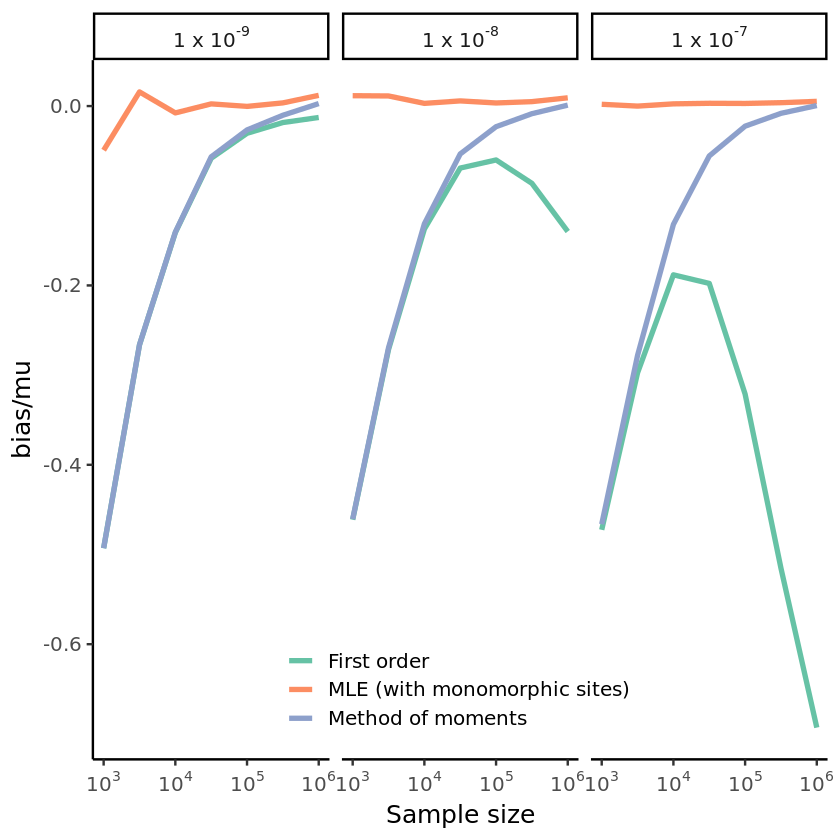

In [41]:
mutation_rate_ss %>%
    extract(filename,into=c("true_mu","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_.*rep_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    group_by(true_mu,AN,method) %>%
    summarise(MSE = mean((mu-true_mu)^2),bias=mean(mu-true_mu),variance=var(mu)) %>%
    ungroup() %>%
    mutate(
        method = case_when(
            method=="FO" ~ "First order",
            method=="MLE_no_target" ~ "MLE (no monomorphic sites)",
            method=="MLE_target" ~ "MLE (with monomorphic sites)",
            method=="MOM" ~ "Method of moments"
        )
    ) %>%
    # mutate(true_mu = as.factor(true_mu)) %>%
    filter(method!="MLE (no monomorphic sites)") %>%
    ggplot(aes(AN,bias/true_mu)) +
    geom_line(aes(color=method),size=1.5) +
    scale_x_log10(labels=label_log()) +
    scale_color_brewer(palette="Set2") + 
    # scale_y_log10(labels=label_log()) +
    xlab("Sample size") +
    ylab("bias/mu") +
    theme_classic(base_size=15) +
    facet_wrap(~true_mu,labeller=custom_labeller) +
    labs(color="") +
    theme(legend.position = c(.5, .1),legend.title=element_blank(),legend.spacing.y = unit(1,"pt"))

ggsave("/scratch1/schraibe/rare_alleles/fig/bias_mu.pdf")


── Column specification ────────────────────────────────────────────────────────
cols(
  true_mu = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character(),
  method = col_character()
)

`summarise()` has grouped output by 'true_mu', 'AN'. You can override using the
`.groups` argument.
Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Saving 6.67 x 6.67 in image


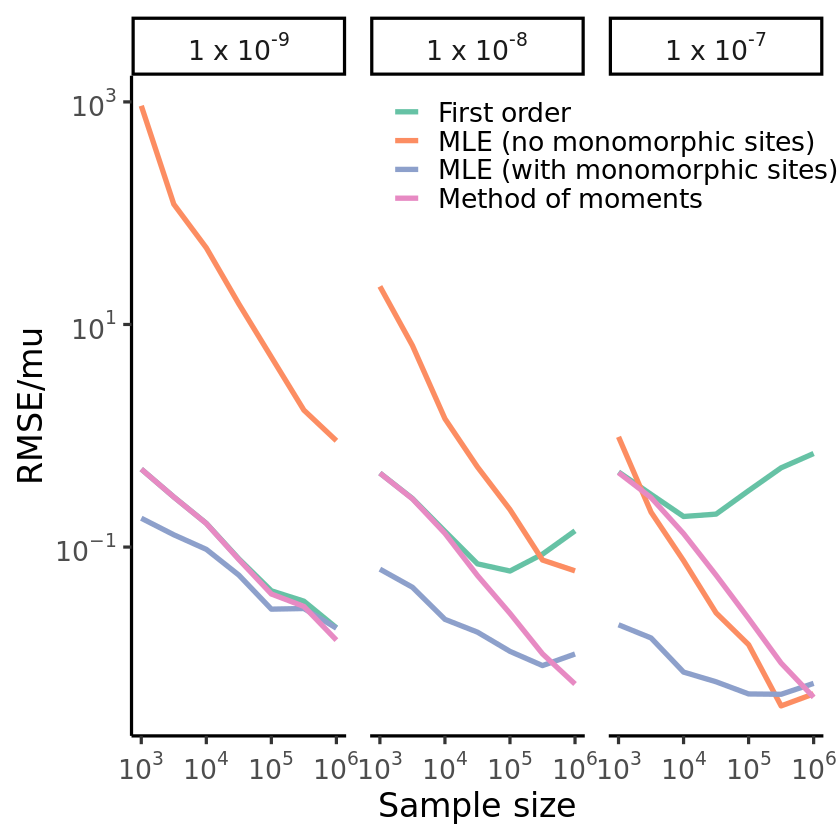

In [48]:
mutation_rate_ss %>%
    extract(filename,into=c("true_mu","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_.*rep_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    group_by(true_mu,AN,method) %>%
    summarise(MSE = mean((mu-true_mu)^2),bias=mean(mu-true_mu),variance=var(mu)) %>%
    ungroup() %>%
    mutate(
        method = case_when(
            method=="FO" ~ "First order",
            method=="MLE_no_target" ~ "MLE (no monomorphic sites)",
            method=="MLE_target" ~ "MLE (with monomorphic sites)",
            method=="MOM" ~ "Method of moments"
        )
    ) %>%
    # mutate(true_mu = as.factor(true_mu)) %>%
    # filter(method!="MLE_no_target") %>%
    ggplot(aes(AN,sqrt(MSE)/true_mu)) +
    geom_line(aes(color=method),size=1.5) +
    scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log()) +
    scale_color_brewer(palette="Set2") +
    xlab("Sample size") +
    ylab("RMSE/mu") +
    theme_classic(base_size=20) +
    facet_wrap(~true_mu,labeller=custom_labeller) +
    labs(color="") +
    theme(legend.position = c(.70, .88),legend.title=element_blank(),legend.spacing.y = unit(1,"pt")) +
    theme(panel.spacing = unit(1, "lines"))

ggsave("/scratch1/schraibe/rare_alleles/fig/RMSE_mu.pdf")

In [34]:
commands = c()
mu = exp(seq(log(1e-9),log(1e-7),len=6))
CV = c(.8,.9,1,1.1)
num_rep = 40
for (j in 1:length(CV)) {
    for (k in 1:num_rep) {
        outfile = paste0("mutation_rate_dist/mu_",mu,"_CV_",CV[j],"_rep_",k,".tsv")
        command = paste0("Rscript test_mutation_rate_dist.r ", mu," ", 1000000, " ", 1000, " 100000 ", CV[j], " ",outfile)
        commands = c(commands,command)
    }
}

In [35]:
write_lines(commands,"/scratch1/schraibe/rare_alleles/sims/mutation_rate_dist.cmd")

In [10]:
mutation_rate_dist = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/mutation_rate_dist/*.tsv"),id="filename")

Rows: 2880 Columns: 12
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (8): theta, LL_single, num_sites, mu, mean_theta, sd_theta, LL_dist, n
lgl (1): methylation_level

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
true_mu = mutation_rate_dist %>%
    extract(filename,into=c("true_mu","CV","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_CV_([0-9.]+)_rep_([0-9]+)\\.tsv") %>% 
    type_convert() %>%
    distinct(true_mu) %>%
    pull(true_mu)


-- Column specification --------------------------------------------------------
cols(
  true_mu = col_double(),
  CV = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)



In [12]:
true_mu_factor <- as.factor(signif(true_mu, digits = 2))

# Apply the custom formatting function to the levels of the factor
formatted_labels <- lapply(levels(true_mu_factor), function(x) {
  x <- as.numeric(as.character(x))
  format_sci(x)
})


-- Column specification --------------------------------------------------------
cols(
  true_mu = col_double(),
  CV = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)

`summarise()` has grouped output by 'true_mu'. You can override using the
`.groups` argument.
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."
Warning message:
"A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
i Please use the `legend.position.inside` argument of `theme()` instead."
Saving 6.67 x 6.67 in image


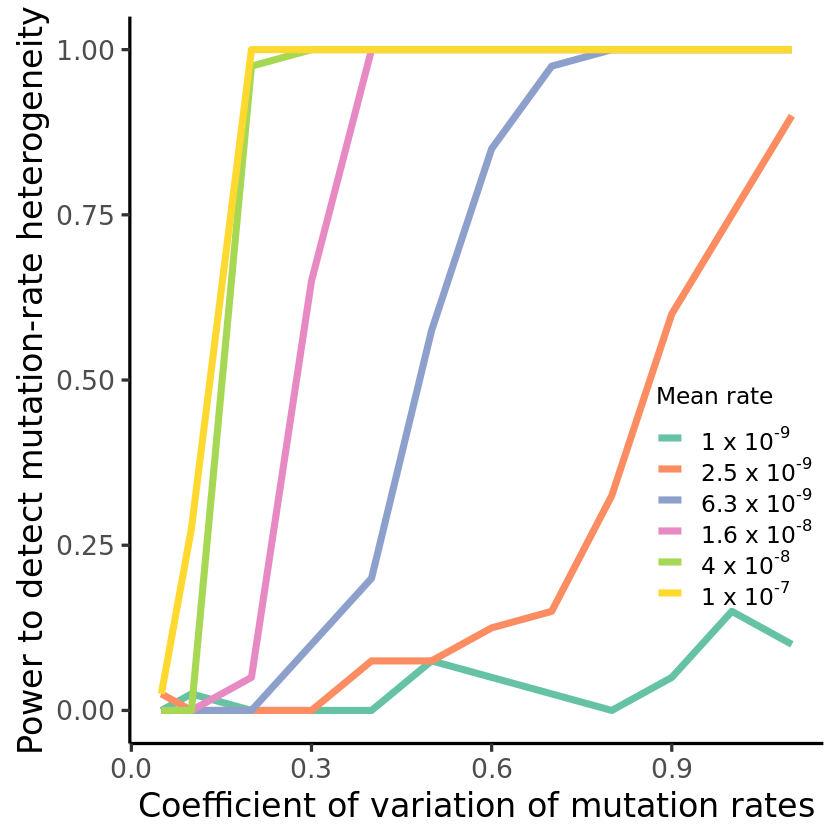

In [13]:
mutation_rate_dist %>%
    extract(filename,into=c("true_mu","CV","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_CV_([0-9.]+)_rep_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    mutate(LR = 2*(LL_single-LL_dist)) %>%
    mutate(p_val = pchisq(LR,df=1,lower.tail=FALSE)) %>%
    group_by(true_mu,CV) %>%
    summarise(power = mean(p_val<0.05), est_CV_avg_ratio = mean(sd_theta/mean_theta), est_CV_ratio_avg = mean(sd_theta)/mean(mean_theta), est_mu = mean(mean_theta/(4*14448)), est_sd = mean(sd_theta)) %>%
    ggplot(aes(CV,power)) +
    geom_line(aes(color=as.factor(true_mu)),size=2) +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    labs(color="Mean rate") +
    theme_classic(base_size=20) +
    ylab("Power to detect mutation-rate heterogeneity") +
    xlab("Coefficient of variation of mutation rates") +
    theme(legend.position = c(.87,.34),legend.background = element_rect(fill = NA, color = NA),legend.title = element_text(size = 14),legend.text = element_text(size = 14),legend.spacing.y = unit(1,"pt"))

ggsave("/scratch1//schraibe//rare_alleles/fig/CV_power.pdf")

In [21]:
summarised_rates = mutation_rate_dist %>%
    extract(filename,into=c("true_mu","CV","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_CV_([0-9.]+)_rep_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    mutate(LR = 2*(LL_single-LL_dist)) %>%
    mutate(p_val = pchisq(LR,df=1,lower.tail=FALSE)) %>%
    group_by(true_mu,CV) %>%
    summarise(single = mean(mu),  dist = mean(mean_theta/(4*14448))) %>%
    pivot_longer(single:dist,names_to="method",values_to="mu") %>%
    ungroup()


-- Column specification --------------------------------------------------------
cols(
  true_mu = col_double(),
  CV = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)

`summarise()` has grouped output by 'true_mu'. You can override using the
`.groups` argument.


Saving 6.67 x 6.67 in image


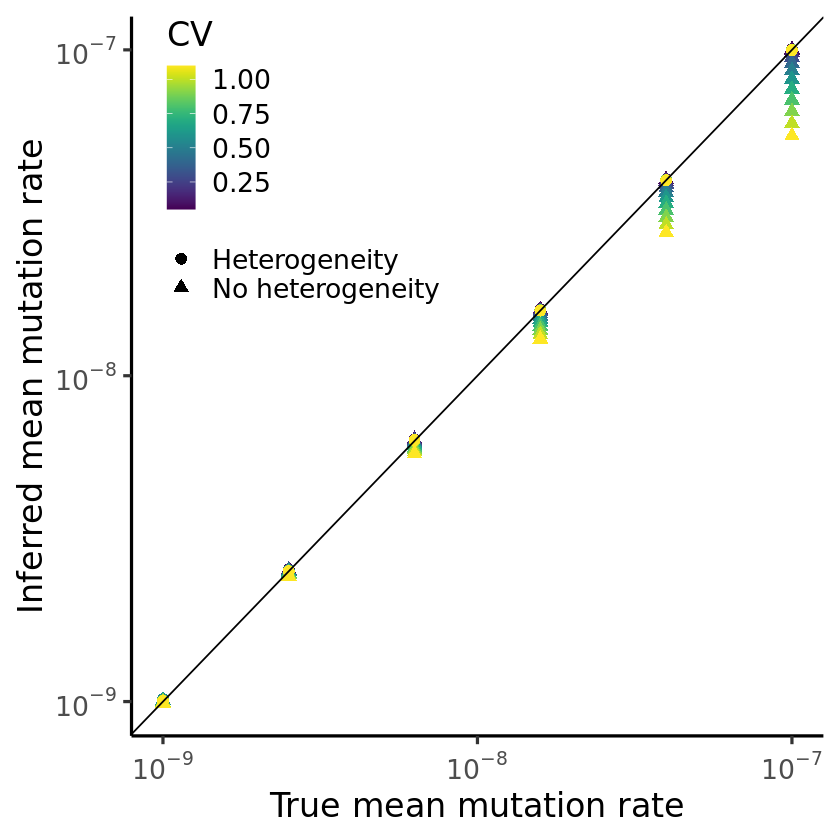

In [25]:
summarised_rates %>%
    mutate(method=ifelse(method=="single","No heterogeneity","Heterogeneity")) %>% 
    mutate(method=as.factor(method)) %>% 
    ggplot(aes(true_mu,mu)) +
    geom_point(aes(color=CV,shape=method),size=3) +
    scale_color_viridis() +
    theme_classic(base_size=20) +
    geom_abline(slope=1) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    labs(shape=NULL) +
    theme(legend.position = c(.25,.8),legend.spacing.y = unit(1,"pt")) +
    xlab("True mean mutation rate") +
    ylab("Inferred mean mutation rate")

ggsave("/scratch1/schraibe/rare_alleles/fig/mutation_rate_heterogeneity_mean.pdf")


-- Column specification --------------------------------------------------------
cols(
  true_mu = col_double(),
  CV = col_double(),
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)

`summarise()` has grouped output by 'true_mu', 'CV'. You can override using the
`.groups` argument.
Warning message:
"Using alpha for a discrete variable is not advised."
Saving 6.67 x 6.67 in image
Warning message:
"Using alpha for a discrete variable is not advised."


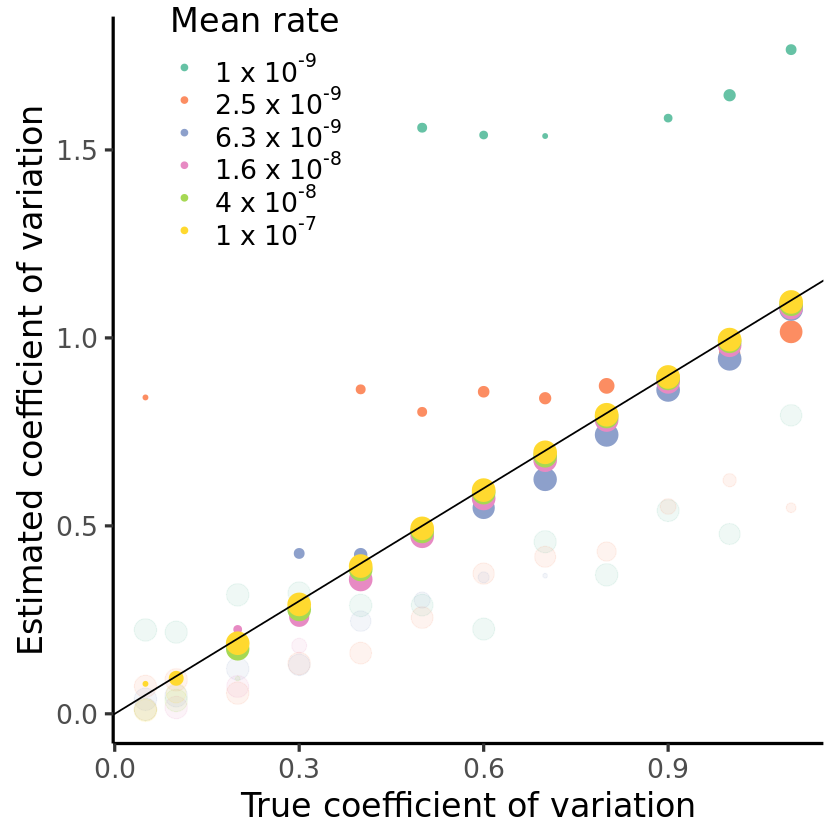

In [26]:
mutation_rate_dist %>%
    extract(filename,into=c("true_mu","CV","rep"),regex="mu_(-?[0-9]*\\.?[0-9]+[eE]?[-\\+]?[0-9]+)_CV_([0-9.]+)_rep_([0-9]+)\\.tsv") %>%
    type_convert() %>%
    mutate(LR = 2*(LL_single-LL_dist)) %>%
    mutate(p_val = pchisq(LR,df=1,lower.tail=FALSE)) %>%
    mutate(signif = p_val < 0.05) %>%
    group_by(true_mu,CV,signif) %>% 
    summarise(est_CV_avg_ratio = mean(sd_theta/mean_theta), est_CV_ratio_avg = mean(sd_theta)/mean(mean_theta), est_mu = mean(mean_theta/(4*14448)), est_sd = mean(sd_theta), num=n()) %>%
    ggplot(aes(CV,est_CV_avg_ratio)) +
    geom_point(aes(color=as.factor(signif(true_mu,digits=3)),size=num,alpha=signif)) +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    labs(color="Mean rate") +
    geom_abline(slope=1) +
    theme_classic(base_size = 20) +
    xlab("True coefficient of variation") +
    ylab("Estimated coefficient of variation") +
    # ylim(N) +
    guides(alpha="none",size="none") +
    theme(legend.position=c(.2,.85),legend.spacing.y = unit(1,"pt"))

ggsave("/scratch1//schraibe//rare_alleles/fig/CV_inference.pdf")

In [20]:
commands = c()
num_rep = 50
AN = c(10000,100000,1000000)
for (i in 1:num_rep) {
    command = paste0("Rscript test_demography_inference.r ",AN," ", pmin(as.integer(.01*AN),1000), " 5000000 test_demography/exponential_demography_AN_",AN,"_rep_", i,".tsv")
    commands = c(command,commands)
}

In [21]:
write_lines(commands,"/scratch1/schraibe/rare_alleles/sims/new_demography_inference/exponential_demography.cmd")

In [18]:
exp_growth = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/test_demography/*.tsv"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() #%>%
    #mutate(est = 14448*est)

Rows: 1500 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (4): par, est, lnL, AN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)



In [19]:
exp_growth_theta = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/test_demography/*.tsv.theta"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() 

Rows: 450 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (4): theta, LL, num_sites, AN
lgl (1): methylation_level

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)



In [20]:
exp_growth_infinite_sites = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/infinite_sites_demography/*.tsv"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert()

Rows: 1500 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (4): par, est, lnL, AN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)



In [21]:
exp_growth_infinite_sites_theta = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/infinite_sites_demography/*.tsv.theta"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() 

Rows: 300 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (3): p0, theta, AN
lgl (1): methylation_level

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)



In [22]:
Ne = c(14448,14068,14068,14464,14464,15208,15208,16256,16256,17618,17618,19347,
      19347,21534,21534,24236,24236,27367,27367,30416,30416,32060,32060,31284,
      29404,26686,23261,18990,16490,16490,12958,12958,9827,9827,7477,7477,5791,
      5791,4670,4670,3841,3841,3372,3372,3287,3359,3570,4095,4713,5661,7540,11375,
      14310,13292,13292,1245338,25013284)
T = c(70000,55940,51395,47457,43984,40877,38067,35501,33141,30956,28922,27018,25231,23545,
     21951,20439,19000,17628,16318,15063,13859,12702,11590,10517,9482,8483,7516,6580,
     5672,5520,5156,4817,4500,4203,3922,3656,3404,3165,2936,2718,2509,2308,2116,1930,
     1752,1579,1413,1252,1096,945,798,656,517,383,252,25,0)

T = (T[1]-T)#/(2*Ne[1]) #PROBABLY PUT BACK IN GENERATIONS

Ne = Ne#/Ne[1] #PROBABLY PUT BACK IN REAL UNITS

R = rep(0,length(Ne))
R[length(R)-1] = .12#*2*14448
R[length(R)-2] = .02#*2*14448

In [23]:
num_bin = 10
start_time = 0.0004
end_time = 0.025
burnin = 10
num_replace = num_bin

T_fit = rev(c(0,exp(seq(log(start_time),log(end_time),len=num_bin)),end_time+burnin))

T_fit = T_fit[1]-T_fit #flip the T

Ne_start = rep(1,length(T_fit))

R_fit = rep(0,length(Ne_start))

cur_Ne = Ne_start[1:(length(Ne_start)-(num_replace+1))]

In [24]:
true_mean_theta = 4*14448*mean(c(1e-9,1e-8,1e-7))

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    2.426415    6.159454 3082.927781   24.969709  702.141983  853.859009
 [7] 1031.597003  662.854509  516.544512 1158.718999


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    1.584009    4.585411   23.334352   45.460533  132.199703   87.339989
 [7] 1309.954307 1050.202046  523.905792 4590.001714


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    6.421991   24.203851   70.541908  122.884512  188.549775  288.818319
 [7] 1180.977657 1811.471553 1923.460071 4688.372897


png 
  2

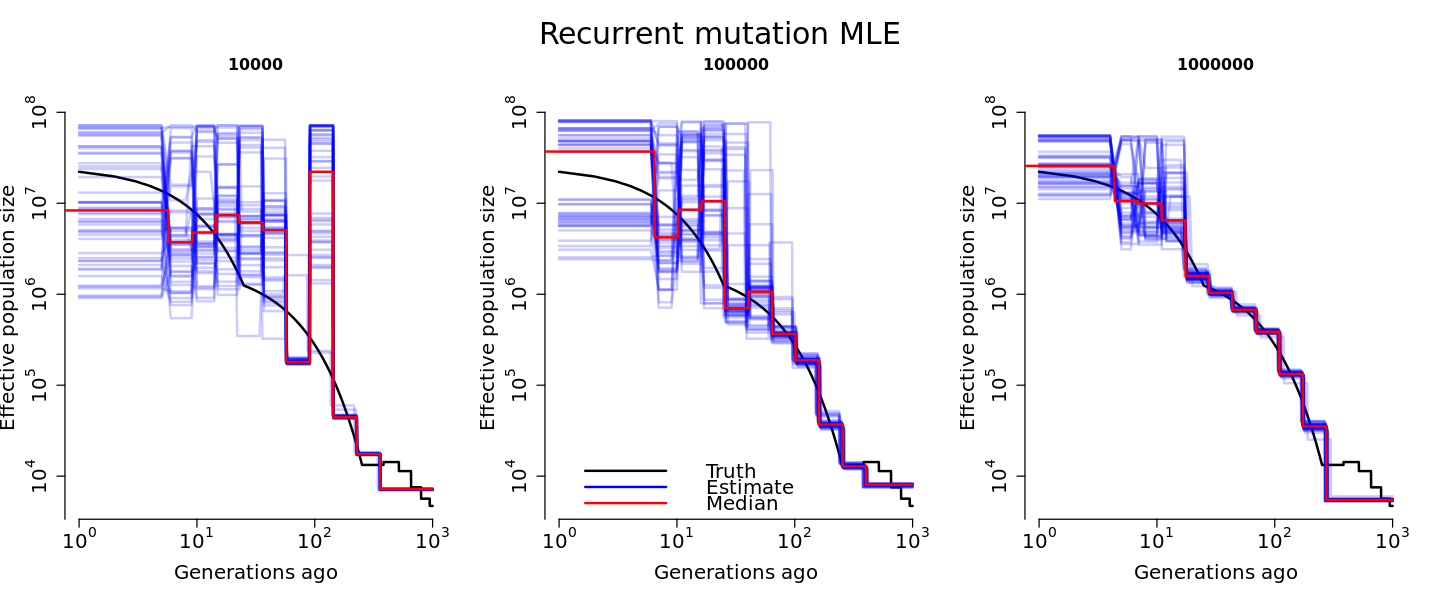

In [25]:
t = seq(max(T)-1000,max(T),1)

options(repr.plot.width=12, repr.plot.height=5)
par(mfrow=c(1,3),oma=c(0, 0, 2, 0))

rescaled_size = tibble()


for (ss in c(10000,100000,1000000)) {
    plot(max(T)-t,pop_size(t,Ne,R,T),type="l",log="xy", main=format(ss,scientific=FALSE), xlab = "Generations ago", ylab="Effective population size",xaxt="n",yaxt="n",ylim=c(5e3,1e8),lwd=2,cex.axis=1.5,cex.lab=1.5,bty="n")
    #Custom x-axis with powers of 10
    axis(1, at = 10^(0:3), labels = expression(10^0, 10^1, 10^2, 10^3),cex.axis=1.5)
    
    #Custom y-axis with powers of 10
    
    axis(2, at = 10^(0:8), labels = expression(10^0, 10^1, 10^2, 10^3, 10^4, 10^5, 10^6, 10^7,10^8),cex.axis=1.5)

    if (ss == 100000) {
        legend("bottom",c("Truth","Estimate","Median"),col=c("Black","Blue","Red"),lty=1,bty="n",lwd=2,cex=1.5)
    }
    
    num_rep = 50

    rescaled_N0 = c()

    pop_sizes = matrix(nrow=num_rep, ncol=length(t))
    
    for (i in 1:num_rep) {
        # message(i)
        inf_mean_theta = exp_growth_theta %>% filter(rep==i,AN==ss) %>% 
            summarise(mean_theta = mean(theta)) %>%
            pull(mean_theta)

        if (is.na(inf_mean_theta)) { next }
        
        Ne_new = inf_mean_theta/true_mean_theta*14448

        rescaled_N0 = c(rescaled_N0,Ne_new)

        cur_size = exp_growth %>% filter(AN==ss) %>% filter(rep==i)

        cur_size = cur_size %>% mutate(est = est*Ne_new)

        rescaled_size = bind_rows(rescaled_size,cur_size)

        par = cur_size %>% pull(est)
                
        Ne_fit = c(cur_Ne*Ne_new,par[1:num_replace],par[num_replace])
    
        cur_T_fit = T_fit*2*Ne_new
        
        t_fit = seq(max(cur_T_fit)-1000,max(cur_T_fit),1)
            
        lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col=alpha("blue",.2),lwd=2)

        pop_sizes[i,] = pop_size(t_fit,Ne_fit,R_fit,cur_T_fit)

    }

    #plot the mean
    par = exp_growth %>% filter(AN==ss) %>% group_by(par) %>% summarise(est = median(est)) %>% pull(est)
    print(par)
    Ne_new = median(rescaled_N0)
    print(Ne_new)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])*Ne_new
    cur_T_fit = T_fit*2*Ne_new    
    t_fit = seq(max(cur_T_fit)-1000,max(cur_T_fit),.1)
    lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col="red",lwd=2)

    # mean_pop_size = colMeans(pop_sizes,na.rm=TRUE)

    # mean_pop_size = apply(pop_sizes,2,median,na.rm=TRUE)

    # lines(max(T)-t,mean_pop_size,col="red",lwd=2)

}

mtext("Recurrent mutation MLE", outer=TRUE, line=-1, cex=1.5)

options(repr.plot.width=7, repr.plot.height=7)

dev.copy2pdf(file="/scratch1//schraibe//rare_alleles/fig/exp_growth.pdf",width=12,height=5)

In [28]:
true_mean_theta = 4*14448*mean(c(1e-9,1e-8))

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    1.364905    1.074926    7.535656    4.409300   11.575192   74.121973
 [7]  474.565230  641.553686  412.625936 1032.596387


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]   1.150844   2.172539   9.939647  31.537208  51.867553  63.194361
 [7]  98.180240 201.915617 205.464510 531.657847


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    6.872921   18.264244   55.975800   98.568531  156.751745  201.539784
 [7]  412.199233  761.663568 1403.990560  933.696121


png 
  2

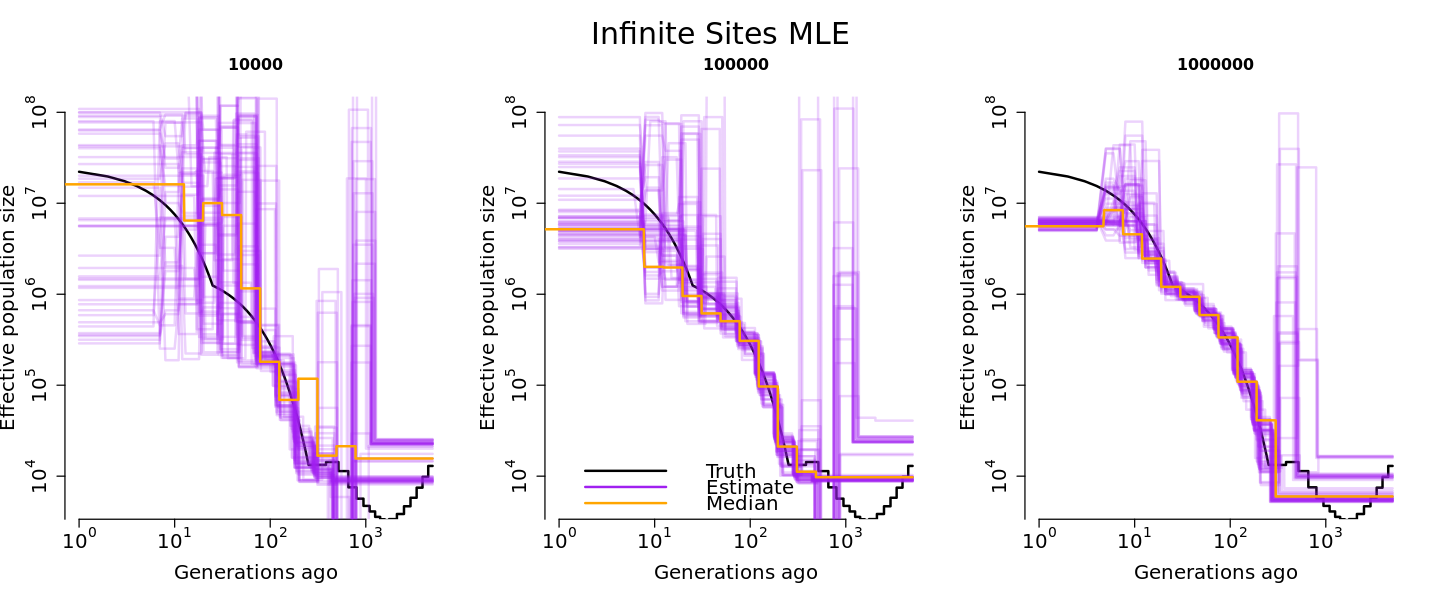

In [29]:
past_cutoff = 5000

t = seq(max(T)-past_cutoff,max(T),1)

options(repr.plot.width=12, repr.plot.height=5)
par(mfrow=c(1,3),oma=c(0, 0, 2, 0))

rescaled_size = tibble()


for (ss in c(10000,100000,1000000)) {
    plot(max(T)-t,pop_size(t,Ne,R,T),type="l",log="xy", main=format(ss,scientific=FALSE), xlab = "Generations ago", ylab="Effective population size",xaxt="n",yaxt="n",ylim=c(5e3,1e8),lwd=2,cex.axis=1.5,cex.lab=1.5,bty="n")
    #Custom x-axis with powers of 10
    axis(1, at = 10^(0:3), labels = expression(10^0, 10^1, 10^2, 10^3),cex.axis=1.5)
    
    #Custom y-axis with powers of 10
    
    axis(2, at = 10^(0:8), labels = expression(10^0, 10^1, 10^2, 10^3, 10^4, 10^5, 10^6, 10^7,10^8),cex.axis=1.5)

    if (ss == 100000) {
        legend("bottom",c("Truth","Estimate","Median"),col=c("Black","Purple","Orange"),lty=1,bty="n",lwd=2,cex=1.5)
    }
    
    num_rep = 50

    rescaled_N0 = c()

    pop_sizes = matrix(nrow=num_rep, ncol=length(t))
    
    for (i in 1:num_rep) {
        # message(i)
        inf_mean_theta = exp_growth_infinite_sites_theta %>% filter(rep==i,AN==ss) %>% 
            summarise(mean_theta = mean(theta)) %>%
            pull(mean_theta)

        if (is.na(inf_mean_theta)) { next }
        
        Ne_new = inf_mean_theta/true_mean_theta*14448

        rescaled_N0 = c(rescaled_N0,Ne_new)

        cur_size = exp_growth_infinite_sites %>% filter(AN==ss) %>% filter(rep==i)

        cur_size = cur_size %>% mutate(est = est*Ne_new)

        rescaled_size = bind_rows(rescaled_size,cur_size)

        par = cur_size %>% pull(est)
                
        Ne_fit = c(cur_Ne*Ne_new,par[1:num_replace],par[num_replace])
    
        cur_T_fit = T_fit*2*Ne_new
        
        t_fit = seq(max(cur_T_fit)-past_cutoff,max(cur_T_fit),1)
            
        lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col=alpha("purple",.2),lwd=2)

        pop_sizes[i,] = pop_size(t_fit,Ne_fit,R_fit,cur_T_fit)

    }

    #plot the mean
    par = exp_growth_infinite_sites %>% filter(AN==ss) %>% group_by(par) %>% summarise(est = median(est)) %>% pull(est)
    print(par)
    Ne_new = median(rescaled_N0)
    print(Ne_new)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])*Ne_new
    cur_T_fit = T_fit*2*Ne_new    
    t_fit = seq(max(cur_T_fit)-past_cutoff,max(cur_T_fit),.1)
    lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col="orange",lwd=2)

    # mean_pop_size = colMeans(pop_sizes,na.rm=TRUE)

    mean_pop_size = apply(pop_sizes,2,median,na.rm=TRUE)

    # lines(max(T)-t,mean_pop_size,col="red",lwd=2)

}

mtext("Infinite Sites MLE", outer=TRUE, line=-1, cex=1.5)

options(repr.plot.width=7, repr.plot.height=7)

dev.copy2pdf(file="/scratch1//schraibe//rare_alleles/fig/exp_growth_infinite_sites.pdf",width=12,height=5)

In [40]:
commands = c()
num_rep = 50
AN = c(10000,100000,1000000)
for (i in 1:num_rep) {
    command = paste0("Rscript test_demography_inference_decrease.r ",AN," ", pmin(as.integer(.01*AN),1000), " 5000000 decreasing_demography/decreasing_demography_AN_",AN,"_rep_", i,".tsv")
    commands = c(command,commands)
}

In [41]:
write_lines(commands,"/scratch1/schraibe/rare_alleles/sims/new_demography_inference/decreasing_demography.cmd")

In [30]:
decreasing_growth = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/decreasing_demography/*.tsv"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() #%>%
    #mutate(est = 14448*est)

Rows: 1500 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (4): par, est, lnL, AN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)



In [31]:
decreasing_growth_theta = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/decreasing_demography/*.tsv.theta"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() 

Rows: 450 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (4): theta, LL, num_sites, AN
lgl (1): methylation_level

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)



In [32]:
exp_growth_infinite_sites = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/infinite_sites_demography/*.tsv"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert()

Rows: 1500 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (4): par, est, lnL, AN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)



In [33]:
exp_growth_infinite_sites_theta = vroom(Sys.glob("/scratch1/schraibe/rare_alleles/sims/new_demography_inference/infinite_sites_demography/*.tsv.theta"),id="filename") %>%
    extract(filename,into="rep",regex="rep_([0-9]+)\\.tsv") %>%
    type_convert() 

Rows: 300 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (3): p0, theta, AN
lgl (1): methylation_level

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double(),
  ref_context = col_character(),
  alt_context = col_character()
)



In [34]:
#define model with decrease
Ne = c(14448,14068,14068,14464,14464,15208,15208,16256,16256,17618,17618,19347,
      19347,21534,21534,24236,24236,27367,27367,30416,30416,32060,32060,31284,
      29404,26686,23261,18990,16490,16490,12958,12958,9827,9827,7477,7477,5791,
      5791,4670,4670,3841,3841,3372,3372,3287,3359,3570,4095,4713,5661,7540,11375,
      14310,13292,13292,17803713,5362375)
T = c(70000,55940,51395,47457,43984,40877,38067,35501,33141,30956,28922,27018,25231,23545,
     21951,20439,19000,17628,16318,15063,13859,12702,11590,10517,9482,8483,7516,6580,
     5672,5520,5156,4817,4500,4203,3922,3656,3404,3165,2936,2718,2509,2308,2116,1930,
     1752,1579,1413,1252,1096,945,798,656,517,383,252,12,0)

T = (T[1]-T)#/(2*Ne[1])

# Ne = Ne/Ne[1]

R = rep(0,length(Ne))
R[length(R)-1] = -.1
R[length(R)-2] = .03

In [35]:
num_bin = 10
start_time = 0.0004
end_time = 0.025
burnin = 10
num_replace = num_bin

T_fit = rev(c(0,exp(seq(log(start_time),log(end_time),len=num_bin)),end_time+burnin))

T_fit = T_fit[1]-T_fit #flip the T

Ne_start = rep(1,length(T_fit))

R_fit = rep(0,length(Ne_start))

cur_Ne = Ne_start[1:(length(Ne_start)-(num_replace+1))]

In [36]:
true_mean_theta = 4*14448*mean(c(1e-9,1e-8,1e-7))

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    2.27060   15.04372 8350.89549 3384.00337 3129.78845 2140.02874
 [7] 1656.34372 1048.43088  633.23012  111.40483


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    0.816649    2.318893   22.530858  250.733124  183.598405 2499.709944
 [7] 3384.810476 3403.242012 2306.595271 4453.119513


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    0.3130322    4.9432576   42.2040911  233.9255285  376.7338503
 [6] 2435.2708328 2355.8400752 2058.6104207 1207.4039053  932.8116180


png 
  2

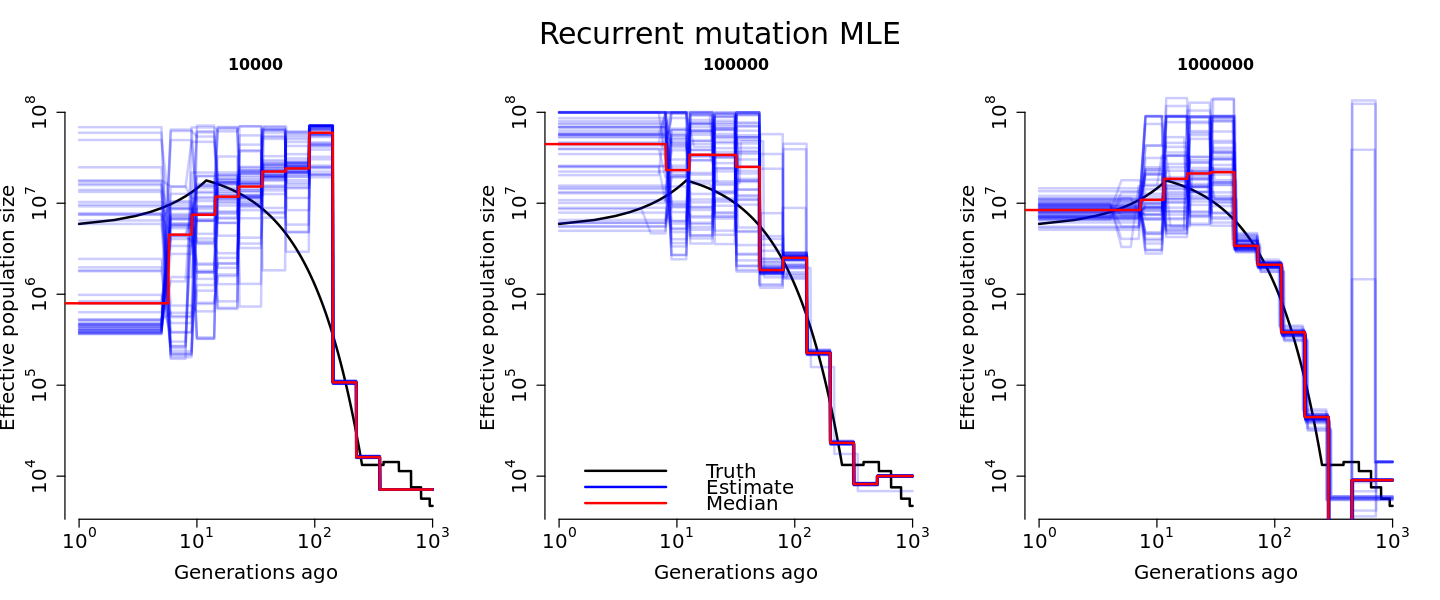

In [37]:
t = seq(max(T)-1000,max(T),1)

options(repr.plot.width=12, repr.plot.height=5)
par(mfrow=c(1,3),oma=c(0, 0, 2, 0))

rescaled_size = tibble()


for (ss in c(10000,100000,1000000)) {
    plot(max(T)-t,pop_size(t,Ne,R,T),type="l",log="xy", main=format(ss,scientific=FALSE), xlab = "Generations ago", ylab="Effective population size",xaxt="n",yaxt="n",ylim=c(5e3,1e8),lwd=2,cex.axis=1.5,cex.lab=1.5,bty="n")
    #Custom x-axis with powers of 10
    axis(1, at = 10^(0:3), labels = expression(10^0, 10^1, 10^2, 10^3),cex.axis=1.5)
    
    #Custom y-axis with powers of 10
    
    axis(2, at = 10^(0:8), labels = expression(10^0, 10^1, 10^2, 10^3, 10^4, 10^5, 10^6, 10^7,10^8),cex.axis=1.5)

    if (ss == 100000) {
        legend("bottom",c("Truth","Estimate","Median"),col=c("Black","Blue","Red"),lty=1,bty="n",lwd=2,cex=1.5)
    }
    
    num_rep = 50

    rescaled_N0 = c()

    pop_sizes = matrix(nrow=num_rep, ncol=length(t))
    
    for (i in 1:num_rep) {
        # message(i)
        inf_mean_theta = decreasing_growth_theta %>% filter(rep==i,AN==ss) %>% 
            summarise(mean_theta = mean(theta)) %>%
            pull(mean_theta)

        if (is.na(inf_mean_theta)) { next }
        
        Ne_new = inf_mean_theta/true_mean_theta*14448

        rescaled_N0 = c(rescaled_N0,Ne_new)

        cur_size = decreasing_growth %>% filter(AN==ss) %>% filter(rep==i)

        cur_size = cur_size %>% mutate(est = est*Ne_new)

        rescaled_size = bind_rows(rescaled_size,cur_size)

        par = cur_size %>% pull(est)
                
        Ne_fit = c(cur_Ne*Ne_new,par[1:num_replace],par[num_replace])
    
        cur_T_fit = T_fit*2*Ne_new
        
        t_fit = seq(max(cur_T_fit)-1000,max(cur_T_fit),1)
            
        lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col=alpha("blue",.2),lwd=2)

        pop_sizes[i,] = pop_size(t_fit,Ne_fit,R_fit,cur_T_fit)

    }

    #plot the mean
    par = decreasing_growth %>% filter(AN==ss) %>% group_by(par) %>% summarise(est = median(est)) %>% pull(est)
    print(par)
    Ne_new = median(rescaled_N0)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])*Ne_new
    cur_T_fit = T_fit*2*Ne_new    
    t_fit = seq(max(cur_T_fit)-1000,max(cur_T_fit),.1)
    lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col="red",lwd=2)

    # mean_pop_size = colMeans(pop_sizes,na.rm=TRUE)

    # mean_pop_size = apply(pop_sizes,2,median,na.rm=TRUE)

    # lines(max(T)-t,mean_pop_size,col="red",lwd=2)

}

mtext("Recurrent mutation MLE", outer=TRUE, line=-1, cex=1.5)

options(repr.plot.width=7, repr.plot.height=7)

dev.copy2pdf(file="/scratch1//schraibe//rare_alleles/fig/decrease_growth.pdf",width=12,height=5)

In [38]:
true_mean_theta = 4*14448*mean(c(1e-9,1e-8))

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    1.364905    1.074926    7.535656    4.409300   11.575192   74.121973
 [7]  474.565230  641.553686  412.625936 1032.596387


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]   1.150844   2.172539   9.939647  31.537208  51.867553  63.194361
 [7]  98.180240 201.915617 205.464510 531.657847


Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


 [1]    6.872921   18.264244   55.975800   98.568531  156.751745  201.539784
 [7]  412.199233  761.663568 1403.990560  933.696121


png 
  2

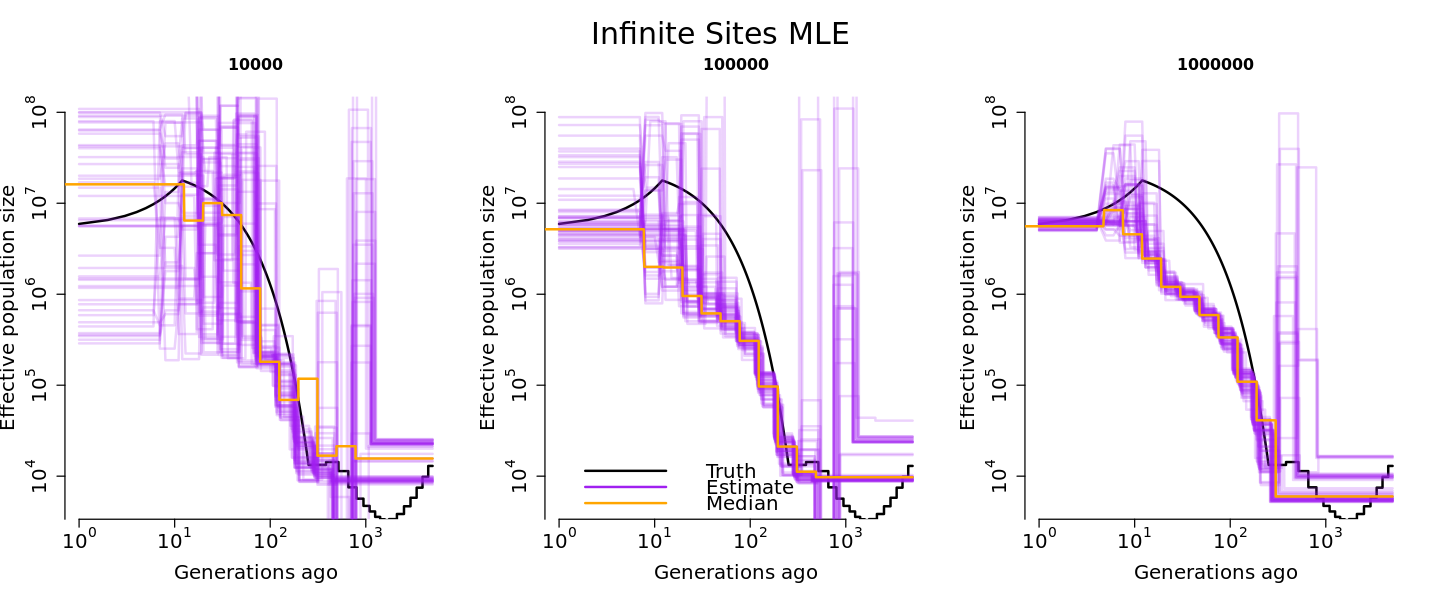

In [39]:
past_cutoff = 5000

t = seq(max(T)-past_cutoff,max(T),1)

options(repr.plot.width=12, repr.plot.height=5)
par(mfrow=c(1,3),oma=c(0, 0, 2, 0))

rescaled_size = tibble()


for (ss in c(10000,100000,1000000)) {
    plot(max(T)-t,pop_size(t,Ne,R,T),type="l",log="xy", main=format(ss,scientific=FALSE), xlab = "Generations ago", ylab="Effective population size",xaxt="n",yaxt="n",ylim=c(5e3,1e8),lwd=2,cex.axis=1.5,cex.lab=1.5,bty="n")
    #Custom x-axis with powers of 10
    axis(1, at = 10^(0:3), labels = expression(10^0, 10^1, 10^2, 10^3),cex.axis=1.5)
    
    #Custom y-axis with powers of 10
    
    axis(2, at = 10^(0:8), labels = expression(10^0, 10^1, 10^2, 10^3, 10^4, 10^5, 10^6, 10^7,10^8),cex.axis=1.5)

    if (ss == 100000) {
        legend("bottom",c("Truth","Estimate","Median"),col=c("Black","Purple","Orange"),lty=1,bty="n",lwd=2,cex=1.5)
    }
    
    num_rep = 50

    rescaled_N0 = c()

    pop_sizes = matrix(nrow=num_rep, ncol=length(t))
    
    for (i in 1:num_rep) {
        # message(i)
        inf_mean_theta = exp_growth_infinite_sites_theta %>% filter(rep==i,AN==ss) %>% 
            summarise(mean_theta = mean(theta)) %>%
            pull(mean_theta)

        if (is.na(inf_mean_theta)) { next }
        
        Ne_new = inf_mean_theta/true_mean_theta*14448

        rescaled_N0 = c(rescaled_N0,Ne_new)

        cur_size = exp_growth_infinite_sites %>% filter(AN==ss) %>% filter(rep==i)

        cur_size = cur_size %>% mutate(est = est*Ne_new)

        rescaled_size = bind_rows(rescaled_size,cur_size)

        par = cur_size %>% pull(est)
                
        Ne_fit = c(cur_Ne*Ne_new,par[1:num_replace],par[num_replace])
    
        cur_T_fit = T_fit*2*Ne_new
        
        t_fit = seq(max(cur_T_fit)-past_cutoff,max(cur_T_fit),1)
            
        lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col=alpha("purple",.2),lwd=2)

        pop_sizes[i,] = pop_size(t_fit,Ne_fit,R_fit,cur_T_fit)

    }

    #plot the mean
    par = exp_growth_infinite_sites %>% filter(AN==ss) %>% group_by(par) %>% summarise(est = median(est)) %>% pull(est)
    print(par)
    Ne_new = median(rescaled_N0)
    Ne_fit = c(cur_Ne,par[1:num_replace],par[num_replace])*Ne_new
    cur_T_fit = T_fit*2*Ne_new    
    t_fit = seq(max(cur_T_fit)-past_cutoff,max(cur_T_fit),.1)
    lines(max(cur_T_fit)-t_fit,pop_size(t_fit,Ne_fit,R_fit,cur_T_fit),col="orange",lwd=2)

    # mean_pop_size = colMeans(pop_sizes,na.rm=TRUE)

    mean_pop_size = apply(pop_sizes,2,median,na.rm=TRUE)

    # lines(max(T)-t,mean_pop_size,col="red",lwd=2)

}

mtext("Infinite Sites MLE", outer=TRUE, line=-1, cex=1.5)

options(repr.plot.width=7, repr.plot.height=7)

dev.copy2pdf(file="/scratch1//schraibe//rare_alleles/fig/decrease_growth_infinite_sites.pdf",width=12,height=5)

In [23]:
true_mu = c(1e-9,1e-8,1e-7)

In [24]:
true_mu_factor <- as.factor(signif(true_mu, digits = 3))

# Apply the custom formatting function to the levels of the factor
formatted_labels <- lapply(levels(true_mu_factor), function(x) {
  x <- as.numeric(as.character(x))
  format_sci(x)
})

In [25]:
a = p_mc(1000,max(T),4*14448*1e-9,1000000,0,Ne,R,T,nc=20)
b = p_mc(1000,max(T),4*14448*1e-8,1000000,0,Ne,R,T,nc=20)
c = p_mc(1000,max(T),4*14448*1e-7,1000000,0,Ne,R,T,nc=20)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."
Warning message:
"A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
i Please use the `legend.position.inside` argument of `theme()` instead."
Saving 6.67 x 6.67 in image


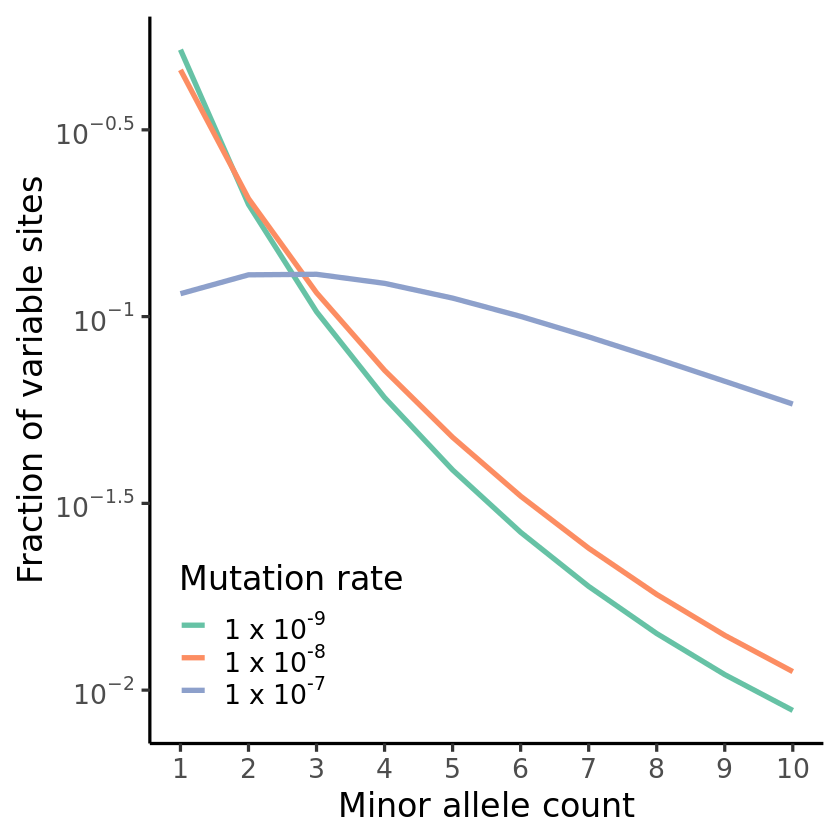

In [26]:
tibble(AC = 0:1000, a = a, b = b, c = c) %>%
    pivot_longer(2:4,names_to="mutation_rate",values_to="probability") %>%
    mutate(
        mutation_rate = case_when(
            mutation_rate == "a" ~ 1e-9,
            mutation_rate == "b" ~ 1e-8,
            mutation_rate == "c" ~ 1e-7
        )
    ) %>%
    filter(AC>0,AC<=10) %>%
    group_by(mutation_rate) %>%
    mutate(renorm = probability/sum(probability)) %>%
    ggplot(aes(AC,renorm)) +
    # geom_point(aes(color=as.factor(mutation_rate)),size=1.5) +
    geom_line(aes(color=as.factor(mutation_rate)),size=1.5) +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    labs(color="Mutation rate") + 
    theme_classic(base_size=20) +
    # scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log(),breaks=10^c(-2,-1.5,-1,-.5)) +
    scale_x_continuous(breaks=0:10) +
    theme(legend.position=c(.21,.15)) +
    xlab("Minor allele count") +
    ylab("Fraction of variable sites") 

ggsave("/scratch1//schraibe//rare_alleles/fig/example_SFS.pdf")

In [27]:
mu = 1e-7
theta = 4*14448*mu
CV = c(0,.2,.5)
theta_sd = theta*CV

In [28]:
alpha = theta^2/theta_sd^2
beta = theta/theta_sd^2

In [29]:
theta
alpha/beta
sqrt(alpha/beta^2)/(alpha/beta)

[1] 0.0057792

[1]       NaN 0.0057792 0.0057792

[1] NaN 0.2 0.5

In [30]:
a_dist = p_mc(1000,max(T),theta,1000000,0,Ne,R,T,nc=20)
b_dist = p_gamma_mc(1000,max(T),1000000,0,Ne,R,T,alpha[2],beta[2],nc=20)
c_dist = p_gamma_mc(1000,max(T),1000000,0,Ne,R,T,alpha[3],beta[3],nc=20)

Saving 6.67 x 6.67 in image


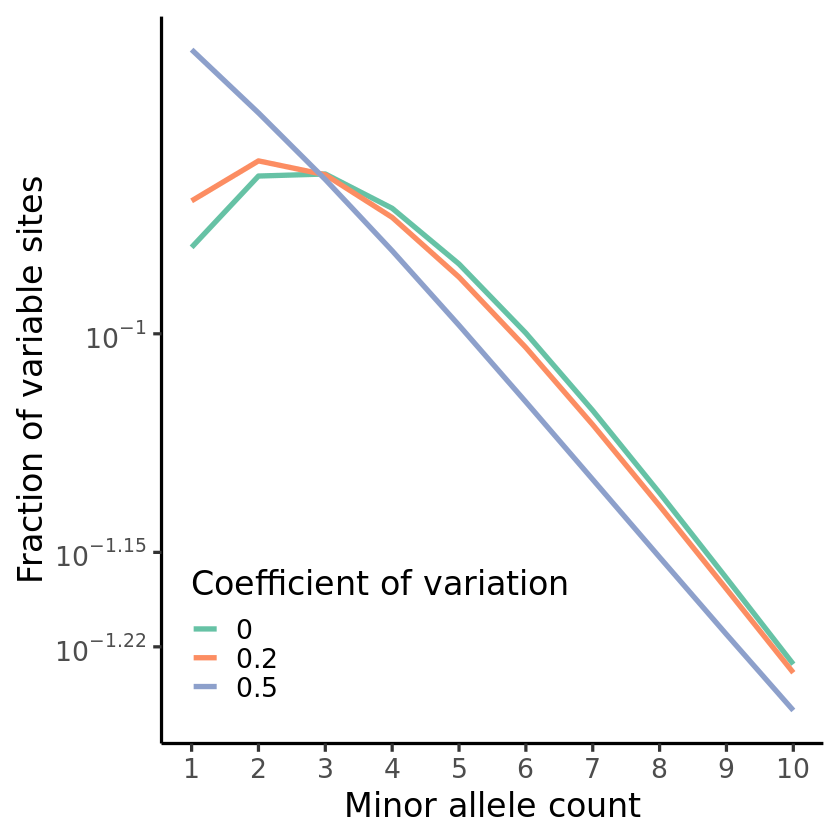

In [31]:
tibble(AC = 0:1000, a = a_dist, b = b_dist, c = c_dist) %>%
    pivot_longer(2:4,names_to="CV",values_to="probability") %>%
    mutate(
        CV = case_when(
            CV == "a" ~ 0,
            CV == "b" ~ .2,
            CV == "c" ~ .5,
        )
    ) %>%
    filter(AC>0,AC<=10) %>%
    group_by(CV) %>%
    mutate(renorm = probability/sum(probability)) %>%
    ggplot(aes(AC,renorm)) +
    geom_line(aes(color=as.factor(CV)),size=1.5) +
    scale_color_brewer(palette="Set2") + 
    labs(color="Coefficient of variation") + 
    theme_classic(base_size=20) +
    # scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log()) +
    scale_x_continuous(breaks=0:10) +
    theme(legend.position=c(.33,.15)) +
    xlab("Minor allele count") +
    ylab("Fraction of variable sites")

ggsave("/scratch1//schraibe//rare_alleles/fig/example_SFS_gamma.pdf")

In [17]:
SFS_to_analyze = vroom("/project/edgem_352/schraibe/gnomad_v4/SFS_to_analyze.tsv.gz")

Rows: 144144 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): ref_context, alt_context, type
dbl (3): methylation_level, AC, n

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [18]:
flat_0.025_10 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_0.025/real_data_flat_0.025_10/",10,0.0004,0.025,1)

Rows: 650 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)



In [19]:
gnomad_mutation = vroom("/scratch1/schraibe/rare_alleles/gnomad_v3_mutation.tsv")

Rows: 156 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): context, ref, alt, variant_type
dbl (6): methylation_level, mu, possible_variants, observed_variants, propor...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [20]:
rescale_0.025_10 = rescale_pop_size(SFS_to_analyze,flat_0.025_10,gnomad_mutation)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


In [21]:
N0_fit = rescale_0.025_10$Ne[1]
Ne_fit_diffusion = rescale_0.025_10$Ne_diffusion
R_fit = rescale_0.025_10$R
T_fit_diffusion = rescale_0.025_10$T_diffusion

Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


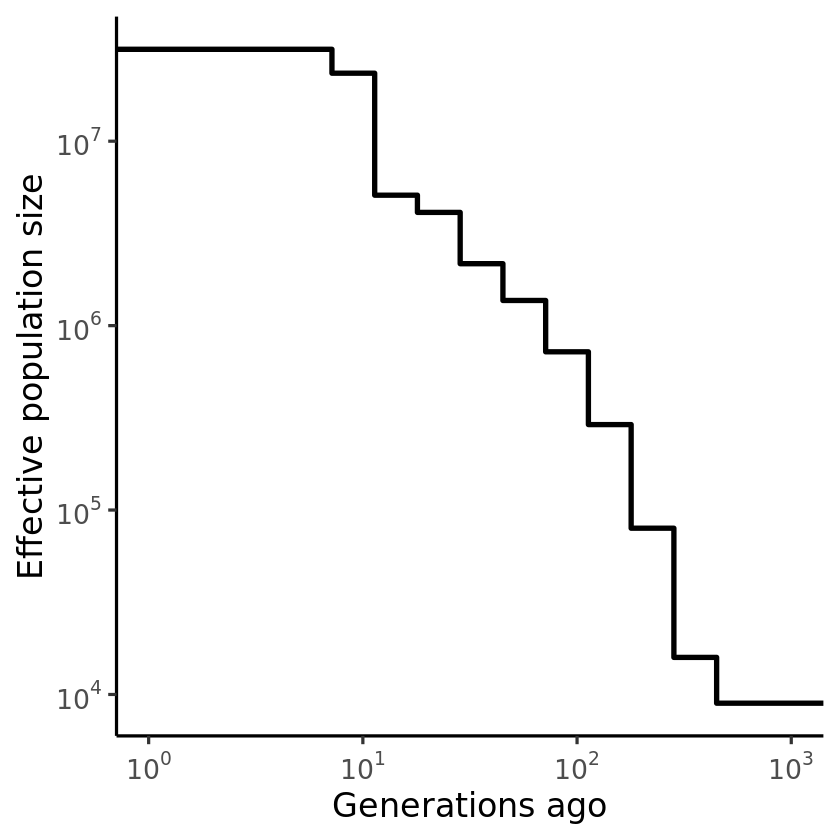

In [73]:
tibble(Ne = rescale_0.025_10$Ne, T = rescale_0.025_10$T,bin="10", max_T = "0.025") %>%
    group_by(max_T,bin) %>%
    mutate(T = max(T) - T) %>% 
    ggplot(aes(T,Ne)) +
    geom_step(direction="vh",size=1.5) +
    scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log()) +
    theme_classic(base_size=20) +
    xlab("Generations ago") +
    ylab("Effective population size") +
    coord_cartesian(xlim=c(1,1000))

ggsave("/scratch1/schraibe/rare_alleles/fig/inferred_demography.pdf")

In [74]:
Ne_table = tibble(Ne = rescale_0.025_10$Ne, T_start = max(rescale_0.025_10$T)-rescale_0.025_10$T)

In [75]:
Ne_table %>% write_tsv("/scratch1/schraibe/rare_alleles/fig/supp_table_Ne.tsv")

In [78]:
flat_0.2_10 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_0.2/real_data_flat_0.2_10/",10,0.0004,.2,1)
flat_0.2_15 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_0.2/real_data_flat_0.2_15/",15,0.0004,.2,1)
flat_0.1_15 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat/real_data_flat_15/",15,0.0004,.1,1)
flat_0.1_10 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat/real_data_flat_15/",10,0.0004,.1,1)
flat_0.05_10 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_0.05//real_data_flat_0.05_10/",10,0.0004,.05,1)
flat_1_15 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_1//real_data_flat_1_15/",15,0.0004,1,1)
flat_0.025_15 = read_pop_size_res_flat("/scratch1/schraibe//rare_alleles/real_data_flat_0.025/real_data_flat_0.025_15/",15,0.0004,0.025,1)

Rows: 980 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)

Rows: 1365 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_double()
)

Rows: 1500 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full colu

In [79]:
rescale_0.2_10 = rescale_pop_size(SFS_to_analyze,flat_0.2_10,gnomad_mutation)
rescale_0.2_15 = rescale_pop_size(SFS_to_analyze,flat_0.2_15,gnomad_mutation)
rescale_0.1_15 = rescale_pop_size(SFS_to_analyze,flat_0.1_15,gnomad_mutation)
rescale_0.1_10 = rescale_pop_size(SFS_to_analyze,flat_0.1_10,gnomad_mutation)
rescale_0.05_10 = rescale_pop_size(SFS_to_analyze,flat_0.05_10,gnomad_mutation)
rescale_1_15 = rescale_pop_size(SFS_to_analyze,flat_1_15,gnomad_mutation)
rescale_0.025_15 = rescale_pop_size(SFS_to_analyze,flat_0.025_15,gnomad_mutation)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` inste

Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


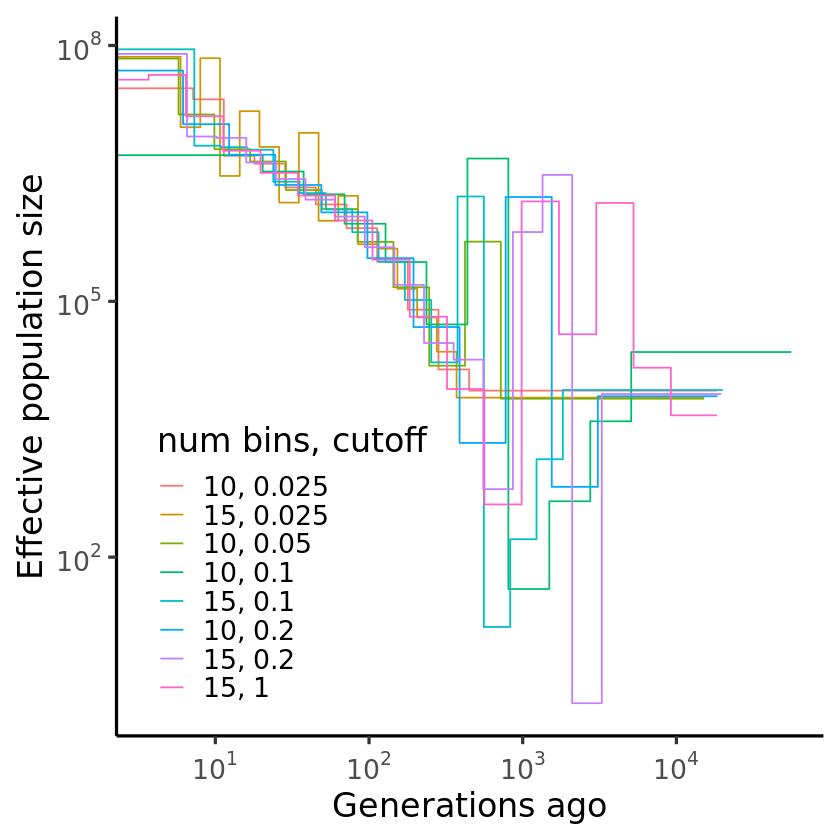

In [81]:
tibble(Ne = rescale_0.2_10$Ne, T = rescale_0.2_10$T,bin="10", max_T = "0.2") %>%
    bind_rows(
        tibble(Ne = rescale_0.2_15$Ne, T = rescale_0.2_15$T,bin="15", max_T = "0.2"),
        tibble(Ne = rescale_0.1_10$Ne, T = rescale_0.1_10$T,bin="10", max_T = "0.1"),
        tibble(Ne = rescale_0.1_15$Ne, T = rescale_0.1_15$T,bin="15", max_T = "0.1"),
        tibble(Ne = rescale_0.05_10$Ne, T = rescale_0.05_10$T,bin="10", max_T = "0.05"),
        tibble(Ne = rescale_1_15$Ne, T = rescale_1_15$T,bin="15", max_T = "1"),
        tibble(Ne = rescale_0.025_15$Ne, T = rescale_0.025_15$T,bin="15", max_T = "0.025"),
        tibble(Ne = rescale_0.025_10$Ne, T = rescale_0.025_10$T,bin="10", max_T = "0.025")
    ) %>%
    group_by(max_T,bin) %>%
    mutate(T = max(T) - T) %>% 
    ggplot(aes(T,Ne)) +
    geom_step(aes(color=interaction(bin,max_T,sep=", ")),direction="vh") +
    scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log()) +
    theme_classic(base_size=20) +
    labs(color="num bins, cutoff") +
    theme(legend.position = c(.25,.24)) +
    xlab("Generations ago") +
    ylab("Effective population size")

ggsave("/scratch1/schraibe/rare_alleles/fig/inferred_demography_diff_pars.pdf")

In [22]:
K = 1000
max_AC = K
AN = 1000000
start = 0

In [83]:
mutation_rates_FO = mutation_rate_FO(SFS_to_analyze,1000000,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion)

`summarise()` has grouped output by 'ref_context', 'alt_context'. You can
override using the `.groups` argument.


In [84]:
mutation_rates = mutation_rate_MLE(SFS_to_analyze,K=K,AN=AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,nc=20)

In [85]:
mutation_rates_no_target = mutation_rate_MLE(SFS_to_analyze,K=K,AN=AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,start=1,nc=20)

In [86]:
SFS_for_dist = SFS_to_analyze %>% 
    inner_join(mutation_rates)

Joining with `by = join_by(ref_context, alt_context, methylation_level)`


In [87]:
mutation_rates_dist = mutation_rate_dist_MLE(SFS_for_dist,K,AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,nc=20)

Precompute

Optimize

Done!



In [88]:
mutation_rates_dist_no_target = mutation_rate_dist_MLE(SFS_for_dist,K,AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,start=1,nc=20)

Precompute

Optimize

Done!



In [89]:
mutation_rates_rescaled = rescale_mut_rates(mutation_rates,gnomad_mutation)
mutation_rates_no_target_rescaled = rescale_mut_rates(mutation_rates_no_target,gnomad_mutation)

In [90]:
mutation_rates_dist_rescaled = rescale_mut_rates_dist(mutation_rates_dist,gnomad_mutation)
mutation_rates_dist_no_target_rescaled = rescale_mut_rates_dist(mutation_rates_dist_no_target,gnomad_mutation)

In [91]:
# write_tsv(mutation_rates_rescaled,"/scratch1/schraibe/rare_alleles/mutation_rates_rescaled.tsv.gz")
# write_tsv(mutation_rates_no_target_rescaled,"/scratch1/schraibe/rare_alleles/mutation_rates_no_target_rescaled.tsv.gz")
# write_tsv(mutation_rates_dist_rescaled,"/scratch1/schraibe/rare_alleles/mutation_rates_dist_rescaled.tsv.gz")
# write_tsv(mutation_rates_dist_no_target_rescaled,"/scratch1/schraibe/rare_alleles/mutation_rates_dist_no_target_rescaled.tsv.gz")

# write_tsv(mutation_rates,"/scratch1/schraibe/rare_alleles/mutation_rates.tsv.gz")
# write_tsv(mutation_rates_no_target,"/scratch1/schraibe/rare_alleles/mutation_rates_no_target.tsv.gz")
# write_tsv(mutation_rates_dist,"/scratch1/schraibe/rare_alleles/mutation_rates_dist.tsv.gz")
# write_tsv(mutation_rates_dist_no_target,"/scratch1/schraibe/rare_alleles/mutation_rates_dist_no_target.tsv.gz")

In [23]:
mutation_rates = vroom("/scratch1/schraibe/rare_alleles/mutation_rates.tsv.gz")
mutation_rates_dist = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_dist.tsv.gz")
mutation_rates_no_target = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_no_target.tsv.gz")
mutation_rates_no_target_dist = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_dist_no_target.tsv.gz")

mutation_rates_rescaled = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_rescaled.tsv.gz")
mutation_rates_dist_rescaled = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_dist_rescaled.tsv.gz")
mutation_rates_no_target_rescaled = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_no_target_rescaled.tsv.gz")
mutation_rates_dist_no_target_rescaled = vroom("/scratch1/schraibe/rare_alleles/mutation_rates_dist_no_target_rescaled.tsv.gz")

Rows: 144 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (4): methylation_level, theta, LL, num_sites

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 144 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (5): methylation_level, mean_theta, sd_theta, LL, n

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 144 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ref_context, alt_context
dbl (4): methylation_level, theta, LL, num_sites

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Speci

Saving 6.67 x 6.67 in image


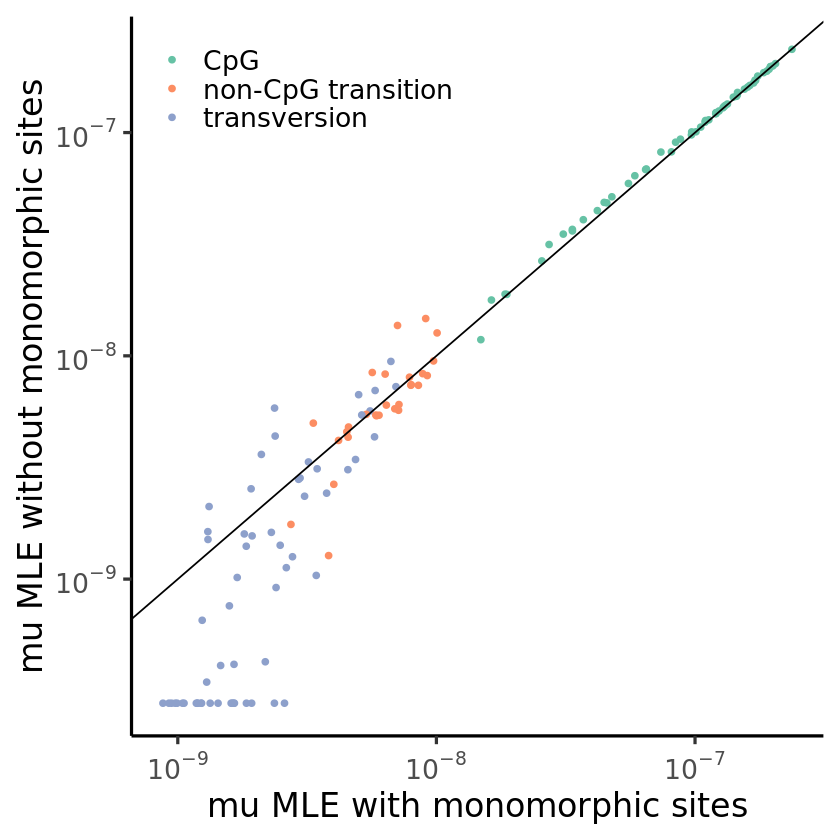

In [79]:
inner_join(mutation_rates_rescaled,mutation_rates_no_target_rescaled,by=c("ref_context","alt_context","methylation_level","variant_type"),suffix=c("_target","_no_target")) %>%
    ggplot(aes(theta_target,theta_no_target)) +
    geom_point(aes(color=variant_type)) +
    scale_color_brewer(palette="Set2") +
    geom_abline(slope=1) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    xlab("mu MLE with monomorphic sites") +
    ylab("mu MLE without monomorphic sites") +
    theme_classic(base_size=20) +
    theme(legend.position = c(.25,.9),legend.title=element_blank())

ggsave("/scratch1/schraibe/rare_alleles/fig/mutation_rate_with_and_without_target.pdf")

In [29]:
supp_table_mut = mutation_rates_rescaled %>%
    inner_join(mutation_rates_dist_rescaled,by=c("context","ref","alt","ref_context","alt_context","methylation_level","variant_type"),suffix=c("_no_heterogeneity","_heterogeneity")) %>%
    select(context, ref, alt, ref_context,alt_context, methylation_level,variant_type, num_sites, theta,mean_theta,sd_theta,LL_no_heterogeneity,LL_heterogeneity) %>%
    mutate(CV = sd_theta/mean_theta) %>% 
    mutate(LR = 2*(LL_no_heterogeneity-LL_heterogeneity)) %>%
    mutate(p_value = pchisq(LR,df=1,lower.tail=FALSE)) %>%
    mutate(p_adj = p.adjust(p_value,method="BH")) %>%
    arrange(p_adj)

In [25]:
supp_table_mut %>%
    count(p_adj<0.1)

p_adj < 0.1,n
<lgl>,<int>
FALSE,95
TRUE,49


In [26]:
supp_table_mut %>% write_tsv("/scratch1/schraibe/rare_alleles/fig/supp_table_mut.tsv")

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Saving 6.67 x 6.67 in image
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


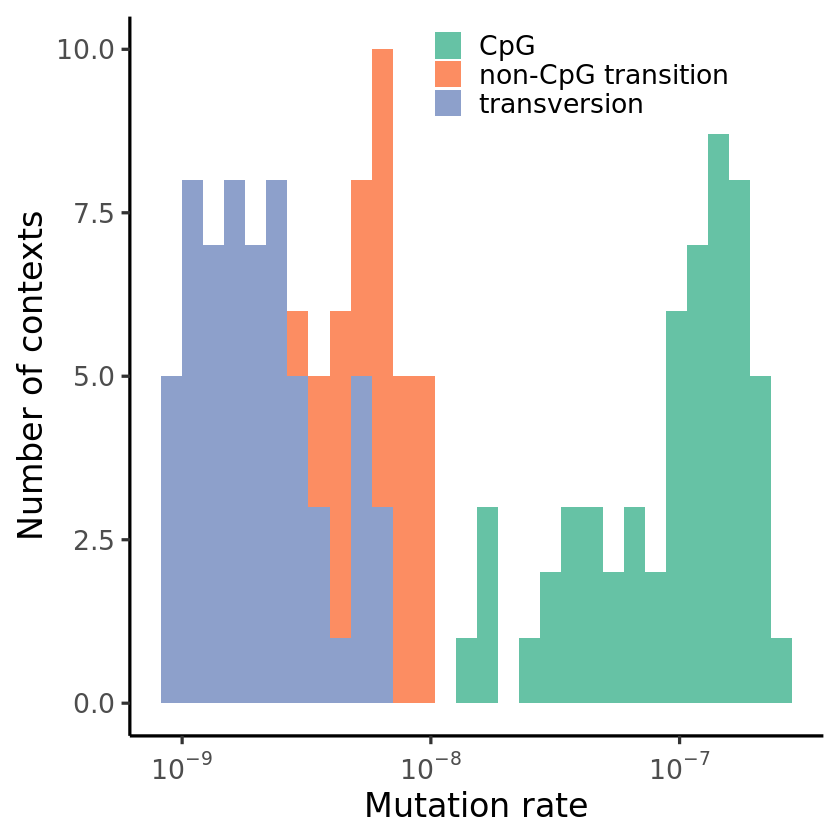

In [27]:
supp_table_mut %>%
    ggplot(aes(mean_theta)) +
    geom_histogram(aes(fill=variant_type)) +
    scale_fill_brewer(palette="Set2") + 
    scale_x_log10(labels=label_log()) +
    theme_classic(base_size=20) +
    xlab("Mutation rate") +
    ylab("Number of contexts") +
    theme(legend.position = c(.65,.92),legend.title=element_blank())

ggsave("/scratch1/schraibe/rare_alleles/fig/mutation_rate_dist.pdf")

Saving 6.67 x 6.67 in image


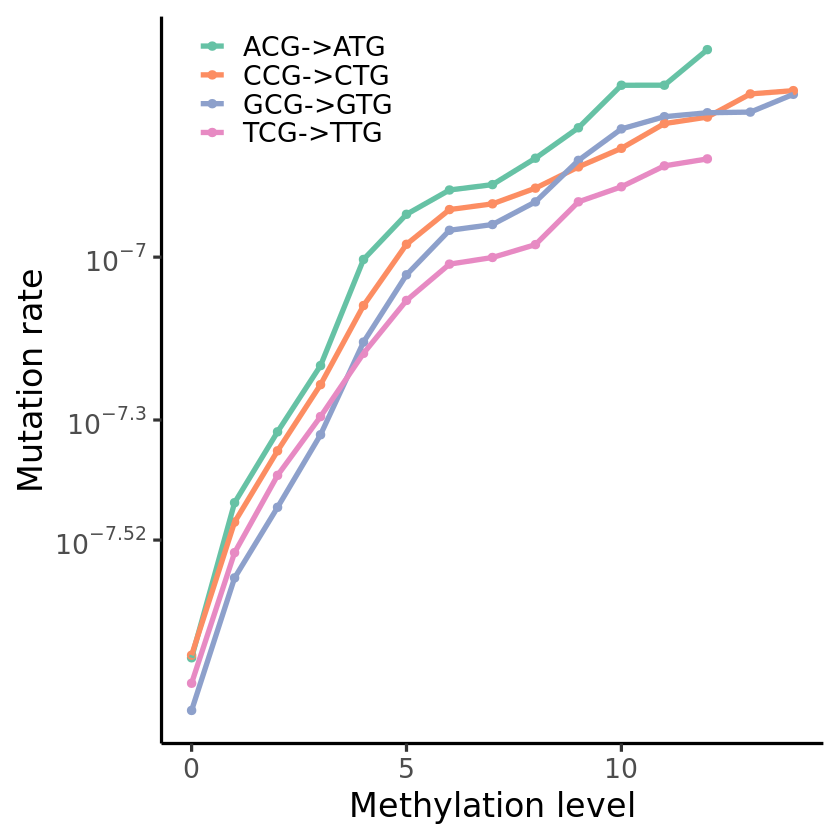

In [28]:
supp_table_mut %>%
    filter(variant_type=="CpG") %>%
    mutate(mutation_type = paste0(ref_context, "->", alt_context)) %>%
    ggplot(aes(methylation_level,mean_theta)) +
    geom_point(aes(color=mutation_type),size=2) +
    geom_line(aes(color=mutation_type),linewidth=1.5) +
    scale_color_brewer(palette="Set2") +
    theme_classic(base_size = 20) +
    scale_y_log10(labels=label_log()) +
    xlab("Methylation level") +
    ylab("Mutation rate") +
    theme(legend.position=c(.2,.9),legend.title=element_blank(),legend.spacing.y = unit(1,"pt"))

ggsave("/scratch1/schraibe/rare_alleles/fig/CpG.pdf")

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Saving 6.67 x 6.67 in image
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


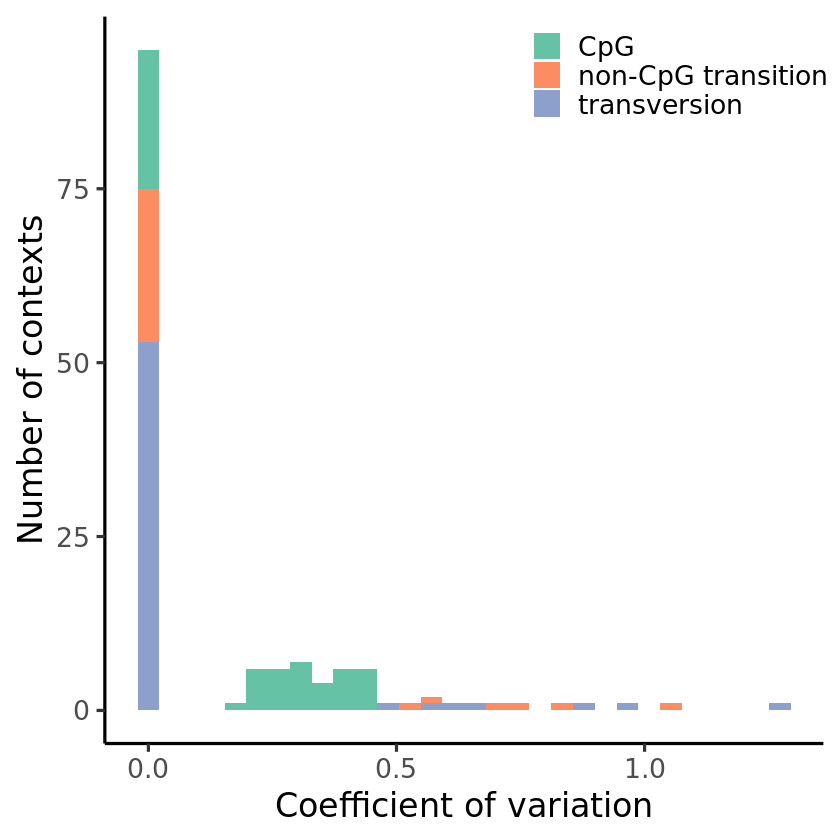

In [29]:
supp_table_mut %>% 
    mutate(CV = ifelse(p_adj > 0.1, 0,CV)) %>%
    ggplot(aes(CV)) +
    geom_histogram(aes(fill=variant_type)) +
    scale_fill_brewer(palette="Set2") +
    theme_classic(base_size=20) +
    xlab("Coefficient of variation") +
    ylab("Number of contexts") + 
    theme(legend.position = c(.8,.92),legend.title=element_blank())

ggsave("/scratch1/schraibe/rare_alleles/fig/CV.pdf")

Saving 6.67 x 6.67 in image


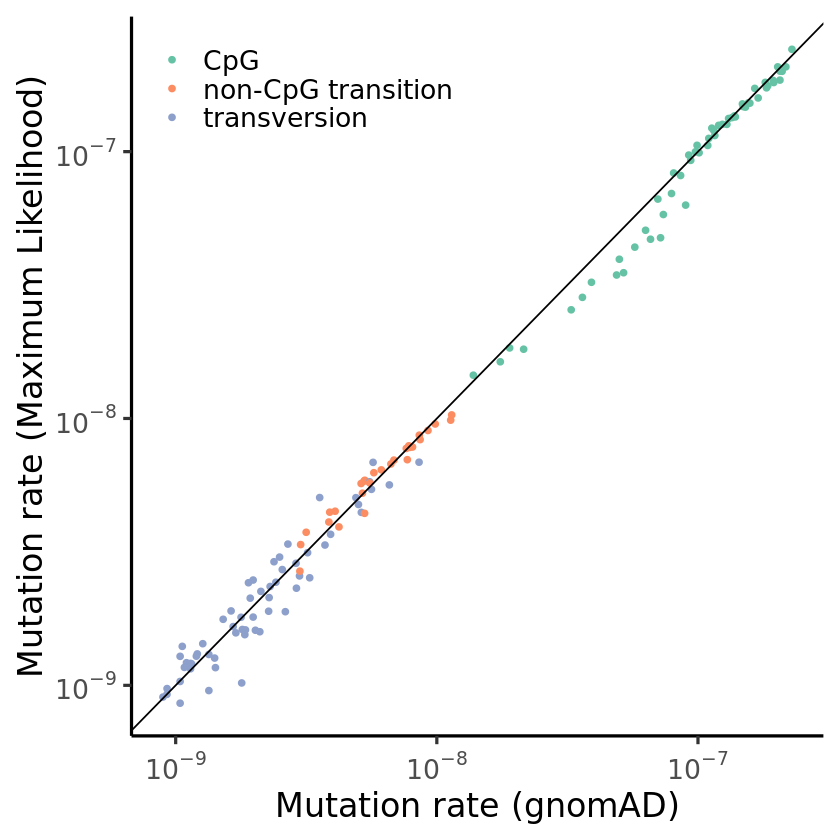

In [30]:
mutation_rates_dist_rescaled %>%
    ggplot(aes(mu,mean_theta)) +
    geom_point(aes(color=variant_type)) +
    scale_color_brewer(palette="Set2") +
    geom_abline(slope=1) +
    xlab("Mutation rate (gnomAD)") +
    ylab("Mutation rate (Maximum Likelihood)") +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    theme_classic(base_size=20) +
    theme(legend.position = c(.25,.9),legend.title=element_blank())

ggsave("/scratch1/schraibe/rare_alleles/fig/gnomad_comparison.pdf")

In [115]:
mutation_rates_dist_rescaled %>%
    drop_na() %>%
    group_by(variant_type) %>%
   summarise(cor(x=mu,y=mean_theta,method="spearman"))

variant_type,"cor(x = mu, y = mean_theta, method = ""spearman"")"
<chr>,<dbl>
CpG,0.9957791
non-CpG transition,0.9819376
transversion,0.9392967


In [40]:
mutation_rates_dist %>% 
    inner_join(mutation_rates,by=c("ref_context","alt_context","methylation_level"),suffix=c("_dist","_single")) %>%
    mutate(CpG = !is.na(methylation_level)) %>% 
    mutate(CpG_Ts = CpG&((substr(ref_context,2,2)=="C"&substr(alt_context,2,2)=="T") | (substr(ref_context,2,2)=="G"&substr(alt_context,2,2)=="A"))) %>%
    mutate(CV = sd_theta/mean_theta) %>%
    mutate(LR = 2*(LL_single-LL_dist)) %>% 
    arrange(mean_theta) %>%
    head(5)

ref_context,alt_context,methylation_level,mean_theta,sd_theta,LL_dist,n,theta,LL_single,num_sites,CpG,CpG_Ts,CV,LR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>
AAA,ATA,NA,5.510424e-05,1.000001e-07,14081.234,70007,5.510454e-05,14081.234,70007,FALSE,FALSE,0.001814744,-1.343597e-05
CAA,CTA,NA,5.810504e-05,3.550215e-07,52150.172,245800,5.810519e-05,52150.172,245800,FALSE,FALSE,0.006109994,-2.545840e-04
AAG,ATG,NA,5.948209e-05,2.820326e-07,21072.345,97816,5.948240e-05,21072.345,97816,FALSE,FALSE,0.004741471,-1.104293e-04
AAC,ATC,NA,6.145050e-05,6.685318e-07,5313.842,23917,6.144931e-05,5313.842,23917,FALSE,FALSE,0.010879192,-7.837533e-05
GAA,GTA,NA,6.251136e-05,2.922926e-07,35339.501,158478,6.251181e-05,35339.501,158478,FALSE,FALSE,0.004675832,-2.588753e-04


Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


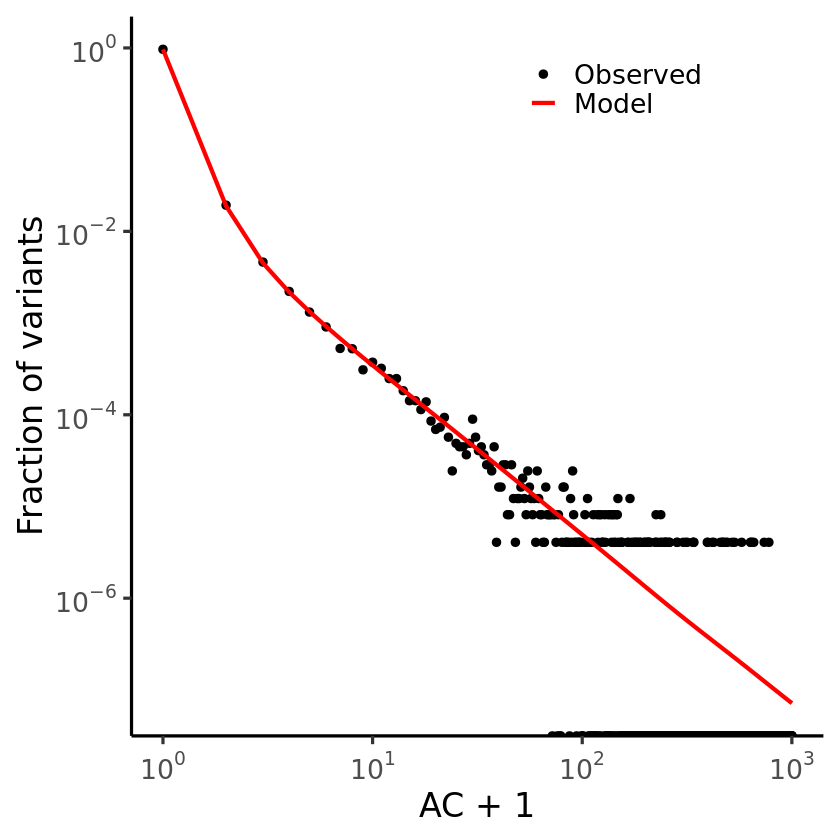

In [116]:
plot_SFS(SFS_to_analyze,"CAA","CTA",NA,K,AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,mutation_rates,mutation_rates_dist,nc=20,plot_dist=FALSE)

ggsave("/scratch1/schraibe/rare_alleles/fig/fit_CAA_CTA.pdf")

Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


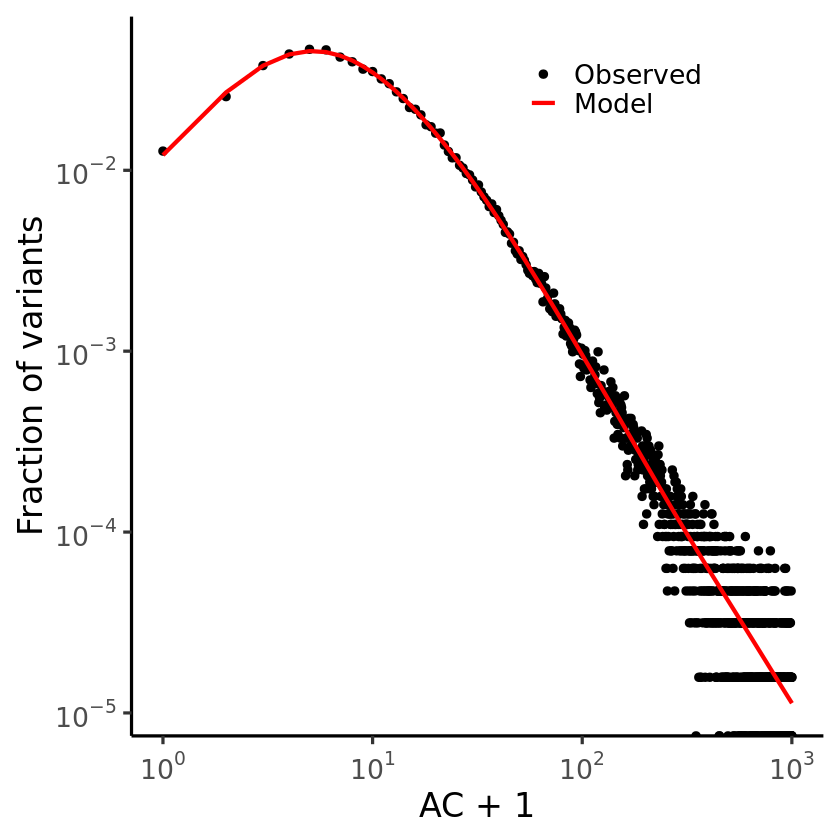

In [118]:
plot_SFS(SFS_to_analyze,"ACG","ATG",6,K,AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,mutation_rates,mutation_rates_dist,nc=20,plot_single=FALSE)
ggsave("/scratch1/schraibe/rare_alleles/fig/fit_ACG_ATG.pdf")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


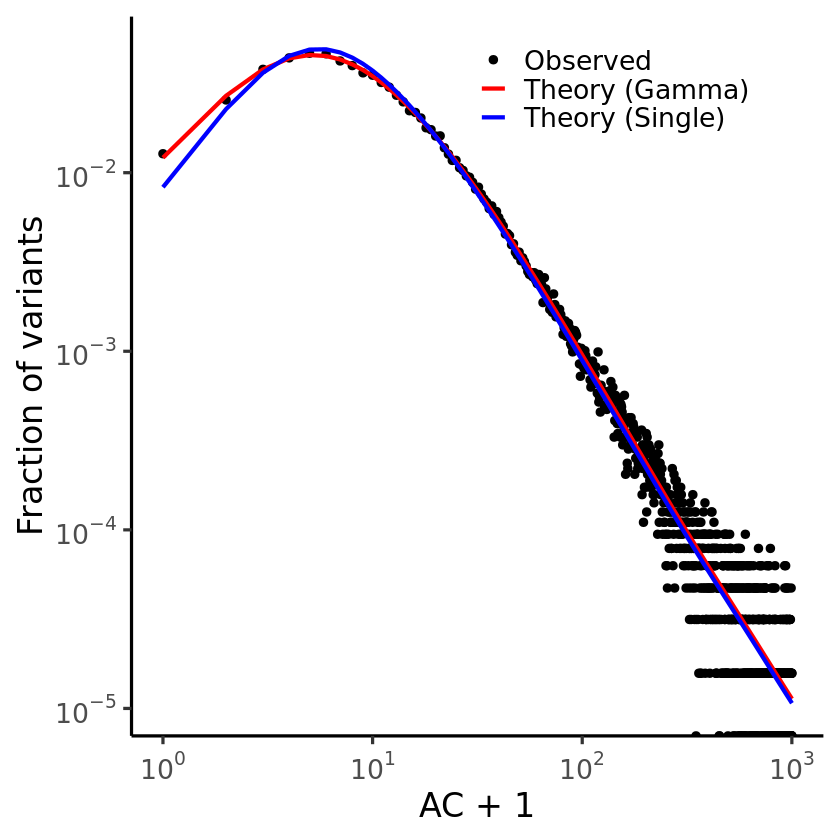

In [92]:
plot_SFS(SFS_to_analyze,"ACG","ATG",6,K,AN,rescale_0.025_10$Ne_diffusion,rescale_0.025_10$R,rescale_0.025_10$T_diffusion,mutation_rates,mutation_rates_dist,nc=20)
ggsave("/scratch1/schraibe/rare_alleles/fig/fit_ACG_ATG_with_single.pdf")

In [248]:
ss = 1000000
theta = 4*N0_fit*1e-8
res = tibble()
K = 50
g = 4*N0_fit*exp(seq(log(1e-4),log(1e-1),len=100))
prob = matrix(nrow=length(g),ncol=K)
for (i in 1:length(g)) {
    d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=-g[i],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
    b = bell_polynomial_tilde_DP(K,theta*d)
    prob[i,] = theta*d/b[2:length(b)]
}
cur_tibble = as_tibble(prob) %>% 
    mutate(g=g) %>% 
    pivot_longer(1:K,names_to="AC",values_to="prob_single") %>%
    mutate(AC = substring(AC,first=2,last=100000)) %>%
    type_convert() %>%
    mutate(theta=theta) 
res = bind_rows(res,cur_tibble)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)



Saving 6.67 x 6.67 in image


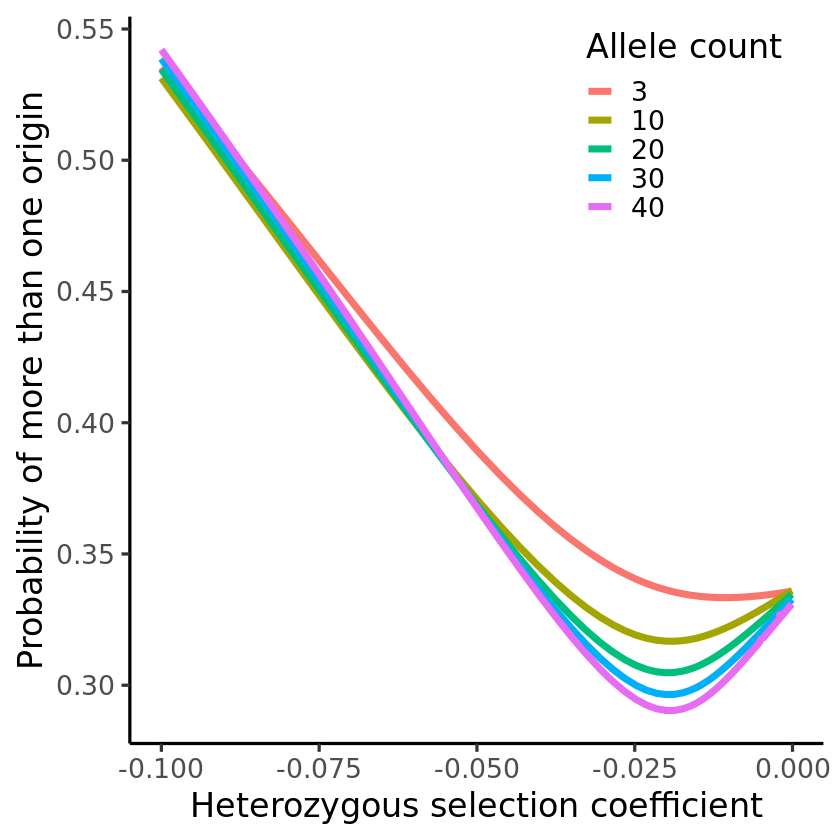

In [249]:
res %>%
    filter(AC%in%c(3,10,20,30,40)) %>%
    ggplot(aes(-g/(4*N0_fit),1-prob_single)) +
    geom_line(aes(color=as.factor(AC)),size=2) +
    theme_classic(base_size=20) +
    theme(legend.position=c(.8,.85)) +
    xlab("Heterozygous selection coefficient") +
    ylab("Probability of more than one origin") +
    labs(color="Allele count") 

ggsave("/scratch1/schraibe/rare_alleles/fig/p_multiple_s.pdf")

In [250]:
ss = 1000000
theta = 4*N0_fit*1e-8
res = tibble()
K = 50
g = 4*N0_fit*exp(seq(log(1e-4),log(1e-1),len=200))
bell = matrix(nrow=length(g),ncol=K)
dmat = matrix(nrow=length(g),ncol=K)
rescaled = matrix(nrow=length(g),ncol=K)
for (i in 1:length(g)) {
    d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=-g[i],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
    b = bell_polynomial_tilde_DP(K,theta*d)
    bell[i,] = b[2:length(b)]
    dmat[i,] = theta*d
}
bell_tibble = as_tibble(bell) %>% 
    mutate(g=g) %>% 
    pivot_longer(1:K,names_to="AC",values_to="bell") %>%
    mutate(AC = substring(AC,first=2,last=100000)) %>%
    type_convert() %>%
    mutate(theta=theta) 

d_tibble = as_tibble(dmat) %>% 
    mutate(g=g) %>% 
    pivot_longer(1:K,names_to="AC",values_to="d") %>%
    mutate(AC = substring(AC,first=2,last=100000)) %>%
    type_convert() %>%
    mutate(theta=theta) 

res_d = inner_join(d_tibble,bell_tibble) 


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)

Joining with `by = join_by(g, AC, theta)`


In [251]:
ss = 1000000
theta = 4*N0_fit*1e-8
res = tibble()
K = 10
gamma = 4*N0_fit*exp(seq(log(1e-4),log(1e-1),len=200))
res = tibble()
for (i in 1:length(gamma)) {
    d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=-gamma[i],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
    b = bell_polynomial_tilde_DP(K,theta*d)
    # message(paste(d, collapse=" "))
    # message(paste(b,collapse=" "))
    for (k in 1:K) {
        cur_b = b[1:(k+1)]
        cur_d = theta*d[1:k]
        cigk = cur_d*rev(cur_b[1:k])/b[k+1]
        expected_muts = sum(cigk)
        pigk = cigk/expected_muts
        cur_tibble = tibble(g=rep(gamma[i],k),i=1:k,k=k,pi=pigk,emk = expected_muts)
        res = bind_rows(res,cur_tibble)
    }
}

Saving 6.67 x 6.67 in image


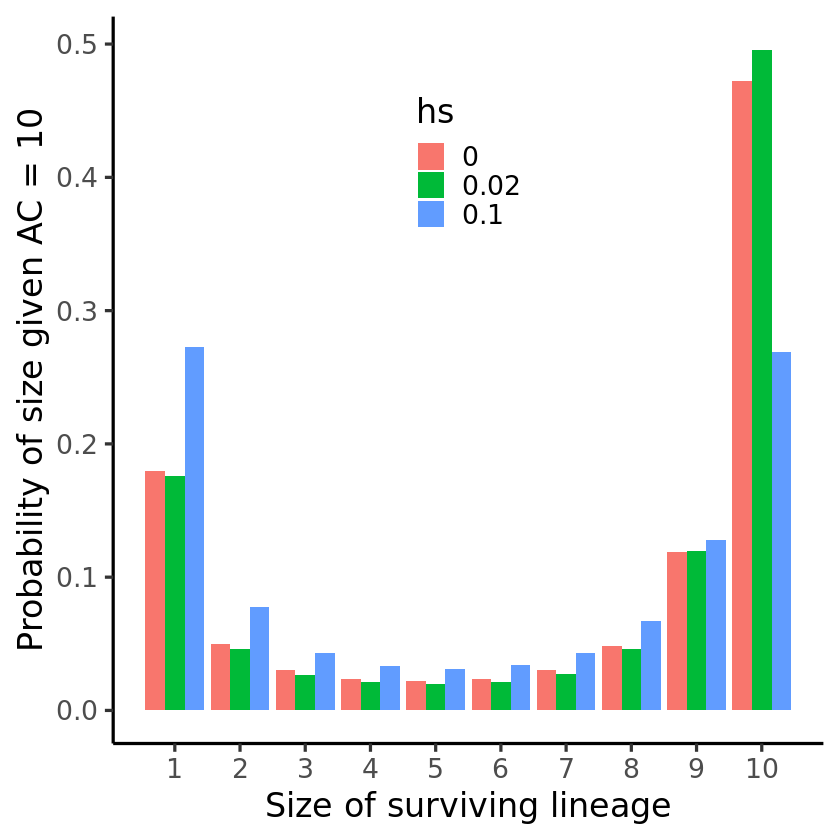

In [252]:
res %>%
    group_by(k) %>%
    mutate(min_emk = emk==min(emk)) %>%
    filter(k==10) %>%
    filter(min_emk|g==min(g)|g==max(g)) %>%
    ggplot(aes(i,pi)) +
    geom_bar(aes(fill=as.factor(round(g/(4*N0_fit),2))),stat="identity",position="dodge") +
    theme_classic(base_size=20) +
    labs(fill="hs") +
    scale_x_continuous(breaks=1:10) +
    theme(legend.position = c(.5,.8)) +
    xlab("Size of surviving lineage") +
    ylab("Probability of size given AC = 10")

ggsave("/scratch1/schraibe/rare_alleles/fig/p_lineage_size.pdf")

Saving 6.67 x 6.67 in image


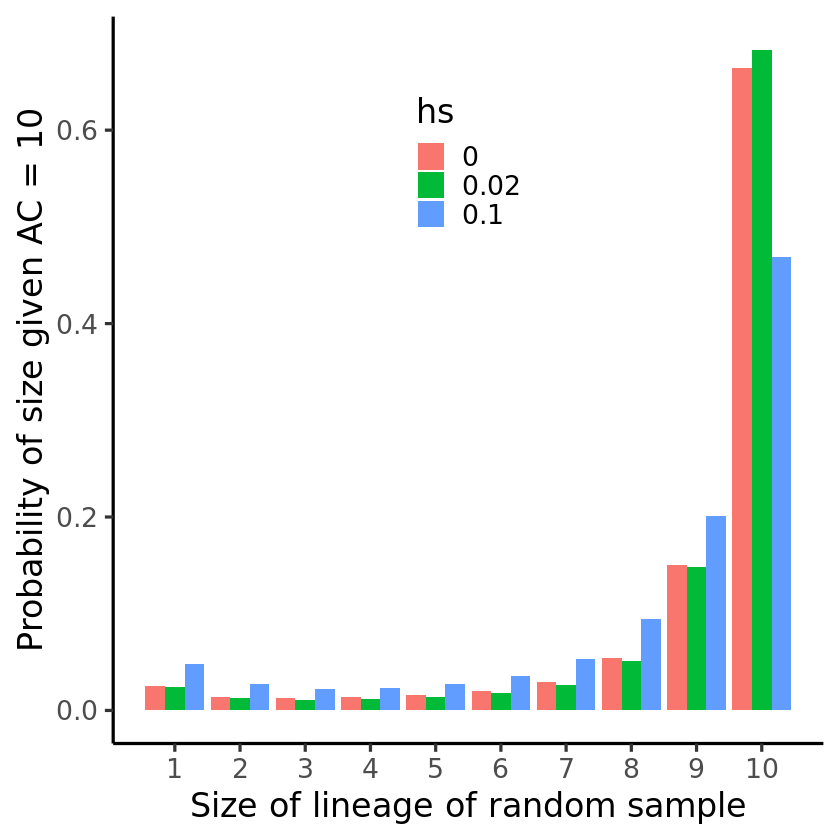

In [253]:
res %>%
    group_by(k) %>%
    mutate(min_emk = emk==min(emk)) %>%
    filter(k==10) %>%
    filter(min_emk|g==min(g)|g==max(g)) %>%
    mutate(psize = pi*i/k*emk) %>%
    ggplot(aes(i,psize)) +
    geom_bar(aes(fill=as.factor(round(g/(4*N0_fit),2))),stat="identity",position="dodge") +
    theme_classic(base_size=20) +
    labs(fill="hs") +
    scale_x_continuous(breaks=1:10) +
    theme(legend.position = c(.5,.8)) +
    xlab("Size of lineage of random sample") +
    ylab("Probability of size given AC = 10")

ggsave("/scratch1/schraibe/rare_alleles/fig/p_lineage_size_size_bias.pdf")

Joining with `by = join_by(g, i)`
`summarise()` has grouped output by 'g', 'db', 'emk'. You can override using
the `.groups` argument.
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”


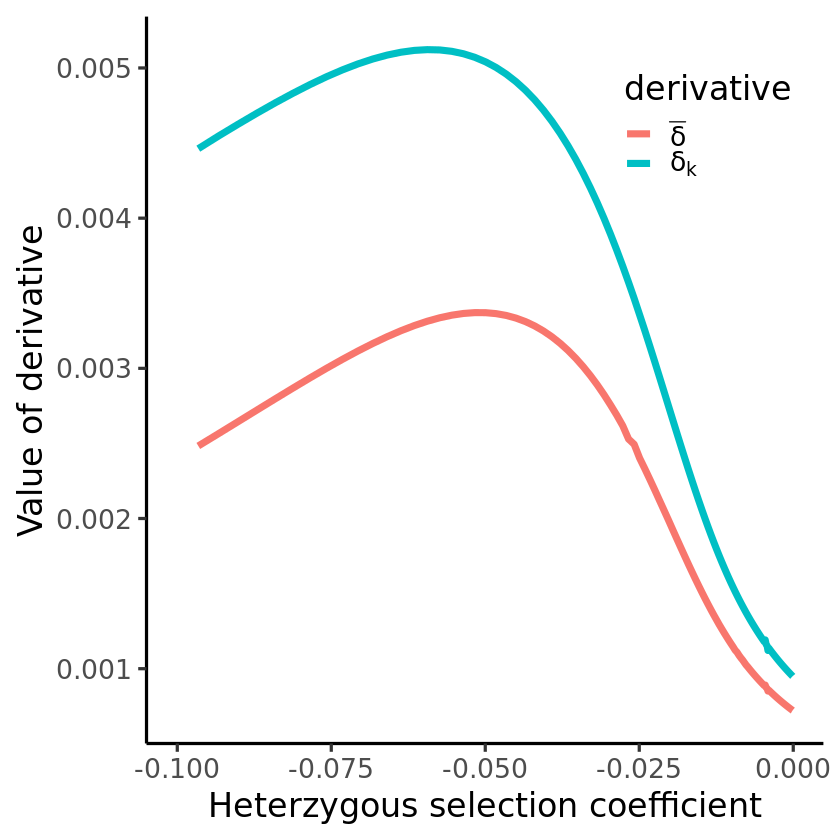

In [254]:
res_d %>%
    group_by(g) %>%
    mutate(bell=bell[AC==10]) %>% #get only the big boy bell that I want? 
    ungroup() %>%
    mutate(log_d = log(d),log_b = log(bell)) %>%
    group_by(AC) %>%
    arrange(AC,g) %>%
    mutate(delta = c(diff(log_d)/diff(g),NA), db=c(diff(log_b)/diff(g),NA)) %>%
    select(g,i=AC,delta,db) %>%
    inner_join(res %>% filter(k==10)) %>%
    group_by(g,db,emk) %>%
    mutate(delta_k = delta[i==k]) %>%
    group_by(g,db,emk,delta_k) %>% 
    summarise(delta_bar = sum(pi*delta)) %>%
    mutate(db_sep = emk*delta_bar)  %>%
    pivot_longer(c(delta_k,delta_bar), names_to="derivative",values_to="value") %>%
    ggplot(aes(-g/(4*N0_fit),-value)) +
    geom_line(aes(color=derivative),size=2) +
    theme_classic(base_size=20) +
    scale_color_discrete(labels=c(expression(bar(delta)),expression(delta[k]))) +
    xlab("Heterzygous selection coefficient") +
    ylab("Value of derivative") +
    theme(legend.position = c(.83,.85))

ggsave("/scratch1/schraibe/rare_alleles/fig/derivatives.pdf")

Joining with `by = join_by(g, i)`
`summarise()` has grouped output by 'g', 'db'. You can override using the
`.groups` argument.
Saving 6.67 x 6.67 in image


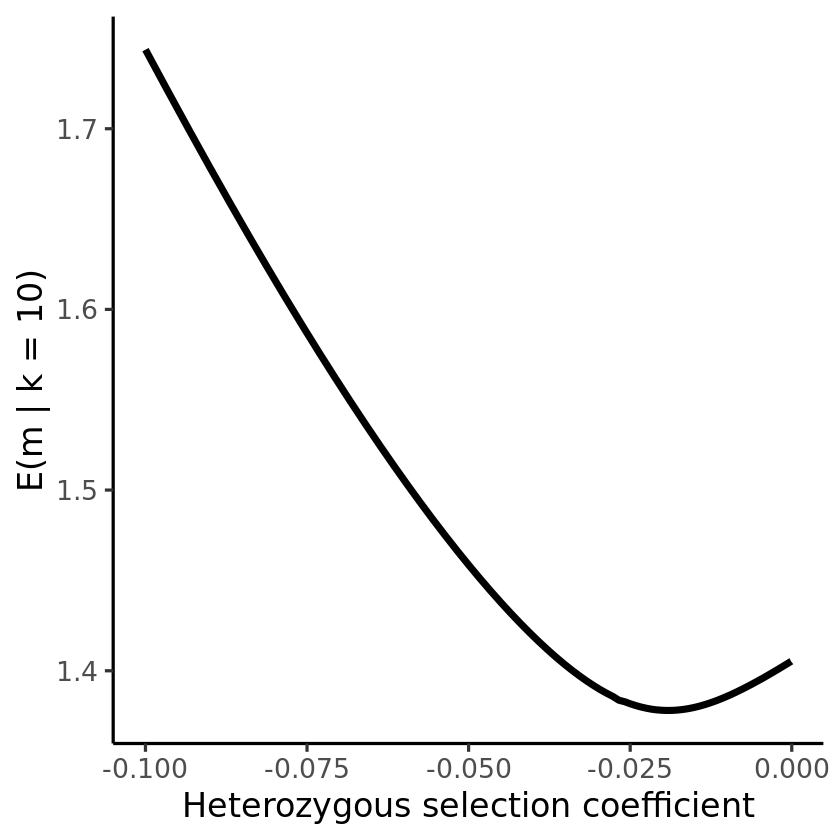

In [255]:
res_d %>%
    group_by(g) %>%
    mutate(bell=bell[AC==10]) %>% #get only the big boy bell that I want? 
    ungroup() %>%
    mutate(log_d = log(d),log_b = log(bell)) %>%
    group_by(AC) %>%
    arrange(AC,g) %>%
    mutate(delta = c(diff(log_d)/diff(g),NA), db=c(diff(log_b)/diff(g),NA)) %>%
    select(g,i=AC,delta,db) %>%
    inner_join(res %>% filter(k==10)) %>%
    group_by(g,db,emk) %>%
    summarise(delta_bar = sum(pi*delta)) %>%
    mutate(db_sep = emk*delta_bar)  %>%
    ggplot(aes(-g/(4*N0_fit),emk)) +
    geom_line(size=2) +
    theme_classic(base_size=20) +
    xlab("Heterozygous selection coefficient") +
    ylab("E(m | k = 10)")

ggsave("/scratch1/schraibe/rare_alleles/fig/Emgk.pdf")

In [23]:
true_mu = c(1e-9,1e-8,1e-7)

In [24]:
true_mu_factor <- as.factor(signif(true_mu, digits = 3))

# Apply the custom formatting function to the levels of the factor
formatted_labels <- lapply(levels(true_mu_factor), function(x) {
  x <- as.numeric(as.character(x))
  format_sci(x)
})

In [32]:
ss = exp(seq(log(1000),log(10000000),len=50))
theta = 4*N0_fit*true_mu
res = tibble()
K = 100
for (j in 1:length(theta)) {
    prob = matrix(nrow=length(ss),ncol=K)
    for (i in 1:length(ss)) {
        d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss[i],g=0,a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
        b = bell_polynomial_tilde_DP(K,theta[j]*d)
        prob[i,] = theta[j]*d/b[2:length(b)]
    }
    cur_tibble = as_tibble(prob) %>% 
        mutate(ss=ss) %>% 
        pivot_longer(1:K,names_to="AC",values_to="prob_single") %>%
        mutate(AC = substring(AC,first=2,last=100000)) %>%
        type_convert() %>%
        mutate(theta=theta[j]) 
    res = bind_rows(res,cur_tibble)
}


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)



Saving 6.67 x 6.67 in image


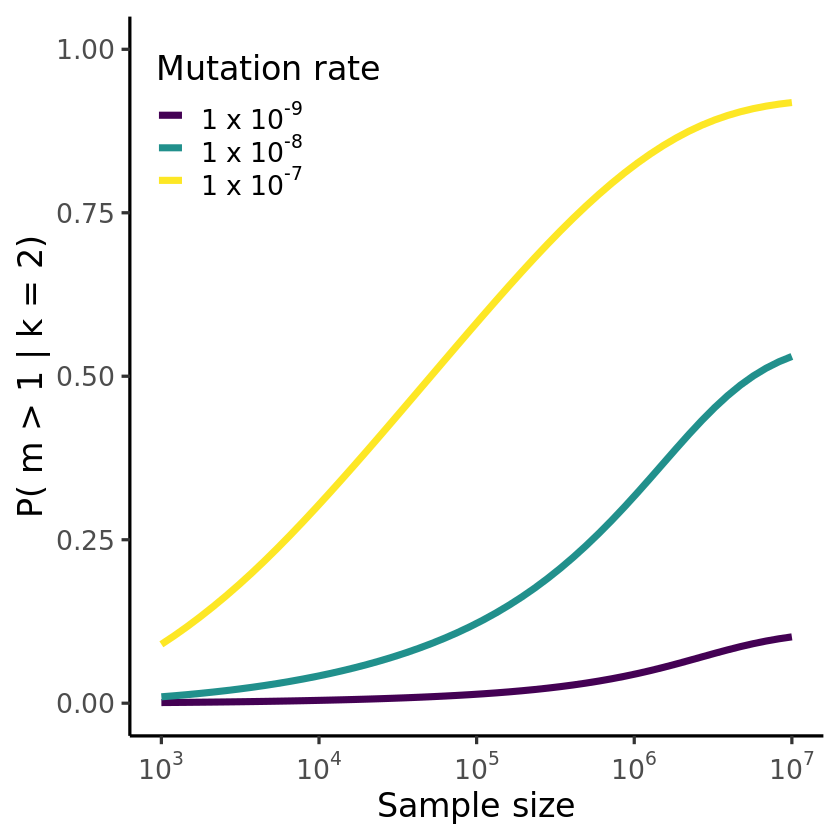

In [33]:
count = 2
res %>% 
    filter(AC==count) %>%
    ggplot(aes(ss,1-prob_single)) +
    geom_line(aes(color=as.factor(theta/(4*14448))),size=2) +
    scale_color_viridis_d(labels=formatted_labels) +
    theme_classic(base_size=20) +
    xlab("Sample size") +
    ylab(paste0("P( m > 1 | k = ", count, ")")) +
    scale_x_log10(labels=label_log()) + 
    labs(color="Mutation rate") + 
    theme(legend.position=c(.2,.85)) +
    ylim(0,1)

ggsave("/scratch1/schraibe/rare_alleles/fig/multiple_k_2.pdf")

Saving 6.67 x 6.67 in image


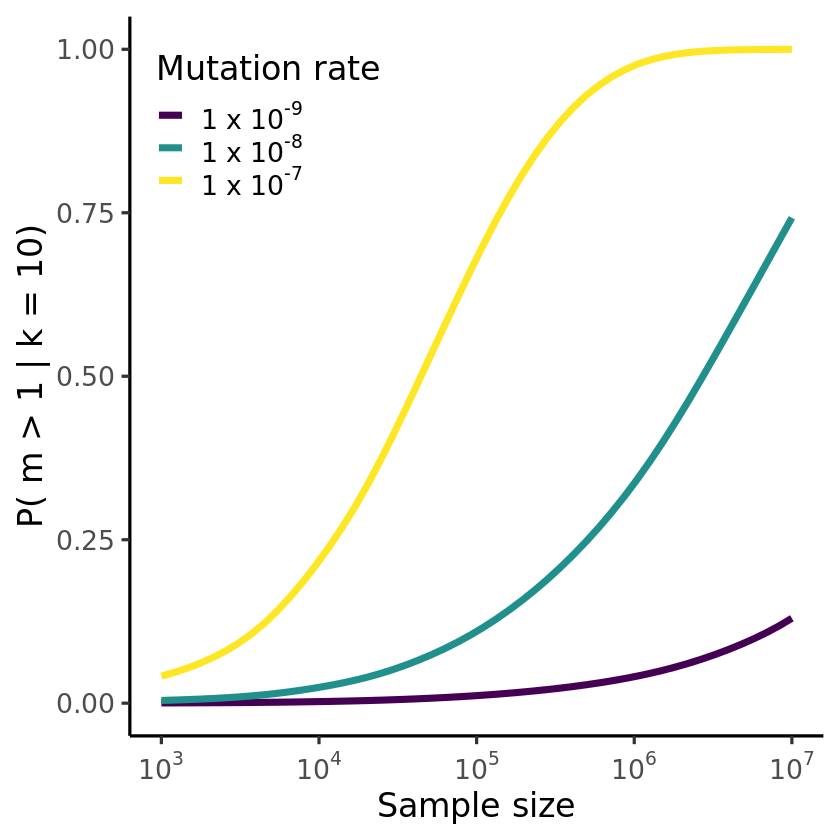

In [34]:
count = 10
res %>% 
    filter(AC==count) %>%
    ggplot(aes(ss,1-prob_single)) +
    geom_line(aes(color=as.factor(theta/(4*14448))),size=2) +
    scale_color_viridis_d(labels=formatted_labels) +
    theme_classic(base_size=20) +
    xlab("Sample size") +
    ylab(paste0("P( m > 1 | k = ", count, ")")) +
    scale_x_log10(labels=label_log()) + 
    labs(color="Mutation rate") + 
    theme(legend.position=c(.2,.85)) +
    ylim(0,1)

ggsave("/scratch1/schraibe/rare_alleles/fig/multiple_k_10.pdf")

In [35]:
theta = 4*N0_fit*c(1e-9,1e-8,1e-7)
res = tibble()
K = 100
for (j in 1:length(theta)) {
    expected_muts = matrix(nrow=length(ss),ncol=K)
    for (i in 1:length(ss)) {
        d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss[i],g=0,a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
        b = bell_polynomial_tilde_DP(K,theta[j]*d)
        for (k in 1:100) {
            cur_b = b[1:(k+1)]
            cur_d = theta[j]*d[1:k]
            expected_muts[i,k] = sum(cur_d*rev(cur_b[1:k]))/b[k+1]
        }
    }
    cur_tibble = as_tibble(expected_muts) %>% 
        mutate(ss=ss) %>% 
        pivot_longer(1:K,names_to="AC",values_to="expected_muts") %>%
        mutate(AC = substring(AC,first=2,last=100000)) %>%
        type_convert() %>%
        mutate(theta=theta[j]) 
    res = bind_rows(res,cur_tibble)
}


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)



Saving 6.67 x 6.67 in image


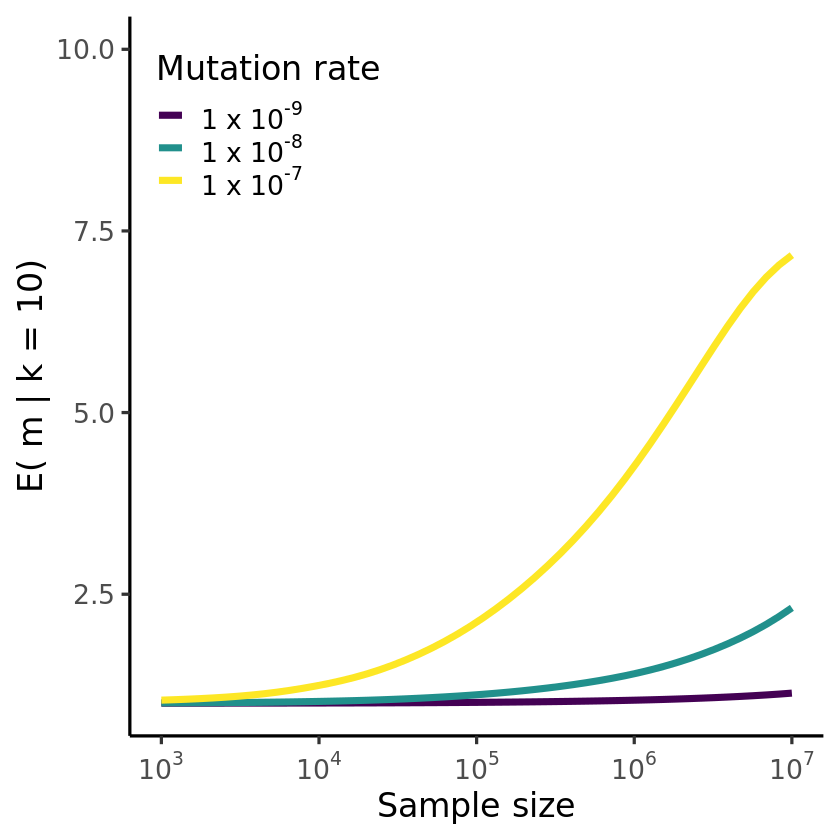

In [36]:
count = 10
res %>% 
    filter(AC==count) %>%
    ggplot(aes(ss,expected_muts)) +
    geom_line(aes(color=as.factor(theta/(4*14448))),size=2) +
    scale_color_viridis_d(labels=formatted_labels) +
    theme_classic(base_size=20) +
    xlab("Sample size") +
    ylab(paste0("E( m | k = ", count, ")")) +
    scale_x_log10(labels=label_log()) + 
    labs(color="Mutation rate") +
    theme(legend.position=c(.2,.85)) +
    ylim(c(1,count))

ggsave("/scratch1/schraibe/rare_alleles/fig/Em_k_2.pdf")

Saving 6.67 x 6.67 in image


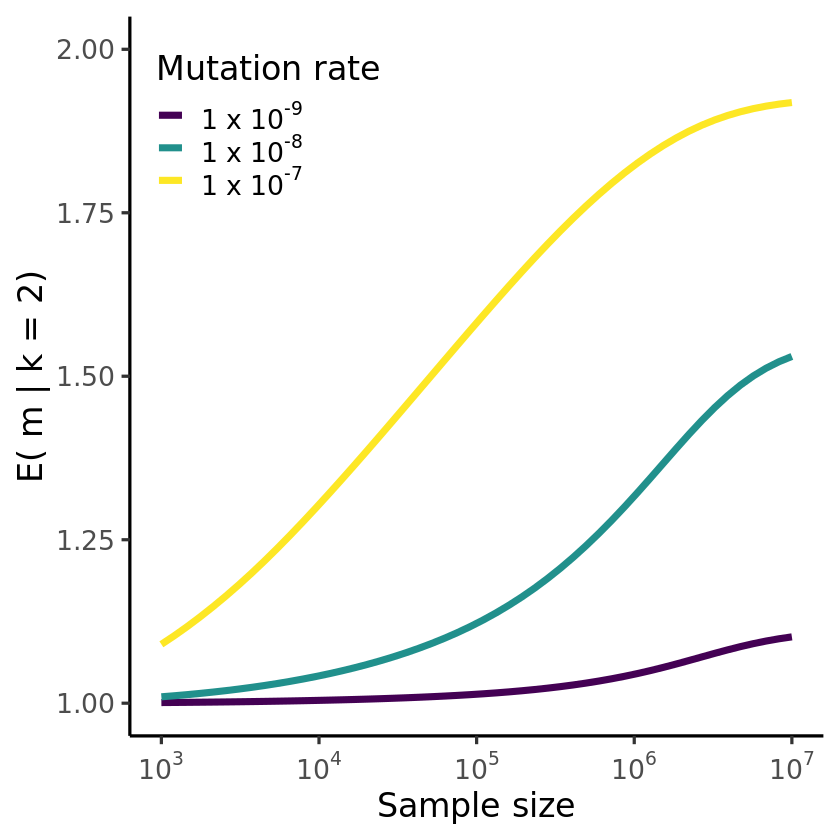

In [37]:
count = 2
res %>% 
    filter(AC==count) %>%
    ggplot(aes(ss,expected_muts)) +
    geom_line(aes(color=as.factor(theta/(4*14448))),size=2) +
    scale_color_viridis_d(labels=formatted_labels) +
    theme_classic(base_size=20) +
    xlab("Sample size") +
    ylab(paste0("E( m | k = ", count, ")")) +
    scale_x_log10(labels=label_log()) + 
    labs(color="Mutation rate") +
    theme(legend.position=c(.2,.85)) +
    ylim(1,count)

ggsave("/scratch1/schraibe/rare_alleles/fig/Em_k_10.pdf")

In [23]:
true_mu = c(1e-9,1e-8,1e-7)

In [24]:
true_mu_factor <- as.factor(signif(true_mu, digits = 3))

# Apply the custom formatting function to the levels of the factor
formatted_labels <- lapply(levels(true_mu_factor), function(x) {
  x <- as.numeric(as.character(x))
  format_sci(x)
})

In [25]:
# ss = exp(seq(log(1000),log(20000000),len=50))
ss = c(10000,100000,1000000,10000000)
theta = 4*N0_fit*true_mu
# s = -c(.0001,.001,.01,.1)
s = -exp(seq(log(.0001),log(.5),len=50))
gamma = 4*N0_fit*s

res = tibble()

for (i in 1:length(ss)) {
    for (j in 1:length(gamma)) {
        ei = exp_integral(s=max(T_fit_diffusion),theta=1,n=ss[i],g=gamma[j],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion)
        p0 = exp(-theta*ei)
        cur_res = tibble(ss = ss[i], gamma = gamma[j], theta = theta,prob_seen=1-p0)

        res = bind_rows(res,cur_res)
    }
}

In [26]:
format_sci_just_exp <- function(x) {
  exponent <- floor(log10(abs(x)))
  base <- signif(x / 10^exponent, digits = 3)
  bquote(10^.(exponent))
}

In [27]:
formatted_labels <- lapply(levels(as.factor(ss)), function(x) {
  x <- as.numeric(as.character(x))
  format_sci_just_exp(x)
})

Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


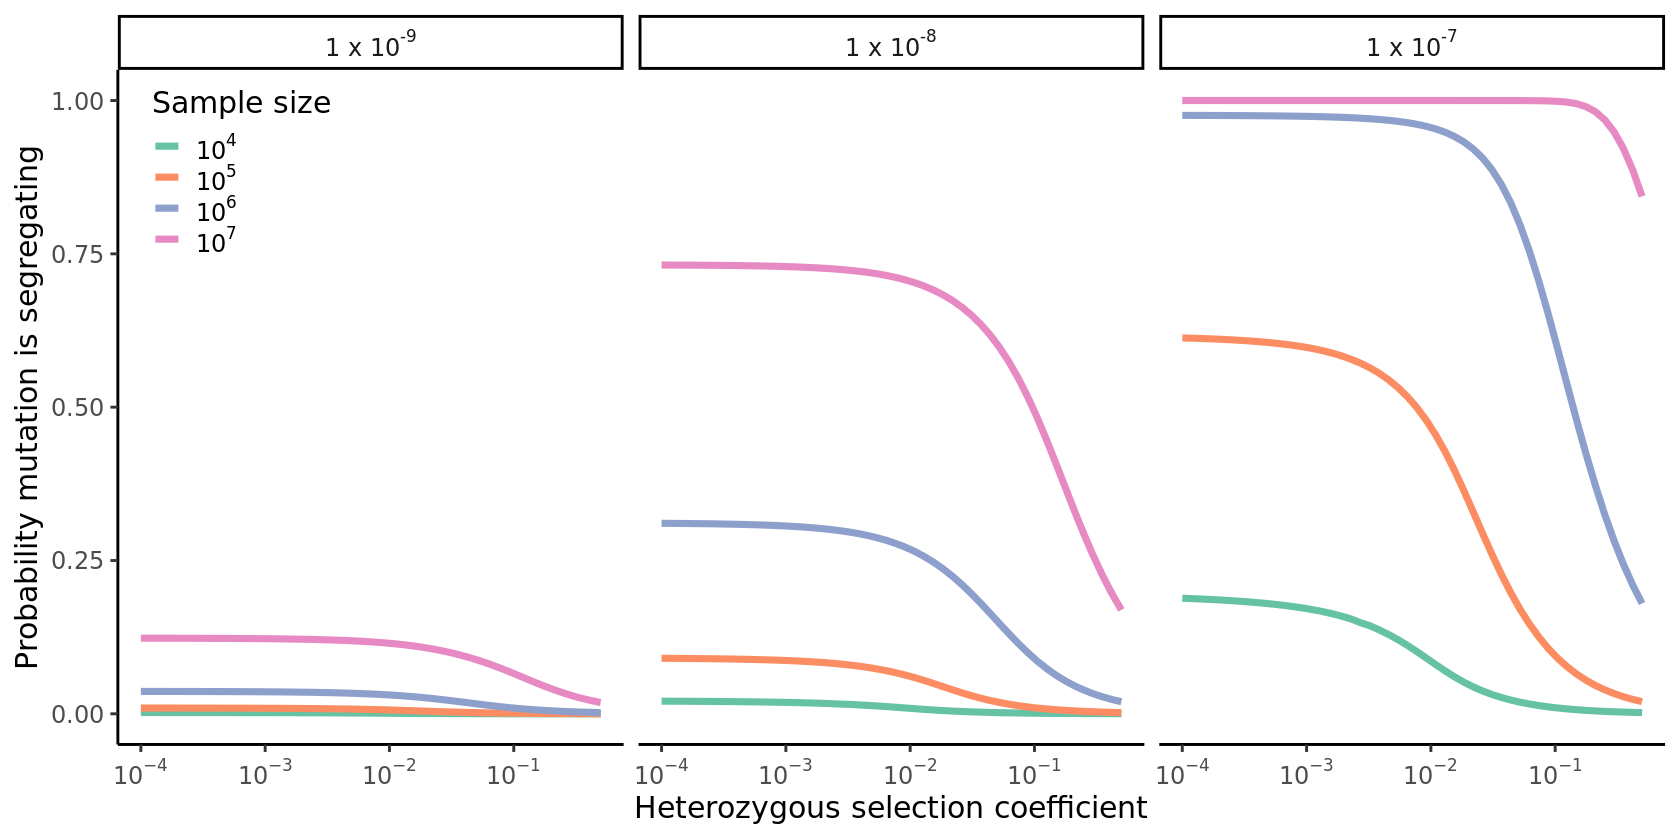

In [28]:
options(repr.plot.width=14, repr.plot.height=7)

res %>%
    ggplot(aes(-gamma/(4*N0_fit),prob_seen)) +
    geom_line(aes(color=as.factor(ss)),linewidth=2) +
    facet_wrap(~theta/(4*N0_fit),labeller=custom_labeller) +
    scale_x_log10(label=label_log()) +
    theme_classic(base_size=18) +
    xlab("Heterozygous selection coefficient") +
    ylab("Probability mutation is segregating") +
    theme(legend.position = c(.08,.85),legend.background = element_rect(fill = NA, color = NA)) +
    labs(color="Sample size") +
    scale_color_brewer(palette="Set2",labels=formatted_labels) 

ggsave("/scratch1/schraibe/rare_alleles/fig/observed_selection.pdf",width=14,height=7)

options(repr.plot.width=7, repr.plot.height=7)

In [35]:
true_mu = c(1e-9,1e-8,1e-7)
# true_mu = exp(seq(log(1e-9),log(1e-7),len=50))

In [36]:
true_mu_factor <- as.factor(signif(true_mu, digits = 3))

# Apply the custom formatting function to the levels of the factor
formatted_labels <- lapply(levels(true_mu_factor), function(x) {
  x <- as.numeric(as.character(x))
  format_sci(x)
})

In [26]:
3

[1] 3

In [ ]:
# ss = exp(seq(log(1000),log(20000000),len=50))
# ss = 10000000
ss = c(10000,100000,1000000,10000000)
K = c(1500, 1500,5000,50000)
theta = 4*N0_fit*true_mu
# s = -c(.0001,.001,.01,.1)
s = unique(-exp(c(seq(log(.0001),log(.001),len=10),seq(log(.001),log(.01),len=50),seq(log(.01),log(.1),len=75),seq(log(.1),log(.5),len=50))))
gamma = 4*N0_fit*s

res = tibble()


for (k in 1:length(ss)) {
    message(ss[k])
    for (j in 1:length(gamma)) {
        ei = exp_integral(s=max(T_fit_diffusion),theta=1,n=ss[k],g=gamma[j],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion)
        d = unlist(mclapply(1:K[k],d_tilde,s=max(T_fit_diffusion),theta=1,n=ss[k],g=gamma[j],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=30))
        for (i in 1:length(theta)) {
            cur_p = p_d(d,ei,theta[i])
            cur_p = cur_p[2:length(cur_p)]/(1-cur_p[1]) #condition on segregating
            cdf = cumsum(cur_p)
            cutoff = findInterval(.99,cdf)
            cur_res = tibble(ss = ss[k], gamma = gamma[j], theta = theta[i],kstar = cutoff)
    
            res = bind_rows(res,cur_res)
        }
    }
}

10000

1e+05



In [30]:
formatted_labels <- lapply(levels(as.factor(ss)), function(x) {
  x <- as.numeric(as.character(x))
  format_sci_just_exp(x)
})

In [50]:
#remove one point in the middle that is obviously numerical error
res %>%
    mutate(s = gamma/(4*N0_fit)) %>%
    filter(ss==1e4) %>%
    filter(s > -1e-2, s < -1e-3) %>%
    filter(round(s,9)==-0.002682696)

ss,gamma,theta,kstar,s
<dbl>,<dbl>,<dbl>,<int>,<dbl>
10000,-96.21636,3.586555e-05,17,-0.002682696
10000,-96.21636,3.586555e-04,17,-0.002682696
10000,-96.21636,3.586555e-03,18,-0.002682696


In [55]:
res = res %>% mutate(s = gamma/(4*N0_fit)) %>%
    filter(round(s,9)!= (-0.002682696))

Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”


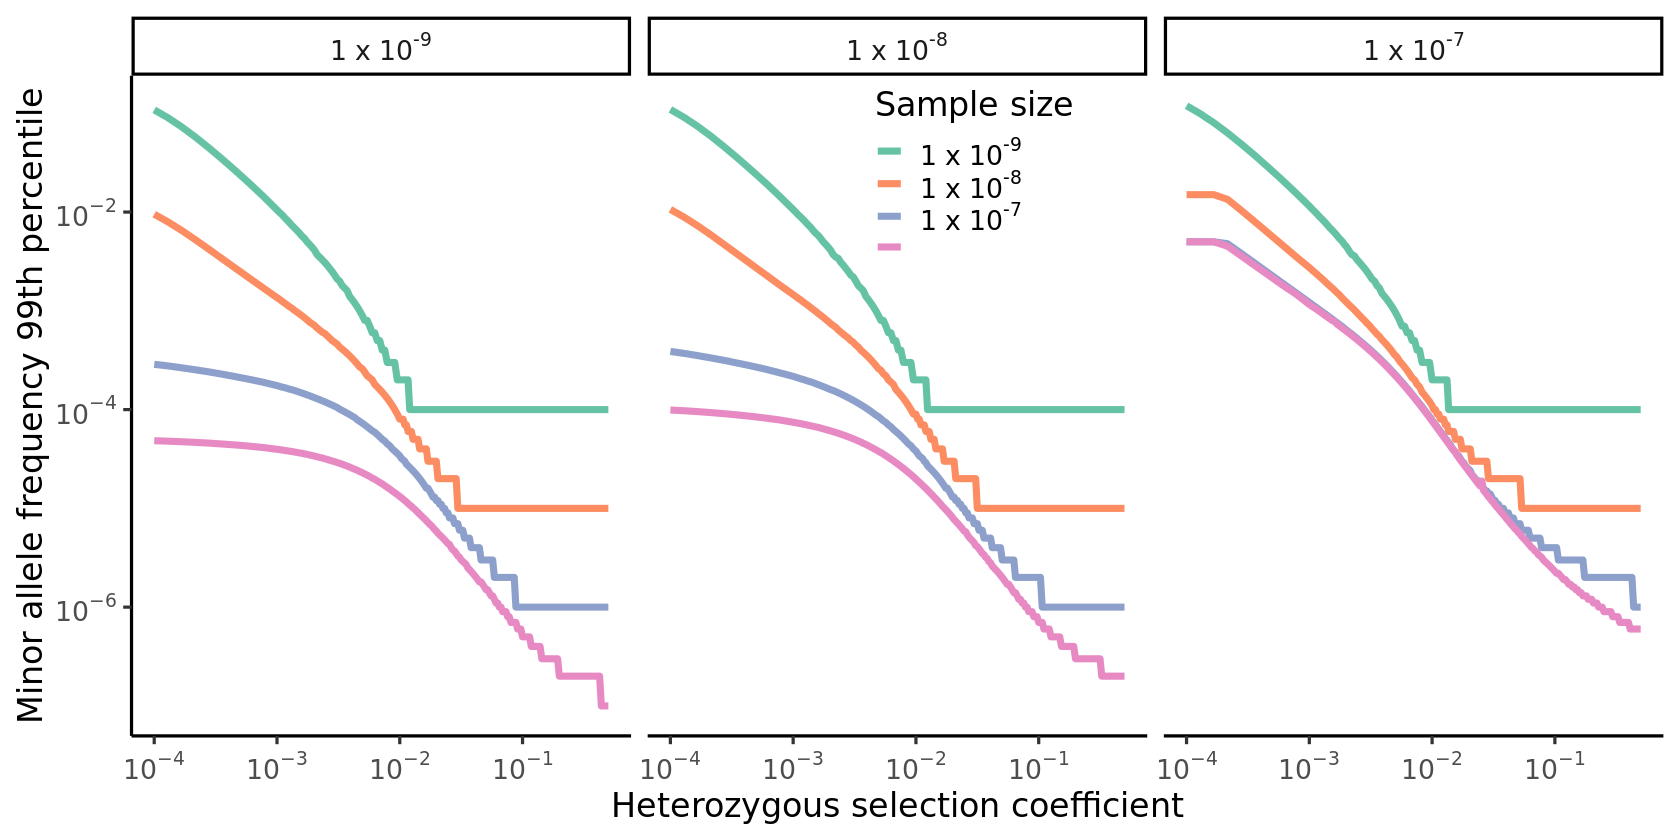

In [56]:
options(repr.plot.width=14, repr.plot.height=7)

res %>% 
    mutate(kstar = ifelse(kstar == 0, 1, kstar)) %>% #make sure this makes sense
    ggplot(aes(-gamma/(4*N0_fit),kstar/ss)) +
    geom_line(aes(color=as.factor(ss)),linewidth=2) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) + 
    theme_classic(base_size=20) +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    labs(color="Sample size") +
    theme(legend.position = c(.55,.85),legend.background = element_rect(fill = NA, color = NA)) +
    xlab("Heterozygous selection coefficient") +
    ylab("Minor allele frequency 99th percentile") +
    facet_wrap(~theta/(4*N0_fit),labeller=custom_labeller)

ggsave("/scratch1/schraibe/rare_alleles/fig/selection_allele_frequency.pdf",width=14,height=7)

options(repr.plot.width=7, repr.plot.height=7)

In [30]:
ss = 1000000
theta = 4*N0_fit*true_mu
res = tibble()
# s = -exp(seq(log(.0001),log(.5),len=50))
s = -c(.0001,.001,.01,.1)
gamma = 4*N0_fit*s
K = 450

res= tibble()
for (i in 1:length(theta)) {
    prob = matrix(nrow=length(gamma),ncol=K)
    for (j in 1:length(gamma)) {
        d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=gamma[j],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=20))
        b = bell_polynomial_tilde_DP(K,theta[i]*d)
        prob[j,] = theta[i]*d/b[2:length(b)]
    }
    cur_tibble = as_tibble(prob) %>%
        mutate(gamma=gamma) %>%
        pivot_longer(1:K,names_to="AC",values_to="prob_single") %>%
        mutate(AC = substring(AC,first=2,last=100000)) %>%
        type_convert() %>%
        mutate(theta = theta[i])
    res = bind_rows(res,cur_tibble)
}


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)



In [31]:
format_sci_just_exp <- function(x) {
  exponent <- floor(log10(abs(x)))
  bquote(10^.(exponent))
}

In [32]:
formatted_labels <- lapply(s, function(x) {
  format_sci_just_exp(x)
})

Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”


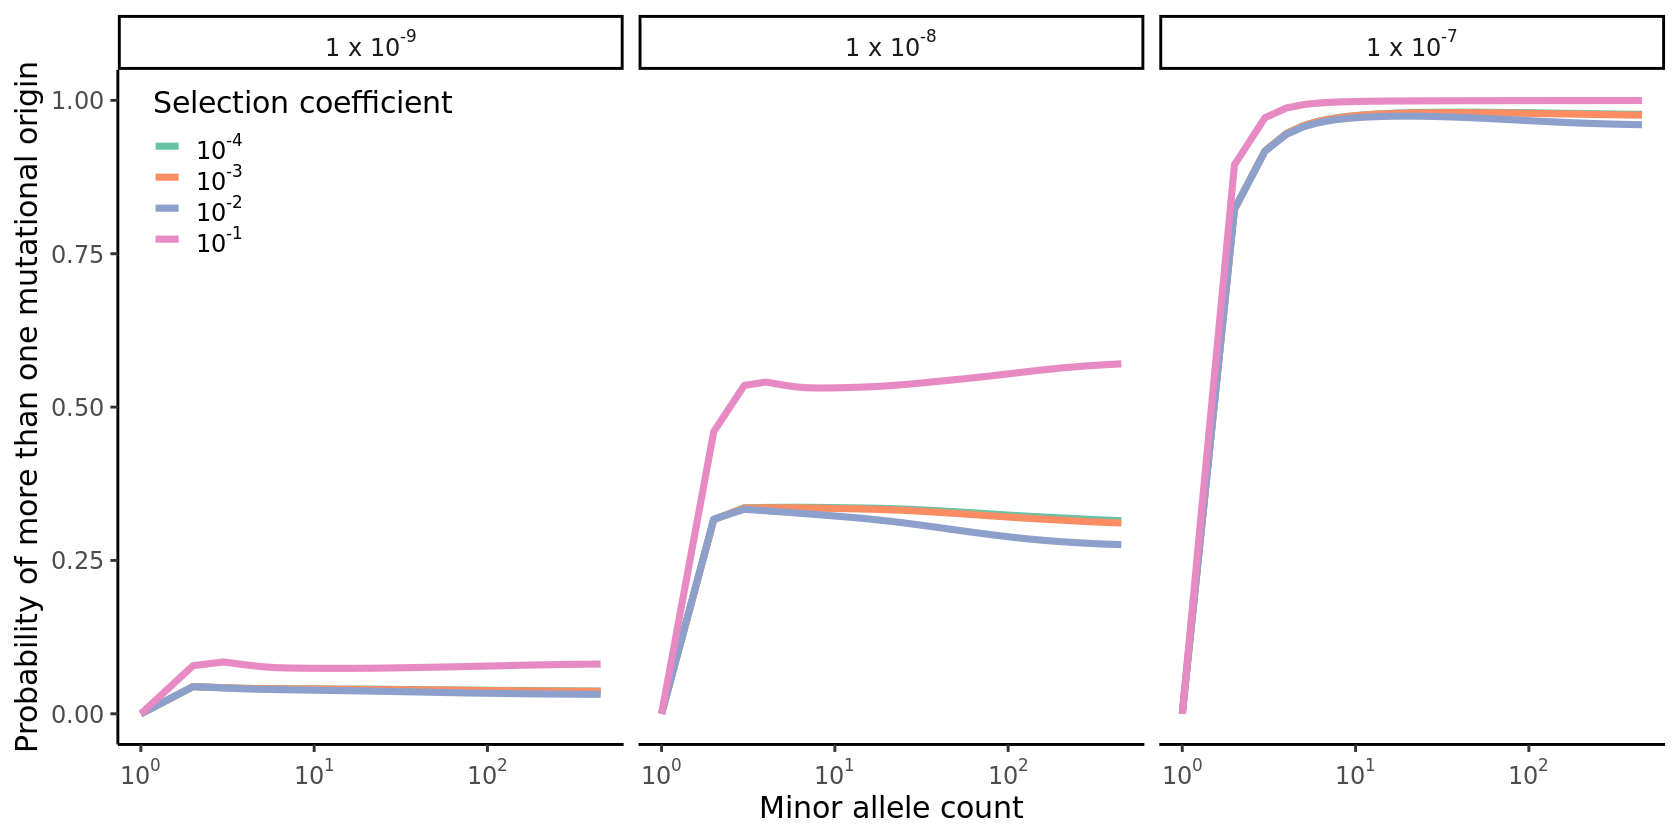

In [33]:
options(repr.plot.width=14, repr.plot.height=7)

res %>% 
    group_by(gamma,theta) %>%
    ggplot(aes(AC,1-prob_single)) +
    geom_line(aes(color=as.factor(-gamma/(4*N0_fit))),linewidth=2) +
    facet_wrap(~theta/(4*N0_fit),labeller=custom_labeller) +   
    scale_x_log10(label=label_log()) +
    # scale_y_log10(label=label_log()) +
    theme_classic(base_size=18) +
    theme(legend.position = c(.12,.85),legend.background = element_rect(fill = NA, color = NA)) +
    labs(color="Selection coefficient") +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    xlab("Minor allele count") +
    ylab("Probability of more than one mutational origin")

ggsave("/scratch1/schraibe/rare_alleles/fig/prob_multiple_selection.pdf",width=14,height=7)

options(repr.plot.width=7, repr.plot.height=7)


In [36]:
theta = 4*N0_fit*c(1e-9,1e-8,1e-7)
res = tibble()
K = 450
ss = 1000000
s = -c(.0001,.001,.01,.1)
gamma = 4*N0_fit*s
for (j in 1:length(theta)) {
    expected_muts = matrix(nrow=length(gamma),ncol=K)
    for (i in 1:length(gamma)) {
        d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=gamma[i],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
        b = bell_polynomial_tilde_DP(K,theta[j]*d)
        for (k in 1:K) {
            cur_b = b[1:(k+1)]
            cur_d = theta[j]*d[1:k]
            expected_muts[i,k] = sum(cur_d*rev(cur_b[1:k]))/b[k+1]
        }
    }
    cur_tibble = as_tibble(expected_muts) %>% 
        mutate(gamma=gamma) %>% 
        pivot_longer(1:K,names_to="AC",values_to="expected_muts") %>%
        mutate(AC = substring(AC,first=2,last=100000)) %>%
        type_convert() %>%
        mutate(theta=theta[j]) 
    res = bind_rows(res,cur_tibble)
}


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)



Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Saving 6.67 x 6.67 in image


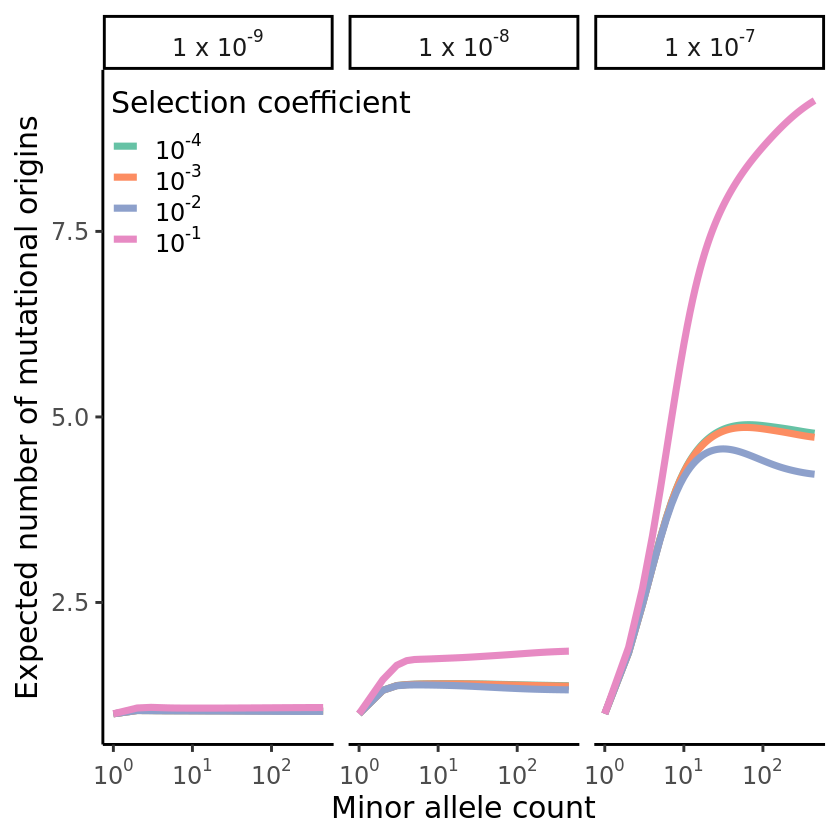

In [37]:
res %>% 
    # filter(abs(gamma)<.1*4*14448) %>% 
    group_by(gamma,theta) %>%
    ggplot(aes(AC,expected_muts)) +
    geom_line(aes(color=as.factor(-gamma/(4*N0_fit))),linewidth=2) +
    facet_wrap(~theta/(4*N0_fit),labeller=custom_labeller) +   
    scale_x_log10(label=label_log()) +
    # scale_y_log10(label=label_log()) +
    theme_classic(base_size=18) +
    theme(legend.position = c(.22,.85),legend.background = element_rect(fill = NA, color = NA)) +
    labs(color="Selection coefficient") +
    scale_color_brewer(palette="Set2",labels=formatted_labels) +
    xlab("Minor allele count") +
    ylab("Expected number of mutational origins")

ggsave("/scratch1/schraibe/rare_alleles/fig/number_origins_selection.pdf")

In [38]:
mu = exp(seq(log(5e-10),log(5e-7),len=100))
inf_sites = p_inf_sites(1000,max(T_fit_diffusion),theta=1,n=1000000,g=0,Ne_fit_diffusion,R_fit,T_fit_diffusion,nc=20)

In [39]:
inf_sites_norm = normalize_vec(inf_sites)

In [40]:
TV = c()
KL = c()
for (i in 1:length(mu)) {
    p = p_mc(1000,max(T_fit_diffusion),theta=4*N0_fit*mu[i],n=1000000,g=0,Ne_fit_diffusion,R_fit,T_fit_diffusion,nc=20)
    p_norm = normalize_vec(p[2:length(p)])
    cur_TV = 1/2*sum(abs(inf_sites_norm-p_norm))
    TV = c(TV,cur_TV)
    cur_KL = sum(p_norm*log(p_norm/inf_sites_norm))
    KL = c(KL,cur_KL)
}

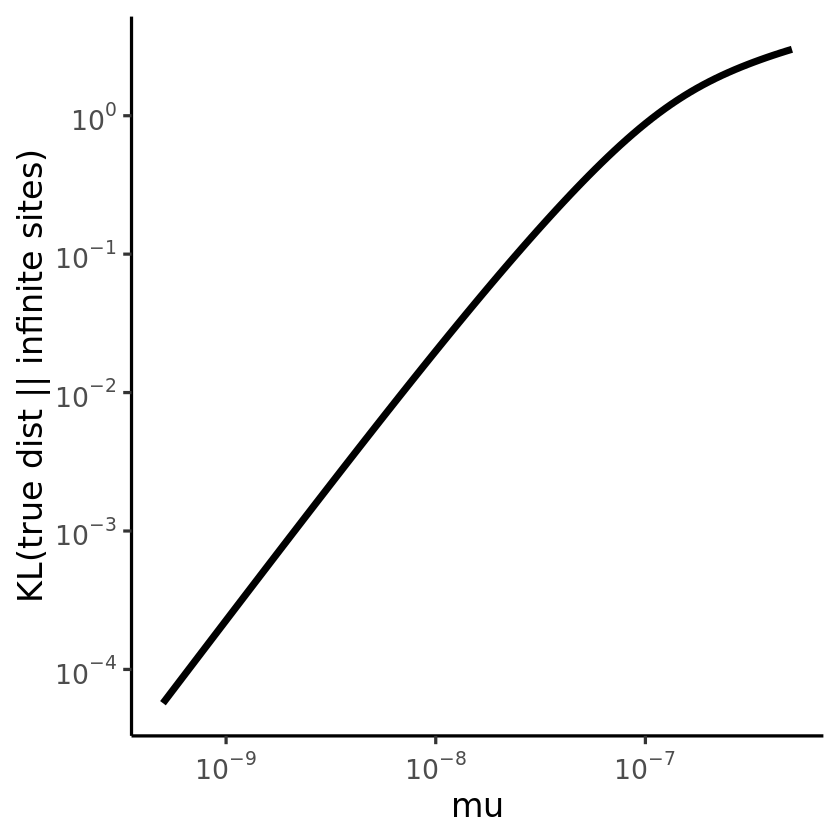

In [41]:
tibble(mu = mu, KL = KL) %>%
    ggplot(aes(mu,KL)) +
    geom_line(linewidth=2) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    theme_classic(base_size=20) +
    ylab("KL(true dist || infinite sites)")

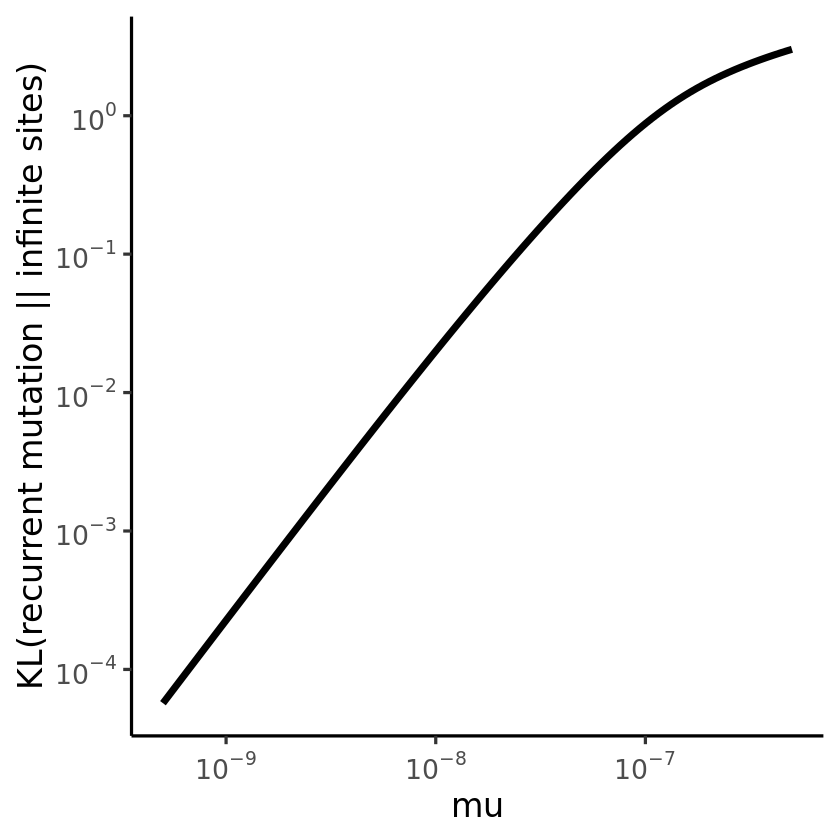

In [42]:
tibble(mu = mu, KL = KL) %>%
    ggplot(aes(mu,KL)) +
    geom_line(linewidth=2) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    theme_classic(base_size=20) +
    ylab("KL(recurrent mutation || infinite sites)")

In [37]:
mean_theta = (mutation_rates_dist %>% pull(mean_theta))
sd_theta = (mutation_rates_dist %>% pull(sd_theta))
ref = mutation_rates_dist %>% pull(ref_context)
alt = mutation_rates_dist %>% pull(alt_context)
meth = mutation_rates_dist %>% pull(methylation_level)
alpha = mean_theta^2/sd_theta^2
beta = mean_theta/sd_theta^2
num_sites = mutation_rates_dist %>% pull(n)

cur_p_inf = p_inf_sites(1000,max(T_fit_diffusion),theta=1,n=1000000,g=0,Ne_fit_diffusion,R_fit,T_fit_diffusion,nc=20)
cur_p_inf_norm = normalize_vec(cur_p_inf) #remember: no 0 class

In [38]:
like_inf_sites = c()
like_recurrent = c()
goodness_of_fit_all = c()
goodness_of_fit_no_zero = c()
KL = c()
for (i in 1:length(mean_theta)) {
    message(i)
    if (is.na(meth[i])) {
        counts = SFS_to_analyze %>% arrange(AC) %>% filter(ref_context==ref[i],alt_context==alt[i],is.na(methylation_level)) %>% pull(n)
    } else {
        counts = SFS_to_analyze %>% arrange(AC) %>% filter(ref_context==ref[i],alt_context==alt[i],methylation_level==meth[i]) %>% pull(n)
    }
    
    cur_p_gamma = p_gamma_mc(1000,max(T_fit_diffusion),n=1000000,g=0,Ne_fit_diffusion,R_fit,T_fit_diffusion,alpha = alpha[i], beta = beta[i],nc=20)

    cur_p_gamma_norm = normalize_vec(cur_p_gamma)

    expected = cur_p_gamma_norm*sum(counts)
    chisquared_all = sum(((counts-expected)^2/expected))

    cur_p_gamma_norm = normalize_vec(cur_p_gamma[2:length(cur_p_gamma)]) #get rid of zero class
    counts = counts[2:length(counts)]

    expected = cur_p_gamma_norm*sum(counts)
    chisquared_no_zero = sum((counts-expected)^2/expected)

    goodness_of_fit_all = c(goodness_of_fit_all,chisquared_all)
    goodness_of_fit_no_zero = c(goodness_of_fit_no_zero,chisquared_no_zero)

    cur_KL = sum(cur_p_gamma_norm*log(cur_p_gamma_norm/cur_p_inf_norm))
    KL = c(KL,cur_KL)
    
    like_inf = sum(counts*log(cur_p_inf_norm))
    like_gamma = sum(counts*log(cur_p_gamma_norm))

    like_inf_sites = c(like_inf_sites,like_inf)
    like_recurrent = c(like_recurrent,like_gamma)
                                                 
    
}

1

2

3

4

5

6

7

8

9

10

11

12

13

14

15

16

17

18

19

20

21

22

23

24

25

26

27

28

29

30

31

32

33

34

35

36

37

38

39

40

41

42

43

44

45

46

47

48

49

50

51

52

53

54

55

56

57

58

59

60

61

62

63

64

65

66

67

68

69

70

71

72

73

74

75

76

77

78

79

80

81

82

83

84

85

86

87

88

89

90

91

92

93

94

95

96

97

98

99

100

101

102

103

104

105

106

107

108

109

110

111

112

113

114

115

116

117

118

119

120

121

122

123

124

125

126

127

128

129

130

131

132

133

134

135

136

137

138

139

140

141

142

143

144



In [39]:
like_tibble = tibble(ref_context=ref,alt_context=alt, methylation_level = meth, mu = mean_theta/(4*N0_fit), num_sites = num_sites, like_recurrent = like_recurrent, like_inf_sites = like_inf_sites)

Warning message in scale_y_log10(label = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_y_log10(label = label_log()):
“log-10 transformation introduced infinite values.”


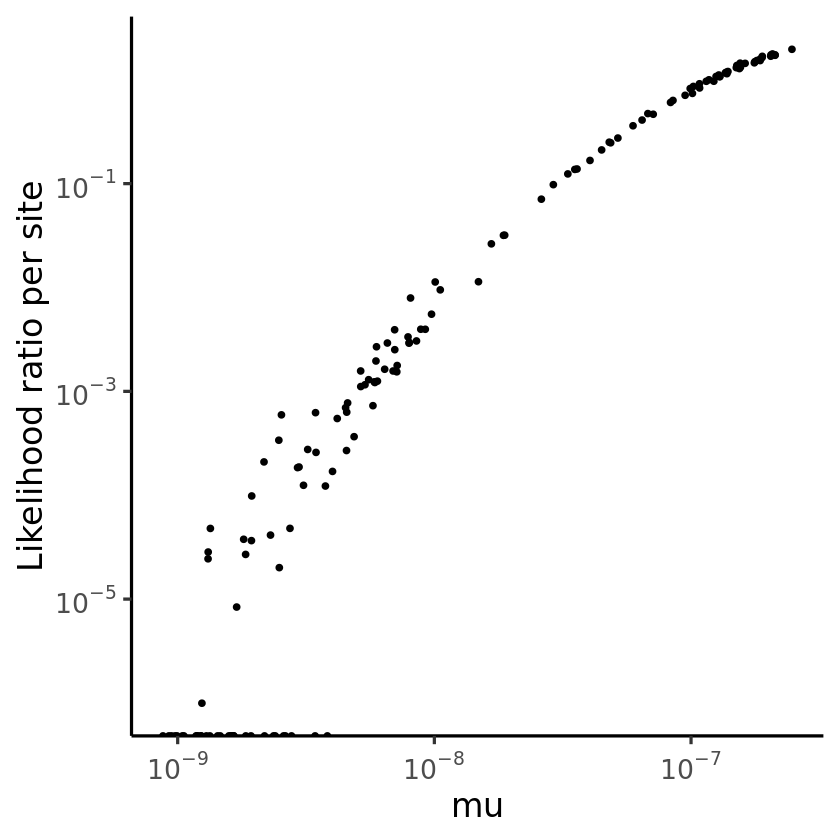

In [40]:
like_tibble %>%
    mutate(like_ratio_per_site = (like_recurrent-like_inf_sites)/num_sites) %>%
    mutate(like_ratio_per_site = ifelse(like_ratio_per_site<0,0,like_ratio_per_site)) %>% 
    ggplot(aes(mu,like_ratio_per_site)) +
    geom_point() +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    theme_classic(base_size = 20) +
    xlab("mu") +
    ylab("Likelihood ratio per site")

ggsave("/scratch1/schraibe/rare_alleles/fig/like_ratio_per_site.pdf")

In [26]:
error_rates_func = sequencing_error_fit(SFS_to_analyze,mutation_rates,K,AN,Ne_fit_diffusion,R_fit,T_fit_diffusion,nc=20)

Joining with `by = join_by(ref_context, alt_context, methylation_level)`


In [27]:
supp_table_error = inner_join(mutation_rates,error_rates_func,by=c("ref_context","alt_context","methylation_level"),suffix=c("_no_error","_error")) %>%
    mutate(LR = 2*(LL_no_error-LL_error)) %>%
    arrange(desc(LR)) %>%
    mutate(p_val = pchisq(LR,df=1,lower.tail=FALSE)) %>%
    mutate(p_adj = p.adjust(p_val,method="BH")) %>%
    replace_na(list(methylation_level=0))

In [84]:
supp_table_error %>% write_tsv("/scratch1/schraibe/rare_alleles/fig/supp_table_error.tsv")

Saving 6.67 x 6.67 in image


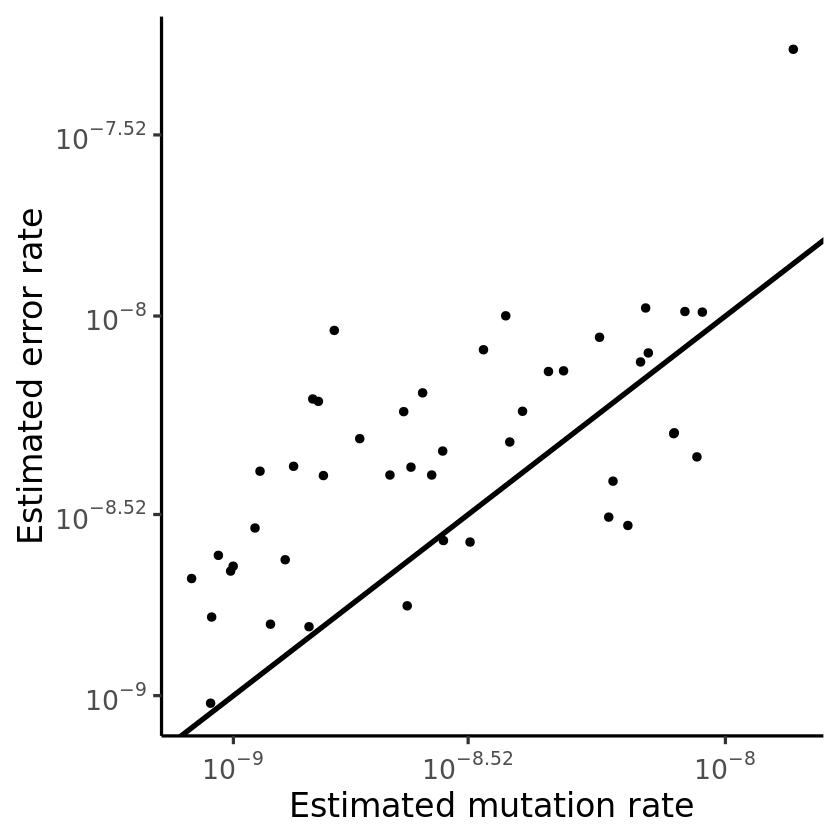

In [28]:
supp_table_error %>%
    filter(p_adj<.1) %>%
    # filter(error< 10^(-7.5)) %>%
    ggplot(aes(theta_error/(4*N0_fit),error)) +
    geom_point(size=2) +
    scale_x_log10(label=label_log()) +
    scale_y_log10(label=label_log()) +
    theme_classic(base_size = 20) +
    xlab("Estimated mutation rate") +
    ylab("Estimated error rate") +
    geom_abline(slope=1,linewidth=1.5) #+
    # geom_smooth(method="lm",se=FALSE)

ggsave("/scratch1/schraibe/rare_alleles/fig/error_rate_mutation_rate.pdf")

Saving 6.67 x 6.67 in image


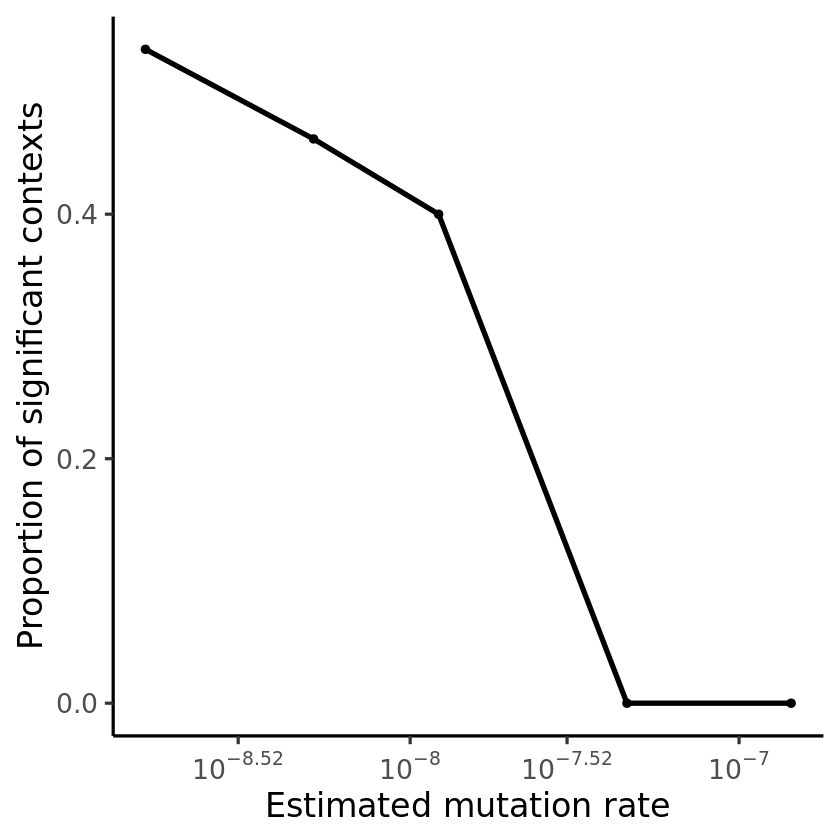

In [81]:
supp_table_error %>%
    mutate(bin=cut.default(log(theta_error),breaks=5)) %>%
    group_by(bin) %>%
    summarise(mean_rate = mean(theta_error), frac_sig = mean(p_adj<.1)) %>%
    ggplot(aes(mean_rate/(4*N0_fit),frac_sig)) +
    geom_line(linewidth=1.5) +
    geom_point(size=2) +
    scale_x_log10(labels=label_log()) +
    theme_classic(base_size = 20) +
    xlab("Estimated mutation rate") +
    ylab("Proportion of significant contexts")

ggsave("/scratch1/schraibe/rare_alleles/fig/significant_error_rate.pdf")

Saving 6.67 x 6.67 in image


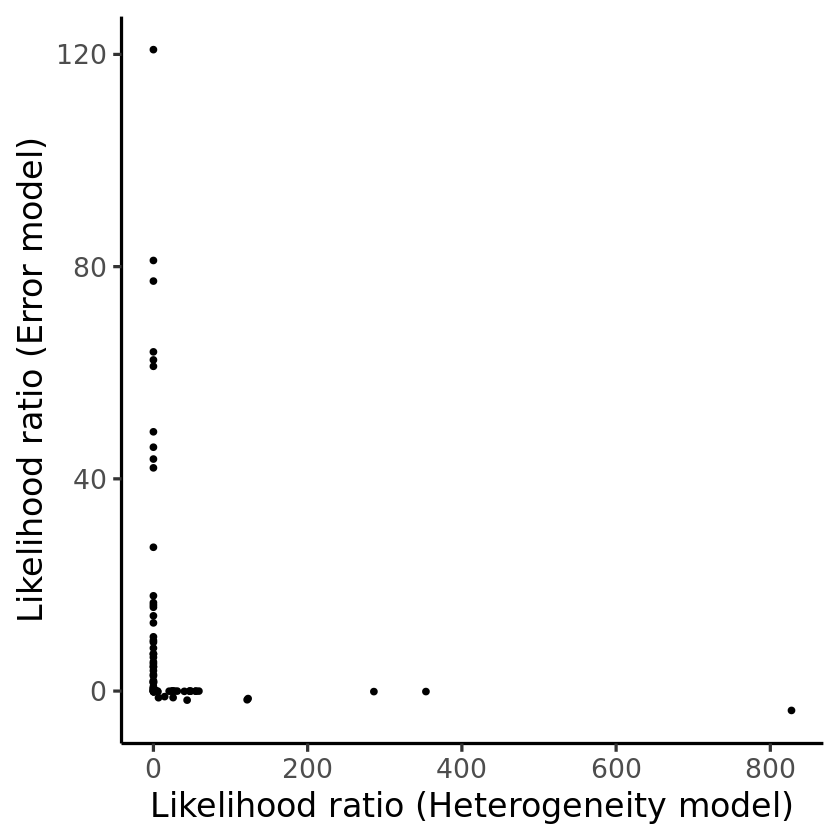

In [83]:
supp_table_mut %>% 
    select(ref_context,alt_context,methylation_level, LR,p_adj) %>% 
    inner_join( 
        supp_table_error %>%
            select(ref_context,alt_context,methylation_level,LR,p_adj),
        by=c("ref_context","alt_context","methylation_level"),
        suffix=c("_heterogeneity","_error")
    ) %>%
    ggplot(aes(LR_heterogeneity,LR_error)) +
    geom_point() +
    theme_classic(base_size=20) +
    xlab("Likelihood ratio (Heterogeneity model)") +
    ylab("Likelihood ratio (Error model)")

ggsave("/scratch1/schraibe/rare_alleles/fig/error_rate_heterogeneity.pdf")

In [35]:
error_rates_func %>% head()

ref_context,alt_context,methylation_level,theta,error,LL
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AAA,ACA,NA,5.711304e-05,2.403324e-09,15150.736
AAA,AGA,NA,1.197883e-04,1.000000e-10,202493.272
AAA,ATA,NA,2.949501e-05,2.034677e-09,14078.136
AAC,ACC,NA,4.166478e-05,1.115747e-09,6340.539
AAC,AGC,NA,2.025488e-04,1.000000e-10,188033.267
AAC,ATC,NA,3.424004e-05,8.525965e-10,5313.595


In [48]:
supp_table_error %>% arrange(desc(error/theta_error)) %>% head()

ref_context,alt_context,methylation_level,theta_no_error,LL_no_error,num_sites,theta_error,error,LL_error,LR,p_val,p_adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AGC,ATC,0,6.607844e-05,26049.3597,71661,5.751050e-05,9.164155e-09,26019.7508,59.2176489,1.411621e-14,1.847940e-13
AGG,ATG,0,5.768219e-05,54254.7355,165087,5.200023e-05,6.046094e-09,54220.1532,69.1645674,9.058084e-17,2.173940e-15
TCA,TAA,0,5.898794e-05,102190.9195,304237,5.339171e-05,5.959533e-09,102130.4715,120.8961106,4.026764e-28,5.798540e-26
CGC,CAC,0,5.327769e-04,84986.0388,50854,4.928168e-04,5.043042e-08,84943.0778,85.9220596,1.871692e-20,8.984120e-19
GTA,GAA,0,4.431270e-05,16455.4027,61745,4.062493e-05,3.901576e-09,16448.2576,14.2902375,1.566753e-04,9.024499e-04
CGA,CAA,12,5.570429e-03,647.8476,145,5.362078e-03,4.804703e-07,647.7454,0.2044794,6.511293e-01,1.000000e+00


Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_y_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


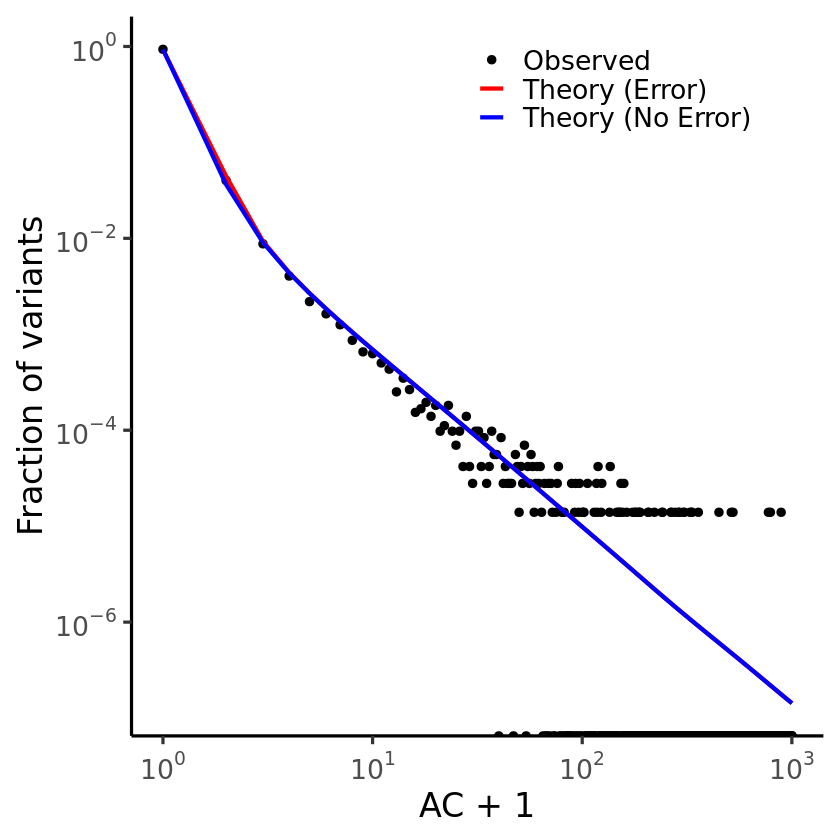

In [85]:
plot_SFS_error(SFS_to_analyze,"AGC","ATC",NA,K=1000,AN=1000000,Ne=Ne_fit_diffusion,R=R_fit,T=T_fit_diffusion,rates=mutation_rates,error = error_rates_func,nc=20)

ggsave("/scratch1/schraibe/rare_alleles/fig/fit_ACG_ATG_with_error.pdf")  

In [18]:
B_score = list()
for (i in 1:10) {
    B_score[[i]] = read_pop_size_res_flat(paste0("/scratch1/schraibe/rare_alleles/bscores/output/Bscore_",i),10,0.0004, 0.025)
}

Rows: 500 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_logical()
)

Rows: 500 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

── Column specification ────────────────────────────────────────────────────────
cols(
  rep = col_logical()
)

Rows: 500 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): par, est, lnL

ℹ Use `spec()` to retrieve the full colu

In [21]:
B_score_rescale = list()
for (i in 1:10) {
    cur_SFS = vroom(paste0("/scratch1/schraibe/rare_alleles/bscores/SFS/SFS_to_analyze.Bscore_",i,".txt.gz"))
    B_score_rescale[[i]] = rescale_pop_size(cur_SFS,B_score[[i]],gnomad_mutation,K=1000,AN=1000000,nc=20)
}

Rows: 122122 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): ref_context, alt_context, type
dbl (4): methylation_level, Bscore_bin, AC, n

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
Rows: 124124 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): ref_context, alt_context, type
dbl (4): methylation_level, Bscore_bin, AC, n

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet thi

In [22]:
B_score_pop_sizes = tibble()
for (i in 1:10) {
    cur_tibble = tibble(Ne = B_score_rescale[[i]]$Ne, T = B_score_rescale[[i]]$T,B_score_bin = i)
    B_score_pop_sizes = bind_rows(B_score_pop_sizes,cur_tibble)
}

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”
Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”
Saving 6.67 x 6.67 in image
Warning message in scale_x_log10(labels = label_log()):
“log-10 transformation introduced infinite values.”


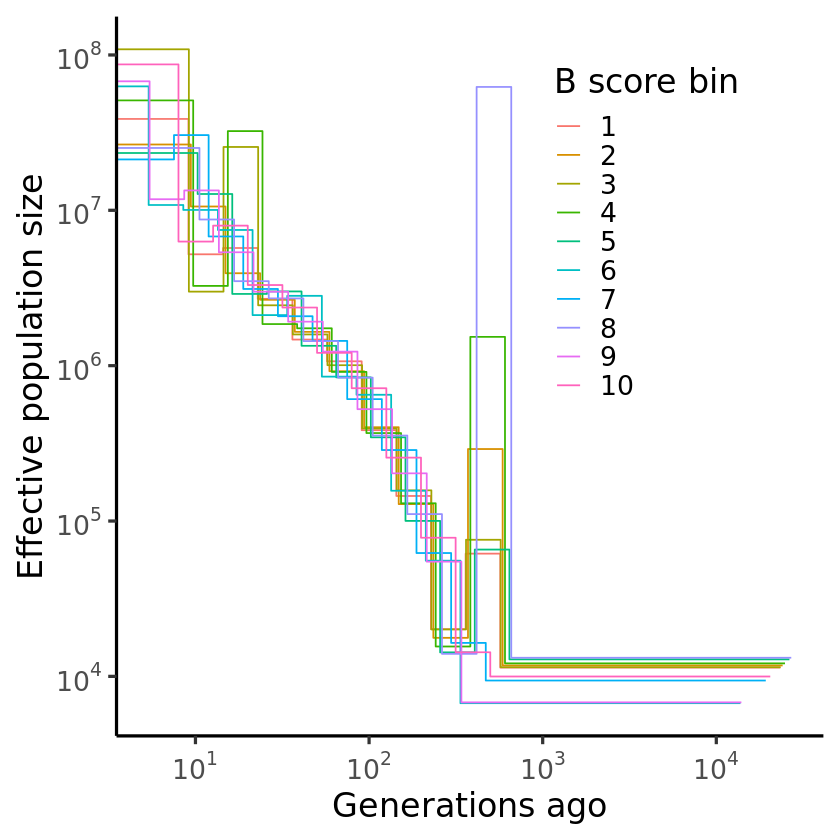

In [23]:
B_score_pop_sizes %>% 
    group_by(B_score_bin) %>%
    mutate(T = max(T) - T) %>% 
    ggplot(aes(T,Ne)) +
    geom_step(aes(color=as.factor(B_score_bin)),direction="vh") +
    scale_x_log10(labels=label_log()) +
    scale_y_log10(labels=label_log()) +
    theme_classic(base_size=20) +
    labs(color="B score bin") +
    theme(legend.position = c(.75,.7)) +
    xlab("Generations ago") +
    ylab("Effective population size")

ggsave("/scratch1/schraibe/rare_alleles/fig/Bscore.pdf")

`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'


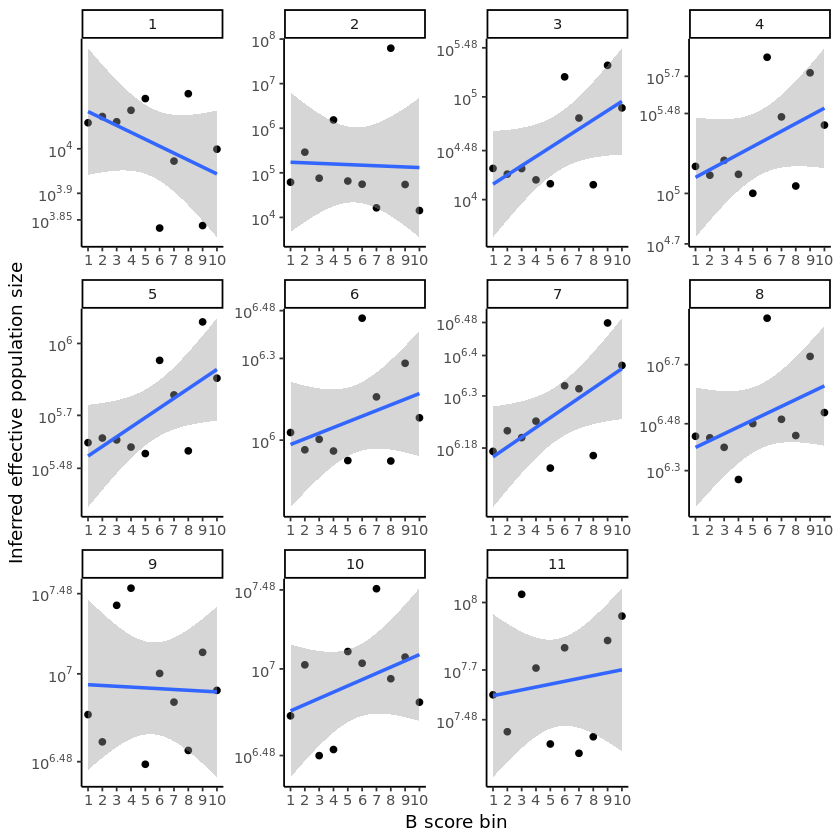

In [37]:
B_score_pop_sizes %>% 
    mutate(time_bin = rep(1:12,10)) %>%
    filter(time_bin<12) %>% 
    ggplot(aes(as.integer(B_score_bin),Ne)) +
    geom_point() +
    facet_wrap(~time_bin,scales="free") + 
    scale_y_log10(labels=label_log()) +
    geom_smooth(method="lm") +
    theme_classic() +
    ylab("Inferred effective population size") +
    xlab("B score bin") +
    scale_x_continuous(breaks=1:10)

ggsave("/scratch1/schraibe/rare_alleles/fig/Bscore_bin.pdf")

In [72]:
compute_likelihood_hessian = function(SFS_to_analyze,pop_size_inference,K=1000,AN=1000000,start=0,nc=20,eps=1e-5) {


    Ne = pop_size_inference$Ne_diffusion
    T = pop_size_inference$T_diffusion
    R = pop_size_inference$R

    par = Ne[-c(1,length(Ne))]

    counts = SFS_to_analyze %>% 
        arrange(ref_context,alt_context) %>% 
        filter(AC >= start,AC<=K) %>%  
        pull(n) %>% 
        matrix(nrow=K-start+1)
    
    message("Estimate theta")
    theta_opt = mutation_rate_MLE(SFS_to_analyze,K=K,AN=AN,Ne=Ne,R=R,T=T,nc=nc)
    
    message("Compute Hessian")
    
    hessian(
        function(par) {
            test_Ne = c(1,par,par[length(par)])
            theory = p_sep(K,max(T),theta_opt$theta,AN,0,test_Ne,R,T,nc=nc)
            theory_norm = apply(as.matrix(theory[(start+1):nrow(theory),]),2,normalize_vec)
            LL = sum(counts*log(theory_norm))
            LL
        },
        par,
        method.args=list(eps=eps,show.details=TRUE)
    )
    
}

In [73]:
H = compute_likelihood_hessian(SFS_to_analyze,flat_0.05_10,eps=1e-2)

Estimate theta

Compute Hessian

Warning message in selectChildren(ac[!fin], -1):
“error 'No child processes' in select”


In [61]:
bootstrap_variability_matrix_richardson = function(SFS_to_analyze,pop_size_inference,NB = 100, K=1000,AN=1000000,start=0,nc=20,eps=1e-4,maxIter = 5) {
    
    Ne = pop_size_inference$Ne_diffusion
    T = pop_size_inference$T_diffusion
    R = pop_size_inference$R

    par = Ne[-c(1,length(Ne))]

    num_cat = SFS_to_analyze %>%
        distinct(ref_context,alt_context,methylation_level,type) %>%
        nrow()
    
    message("Estimate theta")
    theta_opt = mutation_rate_MLE(SFS_to_analyze,K=K,AN=AN,Ne=Ne,R=R,T=T,nc=nc)

    message("Precompute theory") 

    message("Compute at MLE")
    theory_opt = p_sep(K,max(T),theta_opt$theta,AN,0,Ne,R,T,nc=nc)
    theory_opt_norm = apply(as.matrix(theory_opt[(start+1):nrow(theory_opt),]),2,normalize_vec)

    message("Compute at lower and upper points")
    theory_minus_norm = array(0,dim=c(maxIter,length(par),K+1,num_cat))
    theory_plus_norm = array(0,dim=c(maxIter,length(par),K+1,num_cat))
    for (j in 1:maxIter) {
        message(j)
        eps_j = eps/2^(j-1)
        for (i in 1:length(par)) {
            cur_par = par
            cur_par[i] = cur_par[i]-eps_j*par[i] #NB: rescaling
            test_Ne = c(1,cur_par,cur_par[length(cur_par)])
            theory_minus = p_sep(K,max(T),theta_opt$theta,AN,0,test_Ne,R,T,nc=nc)
            theory_minus_norm[j,i,,] = apply(as.matrix(theory_minus[(start+1):nrow(theory_minus),]),2,normalize_vec)
    
            cur_par = par
            cur_par[i] = cur_par[i]+eps_j*par[i] #NB: rescaling
            test_Ne = c(1,cur_par,cur_par[length(cur_par)])
            theory_plus = p_sep(K,max(T),theta_opt$theta,AN,0,test_Ne,R,T,nc=nc)
            theory_plus_norm[j,i,,] = apply(as.matrix(theory_plus[(start+1):nrow(theory_plus),]),2,normalize_vec)
        }
    }
    
    message("Bootstrap")
    U = matrix(nrow=NB,ncol=length(par))
    for (b in 1:NB) {
        message(paste0("Resampling ", b))
        resampled_SFS = SFS_to_analyze #%>% 
            # group_by(ref_context,alt_context,methylation_level,type,AC) %>%
            # reframe(new_AC = rbinom(n,AN,AC/AN)) %>%
            # select(-AC) %>%
            # rename(AC=new_AC) %>%
            # group_by(ref_context,alt_context,methylation_level,type) %>%
            # count(AC) %>%
            # ungroup() %>% 
            # filter(AC<=K) %>%
            # complete(nesting(ref_context,alt_context,methylation_level),type,AC = 0:K,fill=list(n=0))

        counts = resampled_SFS %>% 
            arrange(ref_context,alt_context) %>% 
            filter(AC >= start,AC<=K) %>%  
            pull(n) %>% 
            matrix(nrow=K-start+1)



        for (i in 1:length(par)) {

            D = matrix(0, nrow = maxIter, ncol = maxIter) #Richardson table

            for (j in 1:maxIter) {
                eps_j = eps/2^(j-1)*par[i] #NB: rescaling
                
                LL_minus = sum(counts*log(theory_minus_norm[j,i,,]))
                LL_plus = sum(counts*log(theory_plus_norm[j,i,,]))

                D[j,1] = (LL_plus-LL_minus)/(2*eps_j)
            }

            for (k in 2:maxIter) {
                for (j in 1:(maxIter - k + 1)) {
                    factor <- 2^(2 * (k - 1))
                    D[j, k] <- (factor * D[j + 1, k - 1] - D[j, k - 1]) / (factor - 1)
                }
            }

            print(D[1,])
            U[b,i] = D[1,maxIter]
        }
        
    }
    U
}

In [64]:
boots = bootstrap_variability_matrix_richardson(SFS_to_analyze,flat_0.05_10,NB = 1, K=1000,AN=1000000,start=0,nc=20,eps=1e-2,maxIter=5)


Estimate theta

Precompute theory

Compute at MLE

Compute at lower and upper points

1

Warning message in selectChildren(ac[!fin], -1):
“error 'No child processes' in select”
2

3

4

5

Bootstrap

Resampling 1



[1] -0.0006770169 -0.0006769991 -0.0006769277 -0.0006771837 -0.0006769503
[1]  -2.3850644 -13.6867341   8.7555445  -0.2649473   1.0210996
[1]  27.064353 -31.439600   6.387550  -1.518416  -1.367367
[1] -0.3559023 -0.3458677 -0.4194527 -0.4272421 -0.5081605
[1] -0.02871655 -0.02874259 -0.03781252 -0.05039416 -0.01446416
[1] 0.08746789 0.08513737 0.09026837 0.08878672 0.08888233
[1] 0.1030945 0.1030473 0.1030469 0.1030457 0.1030465
[1] 0.02707961 0.02705144 0.02705178 0.02705133 0.02704918
[1] -0.009838957 -0.009840738 -0.009840610 -0.009840782 -0.009840896
[1] -0.002208097 -0.002208170 -0.002208197 -0.002208203 -0.002208194


In [22]:
ss = 1000000
theta = 4*N0_fit*1e-8
res = tibble()
K = 50
g = 4*N0_fit*exp(seq(log(1e-4),log(1e-1),len=100))
prob = matrix(nrow=length(g),ncol=K)
for (i in 1:length(g)) {
    d = unlist(mclapply(1:K,d_tilde,s=max(T_fit_diffusion),theta=1,n=ss,g=-g[i],a=Ne_fit_diffusion,r=R_fit,t=T_fit_diffusion,mc.cores=2))
    prob[i,] = theta*d
}
cur_tibble = as_tibble(prob) %>% 
    mutate(g=g) %>% 
    pivot_longer(1:K,names_to="AC",values_to="prob_single") %>%
    mutate(AC = substring(AC,first=2,last=100000)) %>%
    type_convert() %>%
    mutate(theta=theta) 
res = bind_rows(res,cur_tibble)

Warning message:
“The `x` argument of `as_tibble.matrix()` must have unique column names if
`.name_repair` is omitted as of tibble 2.0.0.
ℹ Using compatibility `.name_repair`.”
Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(K)

  # Now:
  data %>% select(all_of(K))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”

── Column specification ────────────────────────────────────────────────────────
cols(
  AC = col_double()
)

